In [1]:
import astropy.units as u
from astropy.coordinates import SkyCoord
import numpy as np
import os.path as op
import math
import os
import h5py

from elixer import global_config as G
G.GLOBAL_LOGGING = True
from elixer import spectrum_utilities as ESU
from elixer import catalogs


from hetdex_api.elixer_widget_cls import ElixerWidget
from hetdex_api.config import HDRconfig
from hetdex_tools.get_spec import get_spectra
from hetdex_api.shot import *
from hetdex_api.survey import FiberIndex

import inspect
import scipy.stats as stats
from astropy.table import QTable, Table, Column
import warnings
from astropy.modeling import models
from specutils.spectra import Spectrum1D, SpectralRegion
from specutils.fitting import fit_generic_continuum
from specutils.fitting.continuum import fit_continuum
from astropy.stats import biweight_location
from scipy.integrate import quad as quad
from numpy.polynomial.polynomial import polyfit
from numpy.polynomial.polynomial import polyval
from photutils.centroids import centroid_2dg, centroid_sources
from numpy import inf

from matplotlib.widgets import Button

from astropy.modeling import fitting

from tqdm.notebook import tqdm  # For Jupyter notebook
from joblib import Parallel, delayed
import seaborn as sns
from scipy.stats import probplot


import multiprocessing as mp
import time


from scipy import ndimage
from scipy.stats import median_abs_deviation
import warnings

from scipy.optimize import curve_fit, differential_evolution, minimize
from itertools import product

from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

import json

from matplotlib.backends.backend_pdf import PdfPages


Populating dustmaps config with /home/jovyan/Hobby-Eberly-Telesco/hdr3/calib/dustmaps


In [2]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rc
import matplotlib.ticker
import matplotlib.patches as patches

%matplotlib ipympl
plt.style.use('default')
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({'font.size': 14})
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'
plt.rcParams['xtick.labelsize']= 14.0
plt.rcParams['ytick.labelsize']= 14.0
plt.rcParams['mathtext.default'] = 'rm' # All math text will be upright Roman

In [3]:
def load_variables_from_hdf5(filepath, auto_assign=True):
    """Load variables from HDF5 file"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Handle string data
            if isinstance(data, bytes):
                data = data.decode('utf-8')
            elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                data = data.astype(str)
            
            vars_dict[var_name] = data
    
    if auto_assign:
        # Automatically assign variables to global namespace
        import inspect
        frame = inspect.currentframe()
        try:
            # Get the caller's globals (the notebook's global namespace)
            caller_globals = frame.f_back.f_globals
            
            # Assign each variable to the caller's global namespace
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables to global namespace")
            print("Sample variables now available:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:  # Show first 3
                    print(f"  - {var_name}")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
                    
        finally:
            del frame
    
    return vars_dict


def load_and_assign_variables_hdf5(filepath):
    """Load variables from HDF5 and explicitly assign them using globals()"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Handle string data
            if isinstance(data, bytes):
                data = data.decode('utf-8')
            elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                data = data.astype(str)
            
            vars_dict[var_name] = data
    
    assigned_count = 0
    for var_name, var_value in vars_dict.items():
        globals()[var_name] = var_value
        assigned_count += 1
    
    print(f"Successfully loaded and assigned {assigned_count} variables")
    print("Variables are now available in the global namespace")
    
    return vars_dict


#Calculating the BH mass
def black_hole_mass(lam, wave_L_3000, FWHM, wave_L_3000_err=None, FWHM_err=None):
    """
    Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
    This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
    
    Parameters

    ----------
    lam : float
        Normalization constant, typically 1.0.
    wave_L_3000 : float or array-like
        Continuum luminosity at 3000Å in erg/s.
    FWHM : float or array-like
        Full Width at Half Maximum of the MgII line in km/s.
    wave_L_3000_err : float or array-like, optional
        Standard deviation of the continuum luminosity in erg/s.
    FWHM_err : float or array-like, optional
        Standard deviation of the FWHM in km/s.
        
    Returns
    -------
    M_bh_per_solar : float or array-like
        Black hole mass in units of solar masses.
    M_bh_per_solar_err : float or array-like or None
        Standard deviation of the black hole mass in solar masses.
        Returns None if both input errors are None.
    
    Notes
    -----
    The error propagation uses the standard formula for error propagation:
    For a function f(x,y) = A * x^a * y^b, the relative error is:
    σ_f/f = sqrt((a*σ_x/x)^2 + (b*σ_y/y)^2)
    
    References
    ----------
    Based on the calibration from McLure & Dunlop (2004) and Vestergaard & Peterson (2006).
    """
    # Convert input to numpy arrays if they aren't already
    wave_L_3000 = np.asarray(wave_L_3000)
    FWHM = np.asarray(FWHM)
    
    # Process input errors
    if wave_L_3000_err is not None:
        wave_L_3000_err = np.asarray(wave_L_3000_err)

    if FWHM_err is not None:
        FWHM_err = np.asarray(FWHM_err)
    
    # Compute black hole mass
    xx = lam * wave_L_3000  # erg/s
    xxx = xx / (10**7)  # watts (conversion from erg/s to watts)
    
    # Exponents in the formula
    power_lum = 0.47
    power_fwhm = 2.0
    
    # Calculate black hole mass
    M_bh_per_solar = 3.37 * ((xxx / 10**37)**power_lum) * (FWHM**power_fwhm)
    
    # If no errors are provided, return only the mass
    if wave_L_3000_err is None and FWHM_err is None:
        return M_bh_per_solar, None
    
    # Error propagation
    # Initialize error array with zeros
    M_bh_per_solar_err = np.zeros_like(M_bh_per_solar, dtype=float)
    
    # For elements where both errors are provided
    mask_both = np.logical_and(
        np.logical_and(wave_L_3000_err is not None, FWHM_err is not None),
        np.logical_and(wave_L_3000_err > 0, FWHM_err > 0)
    )
    
    # For elements where only luminosity error is provided
    mask_lum_only = np.logical_and(
        np.logical_and(wave_L_3000_err is not None, FWHM_err is None),
        wave_L_3000_err > 0
    )
    
    # For elements where only FWHM error is provided
    mask_fwhm_only = np.logical_and(
        np.logical_and(wave_L_3000_err is None, FWHM_err is not None),
        FWHM_err > 0
    )
    
    # Calculate relative errors for each component
    if np.any(mask_both) or np.any(mask_lum_only):
        # Relative error contribution from luminosity
        rel_err_lum = power_lum * (wave_L_3000_err / wave_L_3000)
    
    if np.any(mask_both) or np.any(mask_fwhm_only):
        # Relative error contribution from FWHM
        rel_err_fwhm = power_fwhm * (FWHM_err / FWHM)
    
    # Calculate total relative error and convert to absolute error
    if np.any(mask_both):
        rel_err_total = np.sqrt(rel_err_lum**2 + rel_err_fwhm**2)
        M_bh_per_solar_err = M_bh_per_solar * rel_err_total
    elif np.any(mask_lum_only):
        M_bh_per_solar_err = M_bh_per_solar * rel_err_lum
    elif np.any(mask_fwhm_only):
        M_bh_per_solar_err = M_bh_per_solar * rel_err_fwhm
    
    return M_bh_per_solar, M_bh_per_solar_err


In [4]:
# Usage in another notebook
Table_b = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/All_Variables.h5")


Successfully loaded and assigned 1293 variables to global namespace
Sample variables now available:
  - AGN_Only_Continuum_L3000_025_035
  - AGN_Only_Continuum_L3000_035_045
  - AGN_Only_Continuum_L3000_045_055
  ... and 1290 more


"""

"""
MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085.strip('[]'), sep=' ')

MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096.strip('[]'), sep=' ')



MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085.strip('[]'), sep=' ')
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096 = np.fromstring(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096.strip('[]'), sep=' ')


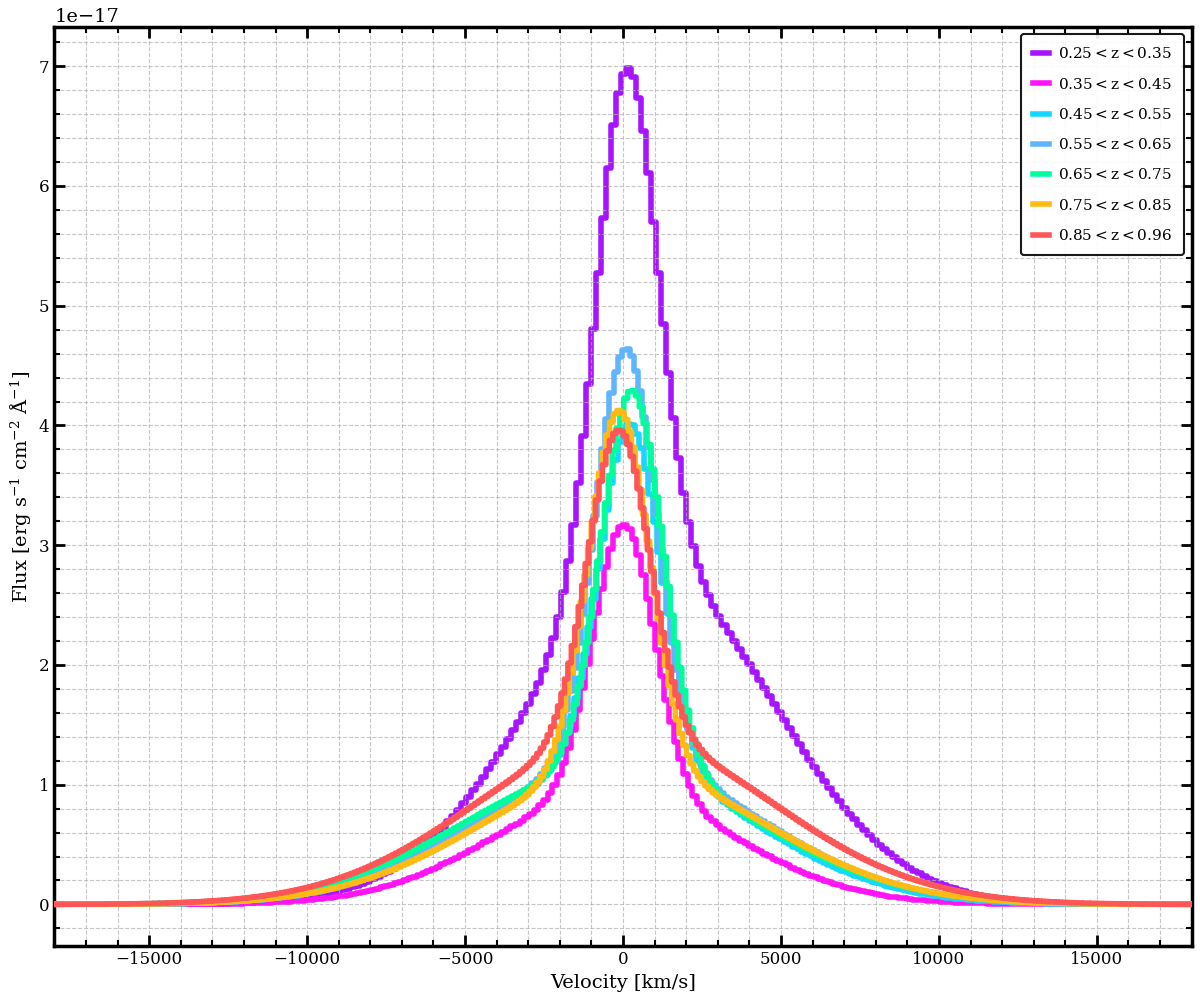

In [5]:
"""
Overplotting the MgII emission region with the continuum removed.
Unified MNRAS-style formatting to match the second code's style.
"""
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters (matching second code style)
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions (adjusted to match second code proportions)
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Color scheme matching second code's cool-to-warm progression
colors = {
    'z_025_035': "#a714ff",   # Purple (deep/cool)
    'z_035_045': "#ff14f5",   # Pink
    'z_045_055': "#14D8FF",   # Teal
    'z_055_065': "#60B5FF",   # Blue
    'z_065_075': "#00FF9C",   # Green
    'z_075_085': "#ffbb14",   # Orange
    'z_085_096': "#FF5757",   # Red (warm)
    'reference_lines': "black"
}

# Labels for legend (formatted for better readability, matching second code format)
redshift_labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting
datasets = [
    ('z_025_035', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_025_035, 
     redshift_labels[0]),
    ('z_035_045', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_035_045, 
     redshift_labels[1]),
    ('z_045_055', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_045_055, 
     redshift_labels[2]),
    ('z_055_065', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_055_065, 
     redshift_labels[3]),
    ('z_065_075', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_065_075, 
     redshift_labels[4]),
    ('z_075_085', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_075_085, 
     redshift_labels[5]),
    ('z_085_096', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_085_096, 
     redshift_labels[6])
]

# Plot each dataset
for i, (key, wave, flux, label) in enumerate(datasets):
    color = colors[key]
    
    # Plot uncertainty band (optional - currently commented out)
    # ax.fill_between(wave, flux - error, flux + error, 
    #                 color=color, alpha=0.2, zorder=i*2, 
    #                 label=f'±1σ {label}' if i == 0 else "")
    
    # Plot main spectrum line
    ax.step(wave, flux, 
            color=color, 
            linewidth=4.0, 
            linestyle="-", 
            alpha=1.0, 
            zorder=i*2+1,
            label=label)

# Reference spectral lines configuration (commented out as in original)
# reference_lines = [
#     (2799, "--", 2, r"Mg II $\lambda$2799"),
#     (2945.106, ":", 2, r"He I $\lambda$2945")
# ]

# Plot reference lines
# for wavelength, linestyle, linewidth, label in reference_lines:
#     ax.axvline(x=wavelength, 
#                color=colors['reference_lines'], 
#                linestyle=linestyle, 
#                linewidth=linewidth,
#                label=label, 
#                zorder=100)

# Configure axes labels (matching second code font sizes)
ax.set_xlabel(r"Velocity [km/s]", fontsize=14, color="black")
ax.set_ylabel(r"Flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]", fontsize=14, color="black")

# Configure legend with MNRAS style (simplified like second code)
legend = ax.legend(
    loc='upper right',
    fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=False,  # Removed shadow to match second code
    borderpad=0.8,
    handletextpad=0.6,
    columnspacing=1.0,
    handlelength=1.0,
    labelspacing=1.0,
    numpoints=1,
    ncol=1
)
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Configure grid (matching second code style)
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters (matching second code font sizes)
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Set specific axis limits
ax.set_xlim(-18000, 18000)

# Adjust layout
plt.tight_layout(pad=0.5)

# Optional: Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Multi_Redshift_Spectra_MNRAS_Ready.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Multi_Redshift_Spectra_MNRAS_Ready.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show(block=False)


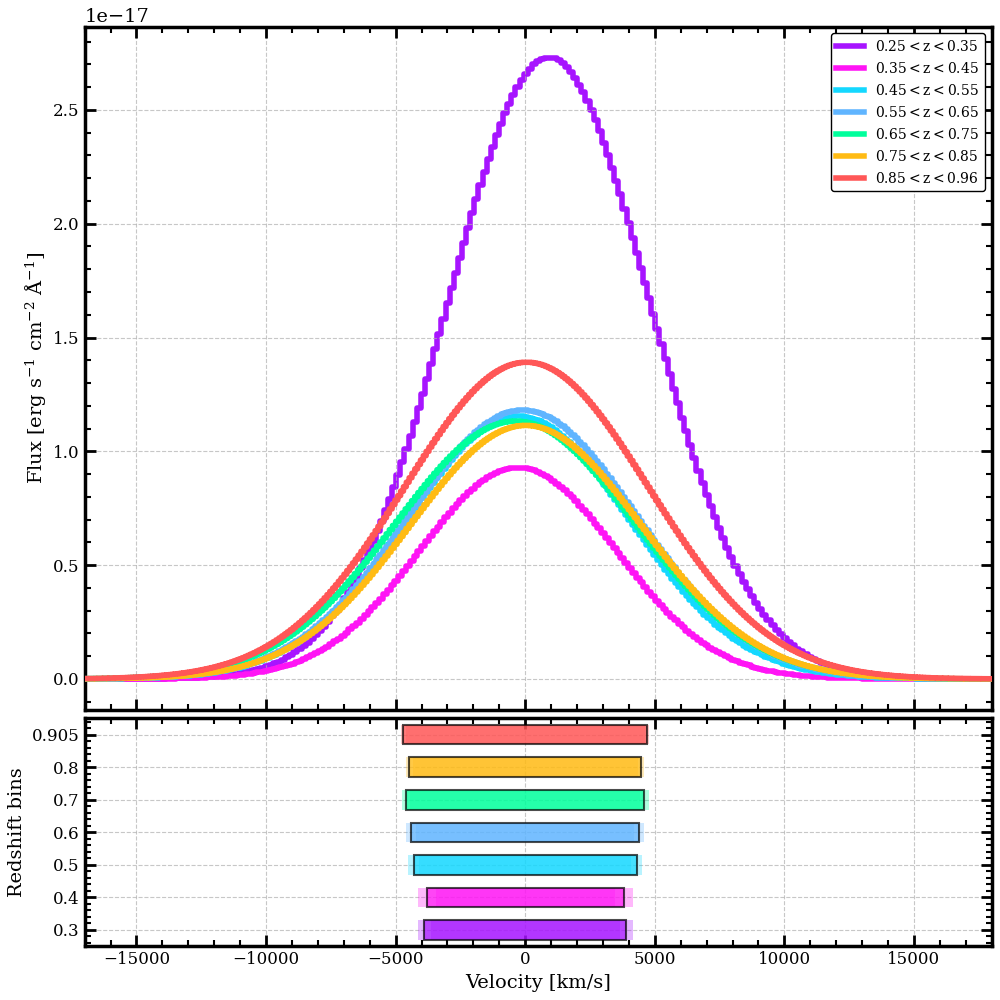

In [6]:
"""
Two-panel plot: MgII spectra (top) and FWHM analysis (bottom).
Unified MNRAS-style formatting with shared color scheme and x-axis.
"""
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with two subplots (BH mass above, luminosity below with smaller height)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), facecolor='white', 
                               gridspec_kw={'height_ratios': [3, 1]})

# Shared color scheme
colors = {
    'z_025_035': "#a714ff",   # Purple (deep/cool)
    'z_035_045': "#ff14f5",   # Pink
    'z_045_055': "#14D8FF",   # Teal
    'z_055_065': "#60B5FF",   # Blue
    'z_065_075': "#00FF9C",   # Green
    'z_075_085': "#ffbb14",   # Orange
    'z_085_096': "#FF5757",   # Red (warm)
    'reference_lines': "black"
}

# Labels for legend
redshift_labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# ============== TOP PANEL: SPECTRA ==============
# Dataset configuration for spectral plotting
datasets = [
    ('z_025_035', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_025_035, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_025_035, 
     redshift_labels[0]),
    ('z_035_045', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_035_045, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_035_045, 
     redshift_labels[1]),
    ('z_045_055', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_045_055, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_045_055, 
     redshift_labels[2]),
    ('z_055_065', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_055_065, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_055_065, 
     redshift_labels[3]),
    ('z_065_075', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_065_075, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_065_075, 
     redshift_labels[4]),
    ('z_075_085', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_075_085, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_075_085, 
     redshift_labels[5]),
    ('z_085_096', 
     MgII_ReStacked_Continuum_Scaled_Velocity_Shifted_085_096, 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_BestFit_Broad_Gaussian_Velocity_FWHM_Min_085_096, 
     redshift_labels[6])
]

# Plot each spectrum dataset
for i, (key, wave, flux, label) in enumerate(datasets):
    color = colors[key]
    
    # Plot main spectrum line
    ax1.step(wave, flux, 
             color=color, 
             linewidth=4.0, 
             linestyle="-", 
             alpha=1.0, 
             zorder=i*2+1,
             label=label)

# Configure top panel (spectra)
ax1.set_ylabel(r"Flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]", fontsize=14, color="black")

# ============== BOTTOM PANEL: FWHM ==============
# FWHM data configuration
fwhm_datasets = [
    ('z_025_035', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035),
    ('z_035_045', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045),
    ('z_045_055', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055),
    ('z_055_065', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065),
    ('z_065_075', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075),
    ('z_075_085', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085),
    ('z_085_096', 
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)
]

# Plot FWHM data as horizontal bars/shaded regions
for i, (key, fwhm_val, fwhm_err) in enumerate(fwhm_datasets):
    color = colors[key]
    
    # Convert sigma to FWHM if needed (uncomment if values are in sigma units)
    # fwhm_val_converted = fwhm_val * 2.355
    # fwhm_err_converted = fwhm_err * 2.355
    
    # Create horizontal bar showing FWHM extent
    y_pos = i + 0.5  # Vertical position for this redshift bin
    
    # Plot central FWHM as filled rectangle
    ax2.barh(y_pos, fwhm_val * 2, left=-fwhm_val, height=0.6, 
             color=color, alpha=0.7, edgecolor='black', linewidth=1.5,
             zorder=10)
    
    # Plot uncertainty as lighter shaded region extending beyond main bar
    if fwhm_err > 0:
        total_width_lower = (fwhm_val - fwhm_err) * 2
        total_width_upper = (fwhm_val + fwhm_err) * 2
        
        # Lower uncertainty (narrower bar)
        ax2.barh(y_pos, total_width_lower, left=-(fwhm_val - fwhm_err), height=0.6,
                color=color, alpha=0.3, edgecolor=None, zorder=5)
        
        # Upper uncertainty (wider bar)
        ax2.barh(y_pos, total_width_upper, left=-(fwhm_val + fwhm_err), height=0.6,
                color=color, alpha=0.3, edgecolor=None, zorder=5)

# Configure bottom panel (FWHM)
ax2.set_xlabel(r"Velocity [km/s]", fontsize=14, color="black")
ax2.set_ylabel(r"Redshift bins", fontsize=14, color="black")

# Set y-axis to show redshift bin labels
ax2.set_ylim(0, len(fwhm_datasets))
ax2.set_yticks([i + 0.5 for i in range(len(fwhm_datasets))])
ax2.set_yticklabels([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905])

# ============== SHARED X-AXIS CONFIGURATION ==============
# Set the same x-axis limits for both panels
shared_xlim = (-17000, 18000)
ax1.set_xlim(shared_xlim)
ax2.set_xlim(shared_xlim)

# ============== SHARED FORMATTING ==============
# Apply formatting to both panels
for ax in [ax1, ax2]:
    # Configure grid
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    
    # Set minor ticks
    ax.minorticks_on()
    
    # Configure spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide x-axis labels on top panel (since bottom panel shows them)
ax1.set_xticklabels([])

# Add legend to top panel
ax1.legend(loc='upper right', fontsize=10, ncol=1)

# Adjust layout
plt.tight_layout(pad=0.5)

fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Broad_MgII_FWHM.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show(block=False)


## <font color='#00879E' size=5 >Getting the Black hole masses - Uniform Narrow Sigma - FeII Removed </font>

In [7]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_median_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_median_SD_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_median_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_median_SD_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_median_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_median_SD_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_median_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_median_SD_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_median_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_median_SD_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_median_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_median_SD_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 = black_hole_mass(3000, Luminosities_AGN_Only_Binned_Data_median_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                                                                                                                        Luminosities_AGN_Only_Binned_Data_median_SD_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)

########################################################################################################################################################################################################################################################################################
############################################################################################################################################
############################################

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_median_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_median_SD_025_035 = black_hole_mass(3000, Luminosities_Binned_Data_median_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_035_045 = black_hole_mass(3000, Luminosities_Binned_Data_median_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_045_055 = black_hole_mass(3000, Luminosities_Binned_Data_median_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_055_065 = black_hole_mass(3000, Luminosities_Binned_Data_median_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_065_075 = black_hole_mass(3000, Luminosities_Binned_Data_median_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_075_085 = black_hole_mass(3000, Luminosities_Binned_Data_median_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_085_096 = black_hole_mass(3000, Luminosities_Binned_Data_median_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                                                                                                                        Luminosities_Binned_Data_median_SD_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)


In [8]:
#print(np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035))
#print(np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045))
#print(np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055))
#print(np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065))
#print(np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075))
#print(np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085))
#print(np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096))
#
#print("")
#print("")
#
#print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Median_025_035))
#print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Median_035_045))
#print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Median_045_055))
#print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Median_055_065))
#print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Median_065_075))
#print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Median_075_085))
#print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Median_085_096))
#
#print("")
#print("")
#
#print(Stellar_Mass_Median_025_035)
#print(Stellar_Mass_Median_035_045)
#print(Stellar_Mass_Median_045_055)
#print(Stellar_Mass_Median_055_065)
#print(Stellar_Mass_Median_065_075)
#print(Stellar_Mass_Median_075_085)
#print(Stellar_Mass_Median_085_096)
#
#print("")
#print("")
#
#print(np.log10(300*AGN_Only_Continuums_L3000_Median_Array/1e7))


In [9]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_AGN_Only_median_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_AGN_Only_median_SD_025_035 = black_hole_mass(3000, AGN_Only_Continuums_L3000_median_Array[0], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035, 
                                                                                                                                                                        AGN_Only_Continuums_L3000_median_SD_Array[0], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_SD_035_045 = black_hole_mass(3000, AGN_Only_Continuums_L3000_median_Array[1], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                                                                                                                        AGN_Only_Continuums_L3000_median_SD_Array[1], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_SD_045_055 = black_hole_mass(3000, AGN_Only_Continuums_L3000_median_Array[2], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                                                                                                                        AGN_Only_Continuums_L3000_median_SD_Array[2], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_SD_055_065 = black_hole_mass(3000, AGN_Only_Continuums_L3000_median_Array[3], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                                                                                                                        AGN_Only_Continuums_L3000_median_SD_Array[3], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_SD_065_075 = black_hole_mass(3000, AGN_Only_Continuums_L3000_median_Array[4], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                                                                                                                        AGN_Only_Continuums_L3000_median_SD_Array[4], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_SD_075_085 = black_hole_mass(3000, AGN_Only_Continuums_L3000_median_Array[5], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                                                                                                                        AGN_Only_Continuums_L3000_median_SD_Array[5], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_AGN_Only_median_SD_085_096 = black_hole_mass(3000, AGN_Only_Continuums_L3000_median_Array[6], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                                                                                                                        AGN_Only_Continuums_L3000_median_SD_Array[6], 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)


In [10]:
"""
For the Broad part of the MgII.

Calculate black hole mass using the MgII line width and continuum luminosity at 3000Å.
    
This function computes black hole mass (in solar masses) based on the empirical relation:
    M_BH/M_☉ = 3.37 * (λL_3000/10^37 W)^0.47 * (FWHM_MgII/km s^-1)^2
"""
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 = black_hole_mass(3000, Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035, 
                                                                                                                                                                        Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 = black_hole_mass(3000, Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045, 
                                                                                                                                                                        Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 = black_hole_mass(3000, Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055, 
                                                                                                                                                                        Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 = black_hole_mass(3000, Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065, 
                                                                                                                                                                        Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 = black_hole_mass(3000, Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075, 
                                                                                                                                                                        Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 = black_hole_mass(3000, Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085, 
                                                                                                                                                                        Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085)

BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 = black_hole_mass(3000, Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096, 
                                                                                                                                                                        Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096, 
                                                                                                                                                                        MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096)



Dual subplot chart created successfully!
AGN Only luminosities: [5.09578835e+39 3.83805729e+39 3.26897995e+39 3.19284651e+39
 5.11596908e+39 3.54780457e+39 4.73791123e+39]
All sources luminosities: [1.18267813e+40 9.01000629e+39 1.23038150e+40 1.17851366e+40
 1.22673575e+40 1.26702095e+40 1.00365859e+40]
AGN Only masses: [21202909.22545235 17618805.7334509  20921246.80393991 21664362.93513554
 29552122.08939081 23437769.95228549 29757638.16086996]
All sources masses: [31495854.10008892 26312667.51233992 39006097.68053027 40022988.60671931
 44576455.58833614 42632776.46966148 42346549.63523825]


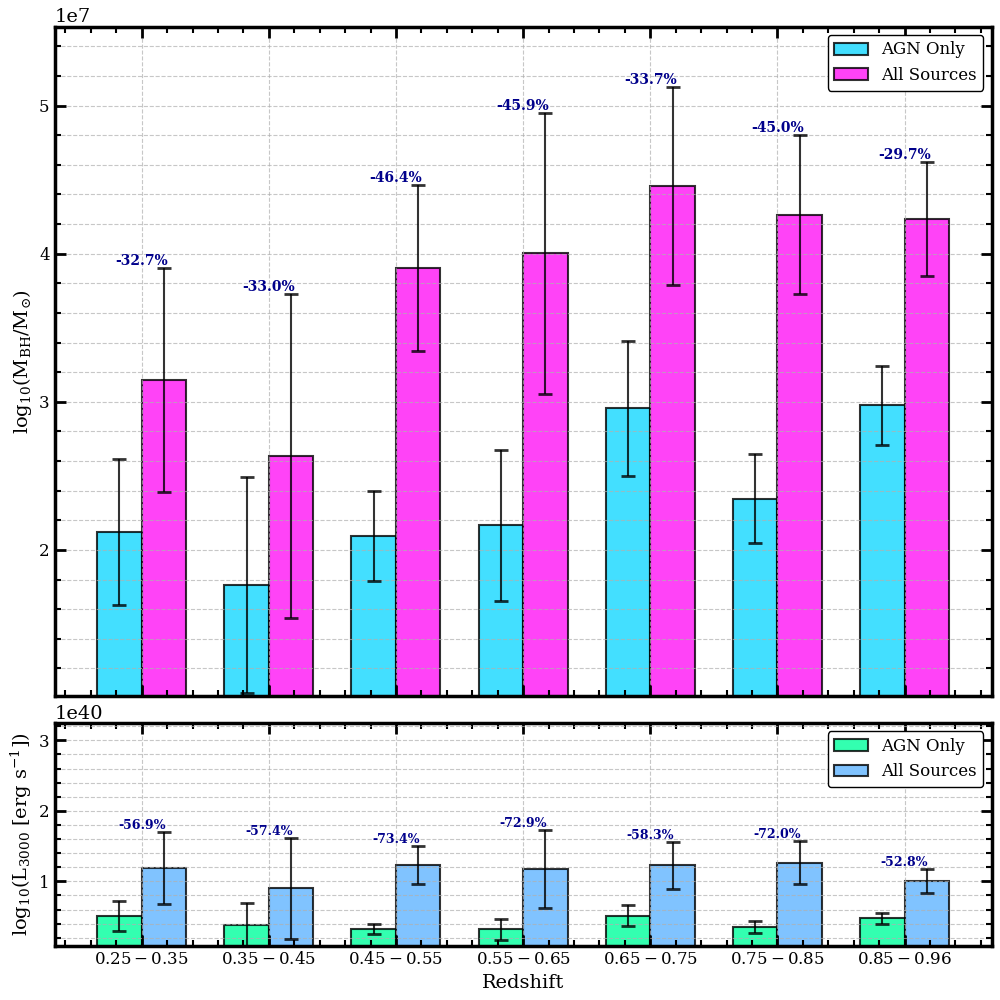

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with two subplots (BH mass above, luminosity below with smaller height)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), facecolor='white', 
                               gridspec_kw={'height_ratios': [3, 1]})

# Define redshift bin labels and positions
redshift_labels = [
    r'$0.25-0.35$',
    r'$0.35-0.45$',
    r'$0.45-0.55$',
    r'$0.55-0.65$',
    r'$0.65-0.75$',
    r'$0.75-0.85$',
    r'$0.85-0.96$'
]

# X positions for the bars
x_pos = np.arange(len(redshift_labels))
bar_width = 0.35

# Color scheme for specific redshift bins
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Colors for the plots
bh_agn_only_color = colors['045_055']    # Teal for BH AGN Only
bh_all_color = colors['035_045']         # Pink for BH All Sources
lum_agn_only_color = colors['065_075']   # Green for Luminosity AGN Only  
lum_all_color = colors['055_065']        # Blue for Luminosity All Sources

# ============================================================================
# LUMINOSITY DATA
# ============================================================================
# AGN Only luminosity data
agn_only_luminosities = np.array([
    Luminosities_AGN_Only_Binned_Data_median_025_035,
    Luminosities_AGN_Only_Binned_Data_median_035_045,
    Luminosities_AGN_Only_Binned_Data_median_045_055,
    Luminosities_AGN_Only_Binned_Data_median_055_065,
    Luminosities_AGN_Only_Binned_Data_median_065_075,
    Luminosities_AGN_Only_Binned_Data_median_075_085,
    Luminosities_AGN_Only_Binned_Data_median_085_096

])

# All sources luminosity data
all_luminosities = np.array([
     Luminosities_Binned_Data_median_025_035,
     Luminosities_Binned_Data_median_035_045,
     Luminosities_Binned_Data_median_045_055,
     Luminosities_Binned_Data_median_055_065,
     Luminosities_Binned_Data_median_065_075,
     Luminosities_Binned_Data_median_075_085,
     Luminosities_Binned_Data_median_085_096

])

# Luminosity error bars
agn_only_lum_errors = np.array([
    Luminosities_AGN_Only_Binned_Data_median_SD_025_035,
    Luminosities_AGN_Only_Binned_Data_median_SD_035_045,
    Luminosities_AGN_Only_Binned_Data_median_SD_045_055,
    Luminosities_AGN_Only_Binned_Data_median_SD_055_065,
    Luminosities_AGN_Only_Binned_Data_median_SD_065_075,
    Luminosities_AGN_Only_Binned_Data_median_SD_075_085,
    Luminosities_AGN_Only_Binned_Data_median_SD_085_096

])

all_lum_errors = np.array([
    Luminosities_Binned_Data_median_SD_025_035,
    Luminosities_Binned_Data_median_SD_035_045,
    Luminosities_Binned_Data_median_SD_045_055,
    Luminosities_Binned_Data_median_SD_055_065,
    Luminosities_Binned_Data_median_SD_065_075,
    Luminosities_Binned_Data_median_SD_075_085,
    Luminosities_Binned_Data_median_SD_085_096

])

# ============================================================================
# BLACK HOLE MASS DATA 
# ============================================================================
# Your actual black hole mass data
agn_only_masses = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096

])

all_masses = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_median_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_085_096

])

# Error bars using your SD values
agn_only_errors = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096

])

all_errors = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_median_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_median_SD_085_096
])

# ============================================================================
# TOP SUBPLOT: BLACK HOLE MASS
# ============================================================================
# Create grouped bars for black hole mass
bars1_bh = ax1.bar(x_pos - bar_width/2, agn_only_masses, bar_width, 
                   color=bh_agn_only_color, alpha=0.8, label='AGN Only',
                   edgecolor='black', linewidth=1.5)

bars2_bh = ax1.bar(x_pos + bar_width/2, all_masses, bar_width,
                   color=bh_all_color, alpha=0.8, label='All Sources',
                   edgecolor='black', linewidth=1.5)

# Add error bars for black hole mass
ax1.errorbar(x_pos - bar_width/2, agn_only_masses, yerr=agn_only_errors,
             fmt='none', ecolor='black', capsize=5, capthick=2, 
             elinewidth=1.5, alpha=0.8)

ax1.errorbar(x_pos + bar_width/2, all_masses, yerr=all_errors,
             fmt='none', ecolor='black', capsize=5, capthick=2,
             elinewidth=1.5, alpha=0.8)

# Add percentage difference text above each group
for i in range(len(x_pos)):
    # Calculate percentage change: (AGN - All) / All * 100
    pct_change = ((agn_only_masses[i] - all_masses[i]) / all_masses[i]) * 100
    
    # Position text above the taller bar
    y_pos = max(agn_only_masses[i] + agn_only_errors[i], 
                all_masses[i] + all_errors[i]) + 0.05
    
    # Format: positive values with +, negative values show -
    sign = "+" if pct_change >= 0 else ""
    ax1.text(x_pos[i], y_pos, f'{sign}{pct_change:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             color='darkred' if pct_change > 0 else 'darkblue')

# Configure black hole mass subplot
ax1.set_ylabel(r'log$_{10}$(M$_{\mathrm{BH}}$/M$_{\odot}$)', fontsize=14, color='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([])  # No x-labels on top plot
ax1.legend(loc='upper right', fontsize=12, framealpha=1.0)

# Configure grid for black hole mass
ax1.grid(visible=True, which='both', axis='y', 
         linestyle='--', alpha=0.7, zorder=-10)
ax1.minorticks_on()

# Configure spine thickness for black hole mass subplot
for spine in ax1.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters for black hole mass
ax1.tick_params(axis='both', which='major', labelsize=12,
                length=8, width=2.0, direction='in')
ax1.tick_params(axis='both', which='minor', labelsize=10,
                length=4, width=1.5, direction='in')
ax1.tick_params(top=True, right=True)

# Adjust y-limits for black hole mass to accommodate error bars and text
ymin_bh = min(np.min(agn_only_masses - agn_only_errors), 
              np.min(all_masses - all_errors)) * 0.98
ymax_bh = max(np.max(agn_only_masses + agn_only_errors), 
              np.max(all_masses + all_errors)) * 1.08  # Extra space for percentage text
ax1.set_ylim(ymin_bh, ymax_bh)

# ============================================================================
# BOTTOM SUBPLOT: LUMINOSITY
# ============================================================================
# Create grouped bars for luminosity
bars1_lum = ax2.bar(x_pos - bar_width/2, agn_only_luminosities, bar_width, 
                    color=lum_agn_only_color, alpha=0.8, label='AGN Only',
                    edgecolor='black', linewidth=1.5)

bars2_lum = ax2.bar(x_pos + bar_width/2, all_luminosities, bar_width,
                    color=lum_all_color, alpha=0.8, label='All Sources',
                    edgecolor='black', linewidth=1.5)

# Add error bars for luminosity
ax2.errorbar(x_pos - bar_width/2, agn_only_luminosities, yerr=agn_only_lum_errors,
             fmt='none', ecolor='black', capsize=5, capthick=2, 
             elinewidth=1.5, alpha=0.8)

ax2.errorbar(x_pos + bar_width/2, all_luminosities, yerr=all_lum_errors,
             fmt='none', ecolor='black', capsize=5, capthick=2,
             elinewidth=1.5, alpha=0.8)

# Add percentage difference text above each group
for i in range(len(x_pos)):
    # Calculate percentage change: (AGN - All) / All * 100
    pct_change = ((agn_only_luminosities[i] - all_luminosities[i]) / all_luminosities[i]) * 100
    
    # Position text above the taller bar
    y_pos = max(agn_only_luminosities[i] + agn_only_lum_errors[i], 
                all_luminosities[i] + all_lum_errors[i]) + 0.02
    
    # Format: positive values with +, negative values show -
    sign = "+" if pct_change >= 0 else ""
    ax2.text(x_pos[i], y_pos, f'{sign}{pct_change:.1f}%', 
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color='darkred' if pct_change > 0 else 'darkblue')

# Configure luminosity subplot
ax2.set_xlabel('Redshift', fontsize=14, color='black')
ax2.set_ylabel(r'log$_{10}$(L$_{3000}$ [erg s$^{-1}$])', fontsize=14, color='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(redshift_labels)
ax2.legend(loc='upper right', fontsize=12, framealpha=1.0)

# Configure grid for luminosity
ax2.grid(visible=True, which='both', axis='y', 
         linestyle='--', alpha=0.7, zorder=-10)
ax2.minorticks_on()

# Configure spine thickness for luminosity subplot
for spine in ax2.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters for luminosity
ax2.tick_params(axis='both', which='major', labelsize=12,
                length=8, width=2.0, direction='in')
ax2.tick_params(axis='both', which='minor', labelsize=10,
                length=4, width=1.5, direction='in')
ax2.tick_params(top=True, right=True)

# Adjust y-limits for luminosity to accommodate error bars and text
ymin_lum = min(np.min(agn_only_luminosities - agn_only_lum_errors), 
               np.min(all_luminosities - all_lum_errors)) * 0.998
ymax_lum = max(np.max(agn_only_luminosities + agn_only_lum_errors), 
               np.max(all_luminosities + all_lum_errors)) * 1.008  # Extra space for percentage text
ax2.set_ylim(ymin_lum, ymax_lum +1.5e40)

# ============================================================================
# FINAL LAYOUT AND DISPLAY
# ============================================================================
# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.15)  # Slightly more space for percentage text

# Adjust overall layout
plt.tight_layout(pad=0.5)

# Print data summary
print("Dual subplot chart created successfully!")
print(f"AGN Only luminosities: {agn_only_luminosities}")
print(f"All sources luminosities: {all_luminosities}")
print(f"AGN Only masses: {agn_only_masses}")
print(f"All sources masses: {all_masses}")


fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Change_Luminosities_BH_Mass.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')


# Show the figure
plt.show(block=False)


In [12]:
AGN_Only_Continuums_L3000_median_Array

array([6.66186523e+39, 9.65562289e+39, 1.39226024e+40, 2.10891698e+40,
       5.46169844e+40, 5.27652638e+40, 1.27062127e+41])

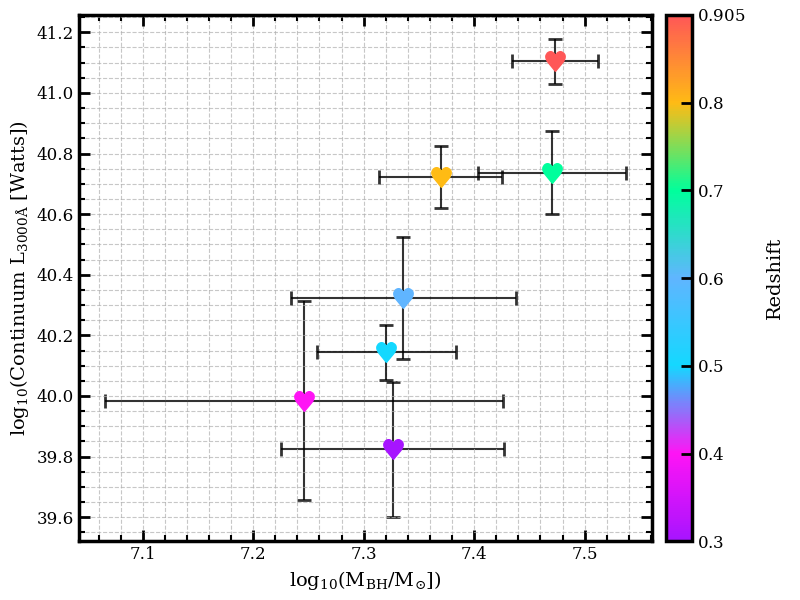

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]


# Dataset configuration for plotting
datasets = [
    ('025_035', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035), 
     np.log10(AGN_Only_Continuums_L3000_median_Array[0]), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10)), 
     AGN_Only_Continuums_L3000_median_SD_Array[0] / ( AGN_Only_Continuums_L3000_median_Array[0] * np.log(10))),
    ('035_045', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
     np.log10(AGN_Only_Continuums_L3000_median_Array[1]), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10)),
     AGN_Only_Continuums_L3000_median_SD_Array[1] / ( AGN_Only_Continuums_L3000_median_Array[1] * np.log(10))),
    ('045_055', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
     np.log10(AGN_Only_Continuums_L3000_median_Array[2]), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10)),
     AGN_Only_Continuums_L3000_median_SD_Array[2] / ( AGN_Only_Continuums_L3000_median_Array[2] * np.log(10))),
    ('055_065', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
     np.log10(AGN_Only_Continuums_L3000_median_Array[3]), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10)),
     AGN_Only_Continuums_L3000_median_SD_Array[3] / ( AGN_Only_Continuums_L3000_median_Array[3] * np.log(10))),
    ('065_075', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
     np.log10(AGN_Only_Continuums_L3000_median_Array[4]), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10)),
     AGN_Only_Continuums_L3000_median_SD_Array[4] / ( AGN_Only_Continuums_L3000_median_Array[4] * np.log(10))),
    ('075_085', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
     np.log10(AGN_Only_Continuums_L3000_median_Array[5]), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085*np.log(10)),
     AGN_Only_Continuums_L3000_median_SD_Array[5] / ( AGN_Only_Continuums_L3000_median_Array[5] * np.log(10))),
    ('085_096', np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
     np.log10(AGN_Only_Continuums_L3000_median_Array[6]), BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10)),
     AGN_Only_Continuums_L3000_median_SD_Array[6] / (  AGN_Only_Continuums_L3000_median_Array[6]* np.log(10)))
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


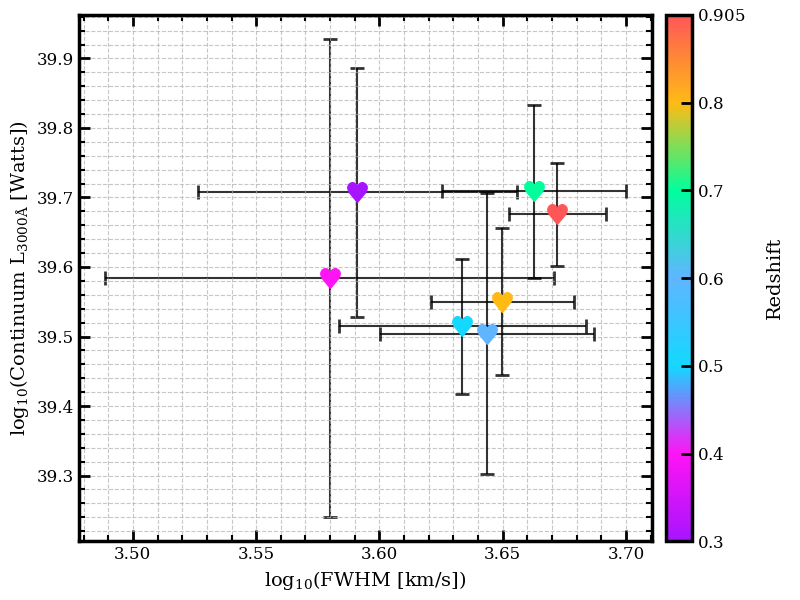

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (using broad component data)
datasets = [
    ('025_035', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035), 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_025_035), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10)), 
     Luminosities_AGN_Only_Binned_Data_median_SD_025_035 / (Luminosities_AGN_Only_Binned_Data_median_025_035 * np.log(10))),
    ('035_045', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     np.log10(Luminosities_AGN_Only_Binned_Data_median_035_045), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_median_SD_035_045 / (Luminosities_AGN_Only_Binned_Data_median_035_045 * np.log(10))),
    ('045_055', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     np.log10(Luminosities_AGN_Only_Binned_Data_median_045_055), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_median_SD_045_055 / (Luminosities_AGN_Only_Binned_Data_median_045_055 * np.log(10))),
    ('055_065', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     np.log10(Luminosities_AGN_Only_Binned_Data_median_055_065), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_median_SD_055_065 / (Luminosities_AGN_Only_Binned_Data_median_055_065 * np.log(10))),
    ('065_075', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     np.log10(Luminosities_AGN_Only_Binned_Data_median_065_075), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_median_SD_065_075 / (Luminosities_AGN_Only_Binned_Data_median_065_075 * np.log(10))),
    ('075_085', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     np.log10(Luminosities_AGN_Only_Binned_Data_median_075_085), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_median_SD_075_085 / (Luminosities_AGN_Only_Binned_Data_median_075_085 * np.log(10))),
    ('085_096', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     np.log10(Luminosities_AGN_Only_Binned_Data_median_085_096), MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)),
     Luminosities_AGN_Only_Binned_Data_median_SD_085_096 / (Luminosities_AGN_Only_Binned_Data_median_085_096 * np.log(10)))
]
         

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Broad_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


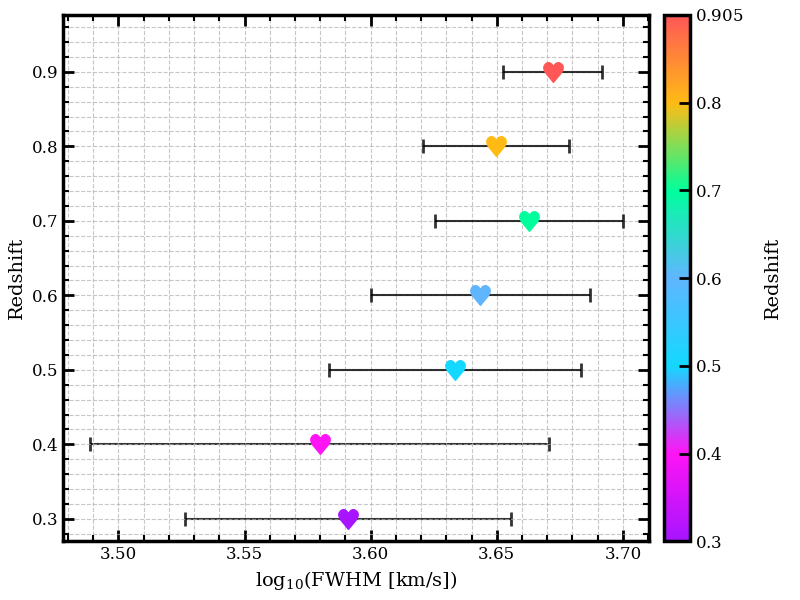

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Y-values for each redshift bin (fixed positions)
y_positions = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Dataset configuration for plotting (redshift vs FWHM with fixed y-positions)
datasets = [
    ('025_035', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     0.3, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10)), 
     None),  # No y-error for fixed positions
    ('035_045', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     0.4, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10)),
     None),
    ('045_055', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     0.5, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10)),
     None),
    ('055_065', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     0.6, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10)),
     None),
    ('065_075', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     0.7, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10)),
     None),
    ('075_085', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     0.8, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10)),
     None),
    ('085_096', np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     0.9, MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)),
     None)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (only x-direction since y-positions are fixed)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,  # Will be None
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
ax.set_ylabel(r"Redshift", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Redshift_FWHM_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_Redshift_FWHM_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


## <font color='#00879E' size=5 >Getting the Black hole masses from the Luminosity Corrected data - Uniform Narrow Sigma - FeII Removed </font>

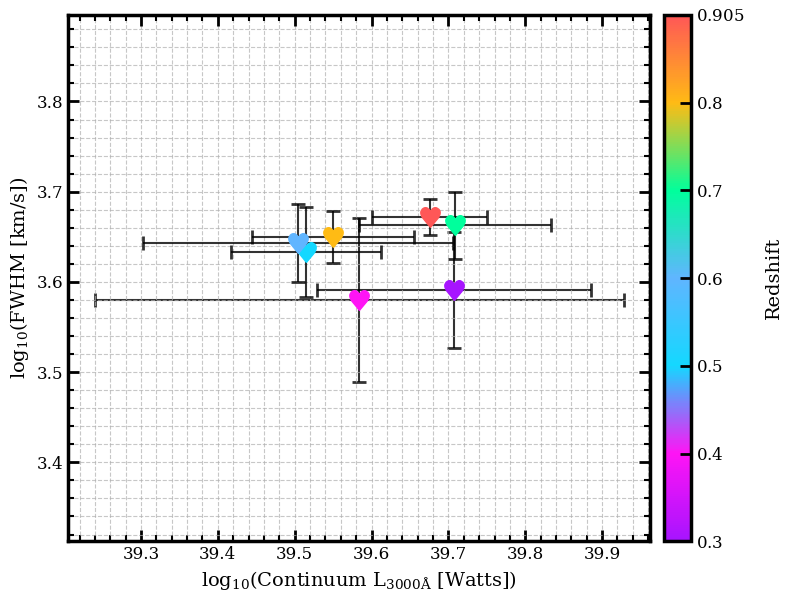

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Broad Component)
datasets = [
    ('025_035', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_025_035),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     Luminosities_AGN_Only_Binned_Data_median_SD_025_035 / (Luminosities_AGN_Only_Binned_Data_median_025_035 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10))
     ),
    ('035_045', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_035_045),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     Luminosities_AGN_Only_Binned_Data_median_SD_035_045 / (Luminosities_AGN_Only_Binned_Data_median_035_045 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10))
     ),
    ('045_055', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_045_055),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     Luminosities_AGN_Only_Binned_Data_median_SD_045_055 / (Luminosities_AGN_Only_Binned_Data_median_045_055 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10))
     ),
    ('055_065', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_055_065),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     Luminosities_AGN_Only_Binned_Data_median_SD_055_065 / (Luminosities_AGN_Only_Binned_Data_median_055_065 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10))
     ),
    ('065_075', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_065_075),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     Luminosities_AGN_Only_Binned_Data_median_SD_065_075 / (Luminosities_AGN_Only_Binned_Data_median_065_075 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10))
     ),
    ('075_085', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_075_085),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     Luminosities_AGN_Only_Binned_Data_median_SD_075_085 / (Luminosities_AGN_Only_Binned_Data_median_075_085 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10))
     ),
    ('085_096', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_085_096),
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     Luminosities_AGN_Only_Binned_Data_median_SD_085_096 / (Luminosities_AGN_Only_Binned_Data_median_085_096 * np.log(10)),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10))
     )
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


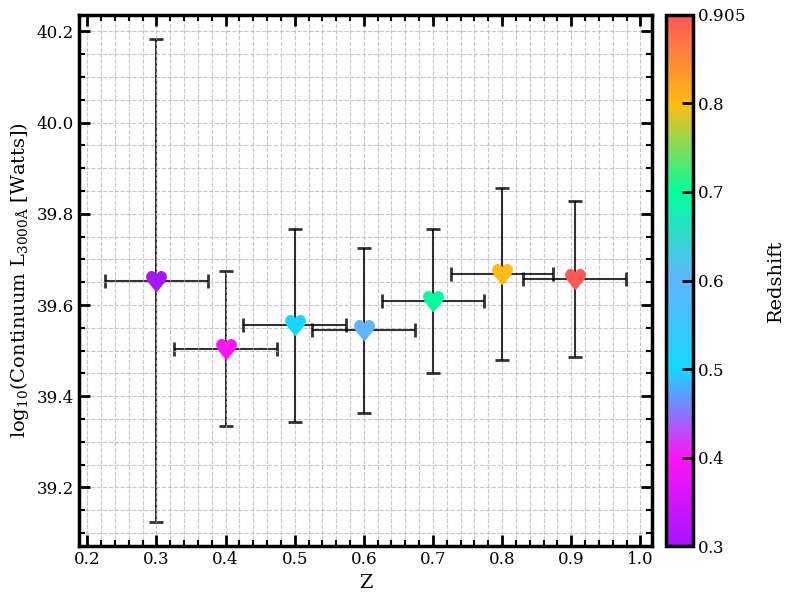

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Narrow Component)
datasets = [
    ('025_035', 
     0.3,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035 / ( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 * np.log(10))),
    ('035_045', 
     0.4,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045 / ( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 * np.log(10))),
    ('045_055', 
     0.5,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055 / ( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 * np.log(10))),
    ('055_065', 
     0.6,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065 / ( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 * np.log(10))),
    ('065_075', 
     0.7,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075 / ( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 * np.log(10))),
    ('075_085', 
     0.8,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085 / ( Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 * np.log(10))),
    ('085_096', 
     0.905,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096 / (  Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096* np.log(10)))
]

# Plot each dataset
for i, (key, x_data, y_data, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Narrow - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(40.75, 40.92)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


## <font color='#00879E' size=5 >Getting the Black hole masses Stellar mass relationship - from the Luminosity Corrected data - Uniform Narrow Sigma - FeII Removed </font>

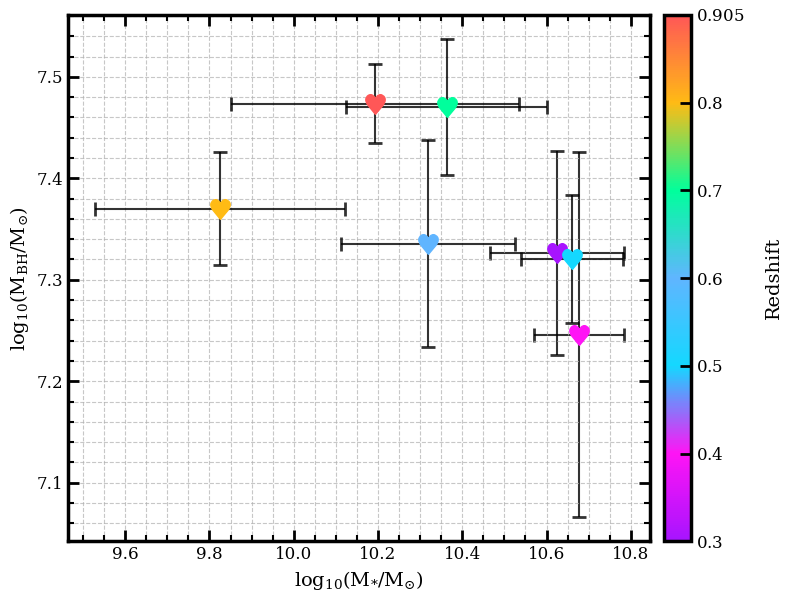

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Median_025_035,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035),
    Stellar_Mass_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10))), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Median_035_045,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
    Stellar_Mass_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10))),
    ('045_055', 
    Stellar_Mass_Median_045_055,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
    Stellar_Mass_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10))),
    ('055_065', 
    Stellar_Mass_Median_055_065,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
    Stellar_Mass_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10))),
    ('065_075', 
    Stellar_Mass_Median_065_075,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
    Stellar_Mass_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10))),
    ('075_085', 
    Stellar_Mass_Median_075_085,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
    Stellar_Mass_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085*np.log(10))),
    ('085_096', 
    Stellar_Mass_Median_085_096,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
    Stellar_Mass_SD_085_096,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10)))
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [19]:
"""
Getting the delta black hole mass over stellar mass and the standard deviation
"""
def standard_deveation_delta_BH_Stellar(M_BH, M_BH_SD, M_Stellar, M_Stellar_SD, Local, Local_SD):
    """
    This code finds the standard deviation for the delta black hole stellar mass relation.

    Parameters
    ----------
    M_BH: Black hole mass [NOT Log]
    M_BH_SD: Black hole mass standard deviation

    M_Stellar: Stellar mass [NOT log]
    M_Stellar_SD: Stellar mass standard deviation Median [NOT log] 

    Local: The local scaling relation
    Local_SD: The local scaling relation error

    Return
    ------
    Delta_BH_Stellar_SD: The standard deviation for the delta black hole stellar mass relation
    """


    term_one = ( ( 1 / ( M_BH * np.log(10) ) ) * M_BH_SD )**2
    term_two = ( ( -1 / (M_Stellar * np.log(10) ) ) * M_Stellar_SD )**2
    term_three = ( ( -1 / ( Local * np.log(10) ) ) * Local_SD )**2

    return np.sqrt(term_one + term_two + term_three)

#Getting the delta black hole stellar mass relation
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / 10**Stellar_Mass_Median_025_035) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_035_045 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / 10**Stellar_Mass_Median_035_045) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_045_055 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / 10**Stellar_Mass_Median_045_055) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_055_065 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / 10**Stellar_Mass_Median_055_065) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_065_075 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / 10**Stellar_Mass_Median_065_075) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_075_085 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / 10**Stellar_Mass_Median_075_085) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_085_096 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / 10**Stellar_Mass_Median_085_096) - np.log10(0.0025)


#Getting the standard deviation for the delta black hole stellar mass relation
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035, 
                                                                  10**Stellar_Mass_Median_025_035, 
                                                                  10**Stellar_Mass_SD_025_035, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_035_045 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045, 
                                                                  10**Stellar_Mass_Median_035_045, 
                                                                  10**Stellar_Mass_SD_035_045, 
                                                                  0.0025, 
                                                                  0.0005)


Delta_BH_Stellar_Broad_AGN_Only_SD_045_055 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055, 
                                                                  10**Stellar_Mass_Median_045_055, 
                                                                  10**Stellar_Mass_SD_045_055, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_055_065 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065, 
                                                                  10**Stellar_Mass_Median_055_065, 
                                                                  10**Stellar_Mass_SD_055_065, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_065_075 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075, 
                                                                  10**Stellar_Mass_Median_065_075, 
                                                                  10**Stellar_Mass_SD_065_075, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_075_085 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085, 
                                                                  10**Stellar_Mass_Median_075_085, 
                                                                  10**Stellar_Mass_SD_075_085, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_SD_085_096 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096, 
                                                                  10**Stellar_Mass_Median_085_096, 
                                                                  10**Stellar_Mass_SD_085_096, 
                                                                  0.0025, 
                                                                  0.0005)

####################################################################################################################################################
##############################################################################################
##############################################

#Getting the delta black hole stellar mass relation
Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_FeII_Removed_025_035 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / 10**Stellar_Mass_Median_025_035) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_035_045 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / 10**Stellar_Mass_Median_035_045) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_045_055 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / 10**Stellar_Mass_Median_045_055) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_055_065 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / 10**Stellar_Mass_Median_055_065) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_065_075 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / 10**Stellar_Mass_Median_065_075) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_075_085 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / 10**Stellar_Mass_Median_075_085) - np.log10(0.0025)
Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_085_096 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / 10**Stellar_Mass_Median_085_096) - np.log10(0.0025)


#Getting the standard deviation for the delta black hole stellar mass relation
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_NOT_Corrected_SD_025_035 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035, 
                                                                  10**Stellar_Mass_Median_025_035, 
                                                                  10**Stellar_Mass_SD_025_035, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_035_045 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045, 
                                                                  10**Stellar_Mass_Median_035_045, 
                                                                  10**Stellar_Mass_SD_035_045, 
                                                                  0.0025, 
                                                                  0.0005)


Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_045_055 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055, 
                                                                  10**Stellar_Mass_Median_045_055, 
                                                                  10**Stellar_Mass_SD_045_055, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_055_065 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065, 
                                                                  10**Stellar_Mass_Median_055_065, 
                                                                  10**Stellar_Mass_SD_055_065, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_065_075 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075, 
                                                                  10**Stellar_Mass_Median_065_075, 
                                                                  10**Stellar_Mass_SD_065_075, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_075_085 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085, 
                                                                  10**Stellar_Mass_Median_075_085, 
                                                                  10**Stellar_Mass_SD_075_085, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_085_096 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096, 
                                                                  10**Stellar_Mass_Median_085_096, 
                                                                  10**Stellar_Mass_SD_085_096, 
                                                                  0.0025, 
                                                                  0.0005)


## Delta = log10(M_BH/M_*) - log10(0.002)
##       = log10(M_BH) - log10(M_*) - log10(0.002)
#Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_FeII_Removed_025_035 = \
#    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 - \
#    Stellar_Mass_Median_025_035 - \
#    np.log10(0.002)
#
## For uncertainties, if both masses are in log space:
#Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_NOT_Corrected_SD_025_035 = \
#    np.sqrt(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035**2 + 
#            Stellar_Mass_SD_025_035**2)
#
#Delta = np.log10(Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_NOT_Corrected_SD_025_035 / Stellar_Mass_Median_025_035 / 0.002)
#
#print(Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_FeII_Removed_025_035)
#print(Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_NOT_Corrected_SD_025_035)
#print(Delta)
#print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035)
#print(Stellar_Mass_Median_025_035)
#
#Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_FeII_Removed_025_035_a = \
#    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035) - \
#    Stellar_Mass_Median_025_035 - \
#    np.log10(0.0025)
#print(Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_FeII_Removed_025_035_a)
#print(Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_FeII_Removed_025_035_b)
#
#
#print("")
#print("")
#print("BH Mass (linear):", BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035)
#print("Stellar Mass (log):", Stellar_Mass_Median_025_035)
#print("Delta:", Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_FeII_Removed_025_035)
print("A")

print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096))



print("B")

print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096)


print("C")


print(Stellar_Mass_Median_025_035)
print(Stellar_Mass_Median_035_045)
print(Stellar_Mass_Median_045_055)
print(Stellar_Mass_Median_055_065)
print(Stellar_Mass_Median_065_075)
print(Stellar_Mass_Median_075_085)
print(Stellar_Mass_Median_085_096)


print("D")


print(10**Stellar_Mass_Median_025_035)
print(10**Stellar_Mass_Median_035_045)
print(10**Stellar_Mass_Median_045_055)
print(10**Stellar_Mass_Median_055_065)
print(10**Stellar_Mass_Median_065_075)
print(10**Stellar_Mass_Median_075_085)
print(10**Stellar_Mass_Median_085_096)


print("E")


print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / (10**Stellar_Mass_Median_025_035))
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / (10**Stellar_Mass_Median_035_045))
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / (10**Stellar_Mass_Median_045_055))
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / (10**Stellar_Mass_Median_055_065))
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / (10**Stellar_Mass_Median_065_075))
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / (10**Stellar_Mass_Median_075_085))
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / (10**Stellar_Mass_Median_085_096))


print("F")


print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / (10**Stellar_Mass_Median_025_035) / 0.0025)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / (10**Stellar_Mass_Median_035_045) / 0.0025)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / (10**Stellar_Mass_Median_045_055) / 0.0025)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / (10**Stellar_Mass_Median_055_065) / 0.0025)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / (10**Stellar_Mass_Median_065_075) / 0.0025)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / (10**Stellar_Mass_Median_075_085) / 0.0025)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / (10**Stellar_Mass_Median_085_096) / 0.0025)


print("G")


print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / (10**Stellar_Mass_Median_025_035)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / (10**Stellar_Mass_Median_035_045)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / (10**Stellar_Mass_Median_045_055)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / (10**Stellar_Mass_Median_055_065)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / (10**Stellar_Mass_Median_065_075)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / (10**Stellar_Mass_Median_075_085)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / (10**Stellar_Mass_Median_085_096)) / 0.0025))

print("")
print("H")

print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / (10**10.5)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / (10**10.5)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / (10**10.5)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / (10**10.5)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / (10**10.5)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / (10**10.5)) / 0.0025))
print(np.log10((BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / (10**10.5)) / 0.0025))





















####################################################################################################################################################
##############################################################################################
##############################################


print("")
print("")
print("Y")
import numpy as np

# Your black hole mass data (LINEAR - need to convert to log10)
BH_Mass_linear = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096
])

# Your black hole mass errors (LINEAR - standard deviations)
BH_Mass_SD_linear = np.array([
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096
])

# Your stellar mass data (already in LOG10)
Stellar_Mass_log = np.array([
    Stellar_Mass_Median_025_035,
    Stellar_Mass_Median_035_045,
    Stellar_Mass_Median_045_055,
    Stellar_Mass_Median_055_065,
    Stellar_Mass_Median_065_075,
    Stellar_Mass_Median_075_085,
    Stellar_Mass_Median_085_096
])

# Your stellar mass errors (in LOG10)
Stellar_Mass_SD_log = np.array([
    Stellar_Mass_SD_025_035,
    Stellar_Mass_SD_035_045,
    Stellar_Mass_SD_045_055,
    Stellar_Mass_SD_055_065,
    Stellar_Mass_SD_065_075,
    Stellar_Mass_SD_075_085,
    Stellar_Mass_SD_085_096
])

# Convert BH mass from linear to log10
BH_Mass_log = np.log10(BH_Mass_linear)

# Convert BH mass error from linear to log10 using error propagation
# For y = log10(x), σ_y = σ_x / (x * ln(10))
BH_Mass_SD_log = BH_Mass_SD_linear / (BH_Mass_linear * np.log(10))

# Reines & Volonteri 2015 relation parameters
alpha = 7.45
beta = 1.05

# Calculate predicted BH mass from the relation
# log(MBH) = 7.45 + 1.05 * log(Mstellar/10^11)
log_MBH_predicted = alpha + beta * (Stellar_Mass_log - 11.0)

# Calculate delta (residual)
delta = BH_Mass_log - log_MBH_predicted

# Calculate uncertainty on delta using error propagation
# σ_delta^2 = σ_BH_obs^2 + σ_BH_pred^2
# σ_BH_pred^2 = (β * σ_stellar)^2
sigma_BH_predicted = np.abs(beta) * Stellar_Mass_SD_log
sigma_delta = np.sqrt(BH_Mass_SD_log**2 + sigma_BH_predicted**2)

# Print results
print("Redshift Bin | Δ (dex) | σ_Δ (dex) | log(M_BH,obs) | log(M_BH,pred)")
print("-" * 75)
redshift_bins = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', 
                 '0.65-0.75', '0.75-0.85', '0.85-0.96']
for i, z_bin in enumerate(redshift_bins):
    print(f"{z_bin:12s} | {delta[i]:7.3f} | {sigma_delta[i]:9.3f} | "
          f"{BH_Mass_log[i]:13.3f} | {log_MBH_predicted[i]:14.3f}")

print("\n" + "="*75)
print(f"median Δ: {np.median(delta):.3f} ± {np.std(delta):.3f} dex")
print(f"Weighted median Δ: {np.average(delta, weights=1/sigma_delta**2):.3f} dex")





print("")
print("Z")

import numpy as np

# Diagnostic: Print out some sample values
print("DIAGNOSTIC CHECK:")
print("="*60)
print(f"Sample BH_Mass_linear value: {BH_Mass_linear[0]}")
print(f"Sample Stellar_Mass_log value: {Stellar_Mass_log[0]}")
print(f"After log10(BH_Mass): {np.log10(BH_Mass_linear[0])}")
print(f"Predicted log(MBH): {log_MBH_predicted[0]}")
print(f"Delta: {delta[0]}")
print("="*60)

# Check if BH masses are already in log
if np.all(BH_Mass_linear < 100):  # If all values are small, probably already log
    print("⚠️  WARNING: BH_Mass values look like they're already in LOG10!")
    print("   Typical values should be ~10^6 to 10^9 if linear")


print("")
# Check all your values
print("\nFull data check:")
print("Redshift | log(M_BH,obs) | log(M*) | log(M_BH,pred) | Delta")
print("-"*70)
redshift_bins = ['0.25-0.35', '0.35-0.45', '0.45-0.55', '0.55-0.65', 
                 '0.65-0.75', '0.75-0.85', '0.85-0.96']
for i, z_bin in enumerate(redshift_bins):
    print(f"{z_bin} | {BH_Mass_log[i]:.2f} | {Stellar_Mass_log[i]:.2f} | "
          f"{log_MBH_predicted[i]:.2f} | {delta[i]:+.2f}")

# Important: Are your stellar masses TOTAL stellar mass or BULGE mass?
print("\n⚠️  CRITICAL QUESTION:")
print("Are your stellar masses:")
print("  (a) TOTAL galaxy stellar mass? [Expected for comparison to this paper]")
print("  (b) BULGE stellar mass? [If so, need different relation]")


A
7.301230757777191
7.208561707376564
7.339803527064951
7.354623711351332
7.4237206207486555
7.425408970320342
7.464722777207282
B
20009247.57426423
16164478.85189344
21867721.1394642
22626829.866069276
26528984.17976385
26632318.153282207
29155653.29775463
C
10.624978546444446
10.676677161976441
10.66016020045085
10.31895533948001
10.363555919283709
9.824500675689901
10.193029042966899
D
42167567271.0505
47498201108.83533
45725682920.00981
20842765362.332813
23097018344.62486
6675759396.005045
15596567996.765148
E
0.0004745174756145174
0.00034031770624017634
0.00047823716876396315
0.001085596343514025
0.001148589128862067
0.003989406533917281
0.0018693633948059436
F
0.18980699024580697
0.13612708249607053
0.19129486750558525
0.43423853740561
0.4594356515448268
1.5957626135669123
0.7477453579223774
G
-0.7216877973392927
-0.8660554632719151
-0.7182966820579367
-0.3622716368007147
-0.3377753072070912
0.20296828595840363
-0.12624627443165448

H
-0.5967092508948469
-0.6893783012954742
-0.5

In [20]:
#Getting the delta black hole stellar mass relation
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / 10**Stellar_Mass_Median_025_035) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / 10**Stellar_Mass_Median_035_045) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / 10**Stellar_Mass_Median_045_055) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / 10**Stellar_Mass_Median_055_065) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / 10**Stellar_Mass_Median_065_075) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / 10**Stellar_Mass_Median_075_085) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / 10**Stellar_Mass_Median_085_096) - np.log10(0.00071)


#Getting the standard deviation for the delta black hole stellar mass relation
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_SD_025_035 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035, 
                                                                  10**Stellar_Mass_Median_025_035, 
                                                                  10**Stellar_Mass_SD_025_035, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_035_045 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045, 
                                                                  10**Stellar_Mass_Median_035_045, 
                                                                  10**Stellar_Mass_SD_035_045, 
                                                                  0.0025, 
                                                                  0.0005)


Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_045_055 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055, 
                                                                  10**Stellar_Mass_Median_045_055, 
                                                                  10**Stellar_Mass_SD_045_055, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_055_065 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065, 
                                                                  10**Stellar_Mass_Median_055_065, 
                                                                  10**Stellar_Mass_SD_055_065, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_065_075 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075, 
                                                                  10**Stellar_Mass_Median_065_075, 
                                                                  10**Stellar_Mass_SD_065_075, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_075_085 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085, 
                                                                  10**Stellar_Mass_Median_075_085, 
                                                                  10**Stellar_Mass_SD_075_085, 
                                                                  0.0025, 
                                                                  0.0005)

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_085_096 = standard_deveation_delta_BH_Stellar(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, 
                                                                  BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096, 
                                                                  10**Stellar_Mass_Median_085_096, 
                                                                  10**Stellar_Mass_SD_085_096, 
                                                                  0.0025, 
                                                                  0.0005)











Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / 10**Stellar_Mass_Median_025_035) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / 10**Stellar_Mass_Median_035_045) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / 10**Stellar_Mass_Median_045_055) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / 10**Stellar_Mass_Median_055_065) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / 10**Stellar_Mass_Median_065_075) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / 10**Stellar_Mass_Median_075_085) - np.log10(0.00071)
Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / 10**Stellar_Mass_Median_085_096) - np.log10(0.00071)




Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035/
         10**Stellar_Mass_Median_025_035) - ( 7.45 + 1.05 * np.log10((10**Stellar_Mass_Median_025_035) / (10**11)) - np.log10(10**Stellar_Mass_Median_025_035))

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045/
         10**Stellar_Mass_Median_035_045) - ( 7.45 + 1.05 * np.log10((10**Stellar_Mass_Median_035_045) / (10**11)) - np.log10(10**Stellar_Mass_Median_035_045))

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055/
         10**Stellar_Mass_Median_045_055) - ( 7.45 + 1.05 * np.log10((10**Stellar_Mass_Median_045_055) / (10**11)) - np.log10(10**Stellar_Mass_Median_045_055))

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065/
         10**Stellar_Mass_Median_055_065) - ( 7.45 + 1.05 * np.log10((10**Stellar_Mass_Median_055_065) / (10**11)) - np.log10(10**Stellar_Mass_Median_055_065))

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075/
         10**Stellar_Mass_Median_065_075) - ( 7.45 + 1.05 * np.log10((10**Stellar_Mass_Median_065_075) / (10**11)) - np.log10(10**Stellar_Mass_Median_065_075))

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085/
         10**Stellar_Mass_Median_075_085) - ( 7.45 + 1.05 * np.log10((10**Stellar_Mass_Median_075_085) / (10**11)) - np.log10(10**Stellar_Mass_Median_075_085))

Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096/
         10**Stellar_Mass_Median_085_096) - ( 7.45 + 1.05 * np.log10((10**Stellar_Mass_Median_085_096) / (10**11)) - np.log10(10**Stellar_Mass_Median_085_096))








print("Black hole masses")
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096))

print("")
print("Stellar masses")
print(Stellar_Mass_Median_025_035)
print(Stellar_Mass_Median_035_045)
print(Stellar_Mass_Median_045_055)
print(Stellar_Mass_Median_055_065)
print(Stellar_Mass_Median_065_075)
print(Stellar_Mass_Median_075_085)
print(Stellar_Mass_Median_085_096)

print("")
print("Delta Black Hole Mass")
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035_a)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045_a)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055_a)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065_a)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075_a)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085_a)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096_a)

print("")
print("Diff Delta Black Hole Mass")
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085)
print(Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096)

print("")
print("Which one")
print(np.log10(0.0025))
print(np.log10(0.00025))
print(np.log10(0.00071))












print("")
print("Black hole masses / stellar masses")
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / 10**Stellar_Mass_Median_025_035))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / 10**Stellar_Mass_Median_035_045))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / 10**Stellar_Mass_Median_045_055))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / 10**Stellar_Mass_Median_055_065))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / 10**Stellar_Mass_Median_065_075))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / 10**Stellar_Mass_Median_075_085))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / 10**Stellar_Mass_Median_085_096))



Black hole masses
7.301230757777191
7.208561707376564
7.339803527064951
7.354623711351332
7.4237206207486555
7.425408970320342
7.464722777207282

Stellar masses
10.624978546444446
10.676677161976441
10.66016020045085
10.31895533948001
10.363555919283709
9.824500675689901
10.193029042966899

Delta Black Hole Mass
-0.17500613738633053
-0.3193738033189528
-0.17161502210497437
0.18441002315224742
0.208906352745871
0.7496499459113659
0.42043538552130766

Diff Delta Black Hole Mass
0.2450032840105223
0.09805068730130051
0.24663531659155824
0.6197206048973221
0.6419869055007612
1.2096832608459458
0.8620422820920384

Which one
-2.6020599913279625
-3.6020599913279625
-3.1487416512809245

Black hole masses / stellar masses
-3.323747788667255
-3.4681154545998774
-3.320356673385899
-2.964331628128677
-2.9398352985350535
-2.3990917053695586
-2.728306265759617


X data: [0.3   0.4   0.5   0.6   0.7   0.8   0.905]
Y data: [-0.17500614 -0.3193738  -0.17161502  0.18441002  0.20890635  0.74964995
  0.42043539]
Y errors: [0.26954767 0.14216656 0.13888862 0.12748862 0.11864535 0.1264068
 0.11937522]
Fit successful! Delta = 1.163 ± 0.231


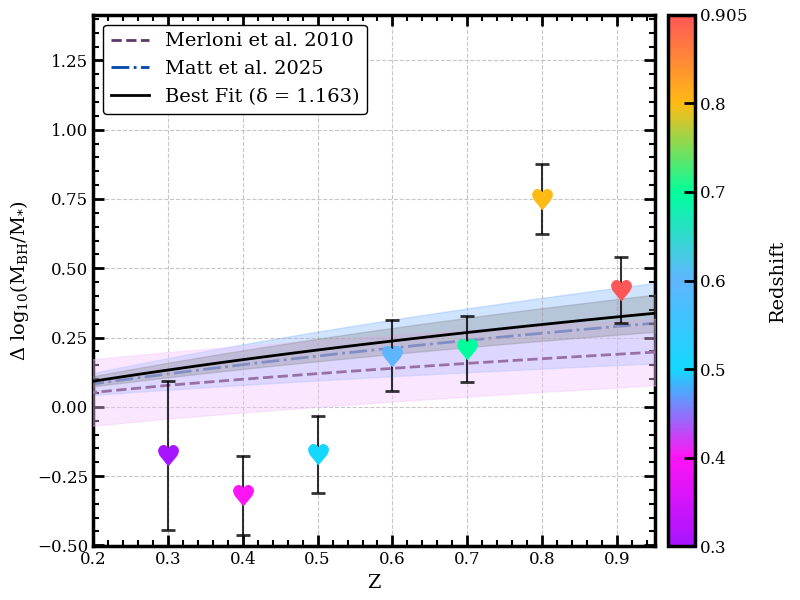

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.cm as cm

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     0.3,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035_a,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_SD_025_035),
    
    ('035_045',
     0.4,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045_a,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_035_045),
    
    ('045_055', 
     0.5,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055_a,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_045_055),
    
    ('055_065',
     0.6,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065_a,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_055_065),
    
    ('065_075', 
     0.7,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075_a,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_065_075),
    
    ('075_085', 
     0.8,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085_a,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_075_085),
    
    ('085_096', 
     0.905,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096_a,
     Delta_BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_085_096)
]






x_fit = np.linspace(0.1, 1.0, 100)

# Define power law function
def delta_Z_fit(x, delta):
    return delta * np.log10(1 + x)

# Extract data for fitting
x_data = np.array([dataset[1] for dataset in datasets])
y_data = np.array([dataset[2] for dataset in datasets])
y_errors = np.array([dataset[3] for dataset in datasets])

# Print data for debugging
print("X data:", x_data)
print("Y data:", y_data)
print("Y errors:", y_errors)

# Perform fitting with better error handling and initial guess
try:
    initial_guess = [0.5]
    popt, pcov = curve_fit(
        delta_Z_fit, 
        x_data, 
        y_data, 
        sigma=y_errors, 
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=5000
    )
    
    delta_fit = popt[0]
    delta_err = np.sqrt(np.diag(pcov))[0]
    fit_successful = True
    
    print(f"Fit successful! Delta = {delta_fit:.3f} ± {delta_err:.3f}")
    
except Exception as e:
    fit_successful = False
    print(f"Fit failed with error: {e}")

# Plot Merloni et al. 2010 reference line
z_ref = np.array([0.0, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905, 1.0])
merloni_line = 0.68 * np.log10(1 + z_ref)

ax.plot(z_ref, merloni_line, linewidth=2, linestyle="--", color="#5E386A", label="Merloni et al. 2010", zorder=5) 
ax.fill_between(z_ref, 
                merloni_line - 0.12, 
                merloni_line + 0.12, 
                color="#F3C5FF", alpha=0.4, zorder=5)

# ADD MATT ET AL. 2025 RELATION
# Parameters from Matt et al. 2025
alpha0 = 8.69
beta0 = 1.17
alpha_z = 1.04
alpha_z_err = 0.5

# Calculate Matt et al. 2025 relation
# M_BH = alpha0 * (1+z)^alpha_z * (M_bulge/10^11 M_sun)^beta0
# Converting to delta log10(M_BH/M_*) form
# Assuming M_bulge ≈ M_* and using a reference point at z=0

def matt_relation(z, alpha_z_val):
    """Calculate the Matt et al. 2025 relation in delta form"""
    # Reference at z=0
    ref_term = alpha0 * (1.0)**alpha_z_val
    # Evolution term
    evol_term = alpha0 * (1 + z)**alpha_z_val
    # Delta in log space
    return np.log10(evol_term) - np.log10(ref_term)

z_matt = np.linspace(0.0, 1.0, 100)
matt_line = matt_relation(z_matt, alpha_z)
matt_upper = matt_relation(z_matt, alpha_z + alpha_z_err)
matt_lower = matt_relation(z_matt, alpha_z - alpha_z_err)

ax.plot(z_matt, matt_line, linewidth=2, color="#0047AB", 
        label="Matt et al. 2025", linestyle='-.', zorder=-10)
ax.fill_between(z_matt, matt_lower, matt_upper, 
                color="#8ABBFF", alpha=0.4, zorder=-10)

# Plot fitted curve if successful
if fit_successful:
    y_fit = delta_Z_fit(x_fit, delta_fit)
    y_fit_upper = delta_Z_fit(x_fit, delta_fit + delta_err)
    y_fit_lower = delta_Z_fit(x_fit, delta_fit - delta_err)
    
    ax.plot(x_fit, y_fit, color='black', linewidth=2, 
            label=f'Best Fit (δ = {delta_fit:.3f})', zorder=30)
    ax.fill_between(x_fit, y_fit_lower, y_fit_upper, 
                   color='gray', alpha=0.3, zorder=25)

# Plot each dataset
for i, (key, x_data_point, y_data_point, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data_point, y_data_point,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10000)

    # Plot error bars
    ax.errorbar(x_data_point, y_data_point,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=100)

# Configure axes labels and title
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Create legend
legend1 = ax.legend(loc='upper left', fontsize=14, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0)

# Configure grid
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.5)

# Set x-axis limits
ax.set_xlim(0.2, 0.95)
#ax.set_ylim(-0.43, 0.5)

# Adjust layout
plt.tight_layout(pad=0.5)


fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Delta_BH_Stella_Z.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')


# Show the figure
plt.show(block=False)





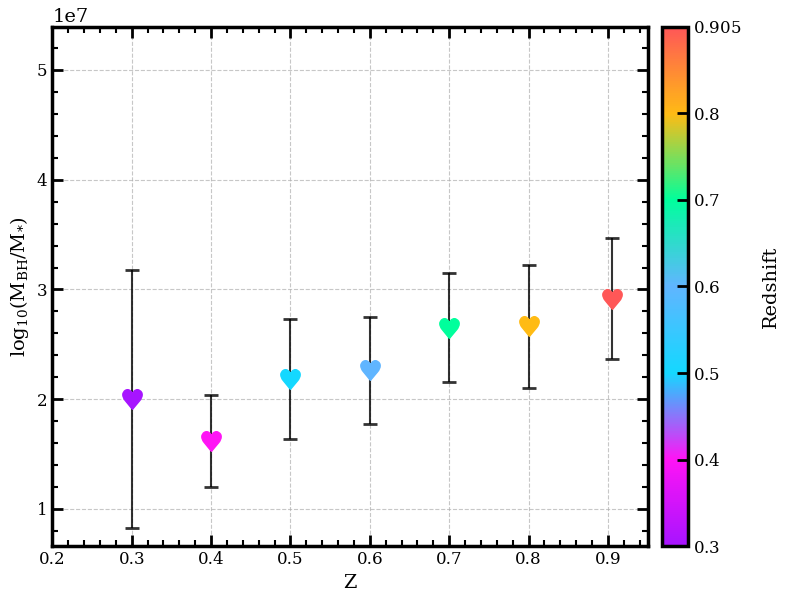

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.cm as cm

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     0.3,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035),
    
    ('035_045',
     0.4,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045),
    
    ('045_055', 
     0.5,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055),
    
    ('055_065',
     0.6,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065),
    
    ('065_075', 
     0.7,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075),
    
    ('075_085', 
     0.8,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085),
    
    ('085_096', 
     0.905,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096,
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096)
]


# Plot each dataset
for i, (key, x_data_point, y_data_point, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data_point, y_data_point,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10000)

    # Plot error bars
    ax.errorbar(x_data_point, y_data_point,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=100)

# Configure axes labels and title
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.5)

# Set x-axis limits
ax.set_xlim(0.2, 0.95)
#ax.set_ylim(-0.43, 0.5)

# Adjust layout
plt.tight_layout(pad=0.5)


fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Mass_Z.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')


# Show the figure
plt.show(block=False)





In [23]:
aaaa

NameError: name 'aaaa' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Broad Component)
datasets = [
    ('025_035', 
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log(10))
     ),
    ('035_045', 
     Delta_BH_Stellar_Broad_AGN_Only_035_045,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     Delta_BH_Stellar_Broad_AGN_Only_SD_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log(10))
     ),
    ('045_055', 
     Delta_BH_Stellar_Broad_AGN_Only_045_055,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     Delta_BH_Stellar_Broad_AGN_Only_SD_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log(10))
     ),
    ('055_065', 
     Delta_BH_Stellar_Broad_AGN_Only_055_065,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     Delta_BH_Stellar_Broad_AGN_Only_SD_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log(10))
     ),
    ('065_075', 
     Delta_BH_Stellar_Broad_AGN_Only_065_075,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     Delta_BH_Stellar_Broad_AGN_Only_SD_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log(10))
     ),
    ('075_085', 
     Delta_BH_Stellar_Broad_AGN_Only_075_085,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     Delta_BH_Stellar_Broad_AGN_Only_SD_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log(10))
     ),
    ('085_096', 
     Delta_BH_Stellar_Broad_AGN_Only_085_096,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     Delta_BH_Stellar_Broad_AGN_Only_SD_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / ( MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log(10))
     )
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(3.4, 3.75)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Narrow Component)
datasets = [
    ('025_035', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_025_035),
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
     Luminosities_AGN_Only_Binned_Data_median_SD_025_035 / ( Luminosities_AGN_Only_Binned_Data_median_025_035 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035),
    ('035_045', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_035_045),
     Delta_BH_Stellar_Broad_AGN_Only_035_045,
     Luminosities_AGN_Only_Binned_Data_median_SD_035_045 / ( Luminosities_AGN_Only_Binned_Data_median_035_045 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_035_045),
    ('045_055', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_045_055),
     Delta_BH_Stellar_Broad_AGN_Only_045_055,
     Luminosities_AGN_Only_Binned_Data_median_SD_045_055 / ( Luminosities_AGN_Only_Binned_Data_median_045_055 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_045_055),
    ('055_065', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_055_065),
     Delta_BH_Stellar_Broad_AGN_Only_055_065,
     Luminosities_AGN_Only_Binned_Data_median_SD_055_065 / ( Luminosities_AGN_Only_Binned_Data_median_055_065 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_055_065),
    ('065_075', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_065_075),
     Delta_BH_Stellar_Broad_AGN_Only_065_075,
     Luminosities_AGN_Only_Binned_Data_median_SD_065_075 / ( Luminosities_AGN_Only_Binned_Data_median_065_075 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_065_075),
    ('075_085', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_075_085),
     Delta_BH_Stellar_Broad_AGN_Only_075_085,
     Luminosities_AGN_Only_Binned_Data_median_SD_075_085 / ( Luminosities_AGN_Only_Binned_Data_median_075_085 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_075_085),
    ('085_096', 
     np.log10(Luminosities_AGN_Only_Binned_Data_median_085_096),
     Delta_BH_Stellar_Broad_AGN_Only_085_096,
     Luminosities_AGN_Only_Binned_Data_median_SD_085_096 / ( Luminosities_AGN_Only_Binned_Data_median_085_096 * np.log(10)),
     Delta_BH_Stellar_Broad_AGN_Only_SD_085_096)
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
ax.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Narrow - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_xlim(40.75, 40.92)
#ax.set_ylim(-0.1, 0.7)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]



# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Median_025_035,
    np.log10(Luminosities_AGN_Only_Binned_Data_median_025_035),
    Stellar_Mass_SD_025_035,
    Luminosities_AGN_Only_Binned_Data_median_SD_025_035 / (Luminosities_AGN_Only_Binned_Data_median_025_035 * np.log(10))), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Median_035_045,
    np.log10(Luminosities_AGN_Only_Binned_Data_median_035_045),
    Stellar_Mass_SD_035_045,
    Luminosities_AGN_Only_Binned_Data_median_SD_035_045 / ( Luminosities_AGN_Only_Binned_Data_median_035_045 * np.log(10))),
    ('045_055', 
    Stellar_Mass_Median_045_055,
    np.log10(Luminosities_AGN_Only_Binned_Data_median_045_055),
    Stellar_Mass_SD_045_055,
    Luminosities_AGN_Only_Binned_Data_median_SD_045_055 / ( Luminosities_AGN_Only_Binned_Data_median_045_055 * np.log(10))),
    ('055_065', 
    Stellar_Mass_Median_055_065,
    np.log10(Luminosities_AGN_Only_Binned_Data_median_055_065),
    Stellar_Mass_SD_055_065,
    Luminosities_AGN_Only_Binned_Data_median_SD_055_065 / ( Luminosities_AGN_Only_Binned_Data_median_055_065 * np.log(10))),
    ('065_075', 
    Stellar_Mass_Median_065_075,
    np.log10(Luminosities_AGN_Only_Binned_Data_median_065_075),
    Stellar_Mass_SD_065_075,
    Luminosities_AGN_Only_Binned_Data_median_SD_065_075 / ( Luminosities_AGN_Only_Binned_Data_median_065_075 * np.log(10))),
    ('075_085', 
    Stellar_Mass_Median_075_085,
    np.log10(Luminosities_AGN_Only_Binned_Data_median_075_085),
    Stellar_Mass_SD_075_085,
    Luminosities_AGN_Only_Binned_Data_median_SD_075_085 / ( Luminosities_AGN_Only_Binned_Data_median_075_085 * np.log(10))),
    ('085_096', 
    Stellar_Mass_Median_085_096,
    np.log10(Luminosities_AGN_Only_Binned_Data_median_085_096),
    Stellar_Mass_SD_085_096,
    Luminosities_AGN_Only_Binned_Data_median_SD_085_096 / ( Luminosities_AGN_Only_Binned_Data_median_085_096 * np.log(10)))
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(Continuum L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(40.75, 40.93)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10))), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10))),
    ('045_055', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10))),
    ('055_065', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10))),
    ('065_075', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10))),
    ('075_085', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085*np.log(10))),
    ('085_096', 
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10)))
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    0.3,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10))
    ), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    0.4,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10))
    ),
    ('045_055', 
    0.5,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10))
    ),
    ('055_065', 
    0.6,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10))
    ),
    ('065_075', 
    0.7,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10))
    ),
    ('075_085', 
    0.8,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085*np.log(10))
    ),
    ('085_096', 
    0.905,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10))
    )
]



# Plot each dataset
for i, (key, x_data, y_data, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]


# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Median_025_035,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
    Stellar_Mass_SD_025_035,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10))), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Median_035_045,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
    Stellar_Mass_SD_035_045,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10))),
    ('045_055', 
    Stellar_Mass_Median_045_055,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
    Stellar_Mass_SD_045_055,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10))),
    ('055_065', 
    Stellar_Mass_Median_055_065,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
    Stellar_Mass_SD_055_065,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10))),
    ('065_075', 
    Stellar_Mass_Median_065_075,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
    Stellar_Mass_SD_065_075,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10))),
    ('075_085', 
    Stellar_Mass_Median_075_085,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
    Stellar_Mass_SD_075_085,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10))),
    ('085_096', 
    Stellar_Mass_Median_085_096,
    np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
    Stellar_Mass_SD_085_096,
    MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)))
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (FWHM vs Luminosity - Narrow Component)
datasets = [
    ('025_035', 
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10))),
    ('035_045', 
     Delta_BH_Stellar_Broad_AGN_Only_035_045,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     Delta_BH_Stellar_Broad_AGN_Only_SD_035_045,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10))),
    ('045_055', 
     Delta_BH_Stellar_Broad_AGN_Only_045_055,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     Delta_BH_Stellar_Broad_AGN_Only_SD_045_055,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10))),
    ('055_065', 
     Delta_BH_Stellar_Broad_AGN_Only_055_065,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     Delta_BH_Stellar_Broad_AGN_Only_SD_055_065,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10))),
    ('065_075', 
     Delta_BH_Stellar_Broad_AGN_Only_065_075,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     Delta_BH_Stellar_Broad_AGN_Only_SD_065_075,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10))),
    ('075_085', 
     Delta_BH_Stellar_Broad_AGN_Only_075_085,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     Delta_BH_Stellar_Broad_AGN_Only_SD_075_085,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10))),
    ('085_096', 
     Delta_BH_Stellar_Broad_AGN_Only_085_096,
     np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     Delta_BH_Stellar_Broad_AGN_Only_SD_085_096,
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)))
]

# Plot each dataset
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Narrow - FeII Removed", fontsize=14, pad=15)

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)


# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')

# Save and show the figure
plt.show(block=False)



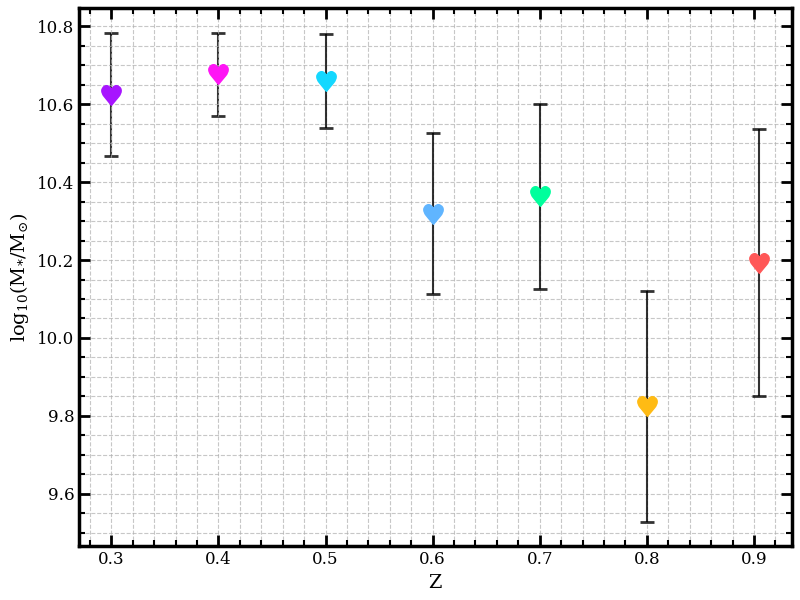

In [166]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]


# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    0.3,
    Stellar_Mass_Median_025_035,
    Stellar_Mass_SD_025_035), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    0.4,
    Stellar_Mass_Median_035_045,
    Stellar_Mass_SD_035_045),
    ('045_055', 
    0.5,
    Stellar_Mass_Median_045_055,
    Stellar_Mass_SD_045_055),
    ('055_065', 
    0.6,
    Stellar_Mass_Median_055_065,
    Stellar_Mass_SD_055_065),
    ('065_075', 
    0.7,
    Stellar_Mass_Median_065_075,
    Stellar_Mass_SD_065_075),
    ('075_085', 
    0.8,
    Stellar_Mass_Median_075_085,
    Stellar_Mass_SD_075_085),
    ('085_096', 
    0.905,
    Stellar_Mass_Median_085_096,
    Stellar_Mass_SD_085_096)
]



# Plot each dataset
for i, (key, x_data, y_data, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
        
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title 
ax.set_xlabel(r"Z", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
#ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


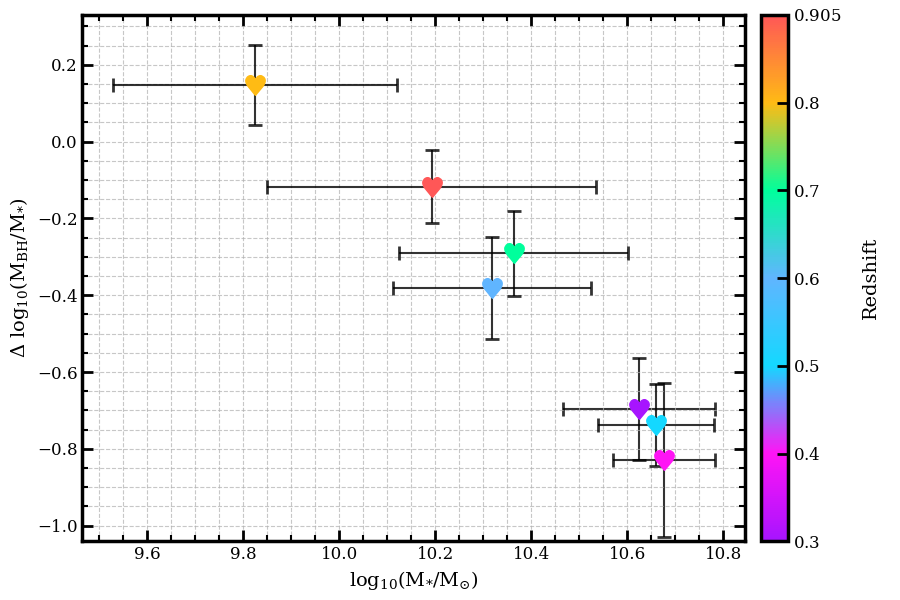

In [149]:
import matplotlib.pyplot as plt
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(9, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Median_025_035,
    Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035,
    Stellar_Mass_SD_025_035,
    Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Median_035_045,
    Delta_BH_Stellar_Broad_AGN_Only_035_045,
    Stellar_Mass_SD_035_045,
    Delta_BH_Stellar_Broad_AGN_Only_SD_035_045),
    ('045_055', 
    Stellar_Mass_Median_045_055,
    Delta_BH_Stellar_Broad_AGN_Only_045_055,
    Stellar_Mass_SD_045_055,
    Delta_BH_Stellar_Broad_AGN_Only_SD_045_055),
    ('055_065', 
    Stellar_Mass_Median_055_065,
    Delta_BH_Stellar_Broad_AGN_Only_055_065,
    Stellar_Mass_SD_055_065,
    Delta_BH_Stellar_Broad_AGN_Only_SD_055_065),
    ('065_075', 
    Stellar_Mass_Median_065_075,
    Delta_BH_Stellar_Broad_AGN_Only_065_075,
    Stellar_Mass_SD_065_075,
    Delta_BH_Stellar_Broad_AGN_Only_SD_065_075),
    ('075_085', 
    Stellar_Mass_Median_075_085,
    Delta_BH_Stellar_Broad_AGN_Only_075_085,
    Stellar_Mass_SD_075_085,
    Delta_BH_Stellar_Broad_AGN_Only_SD_075_085),
    ('085_096', 
    Stellar_Mass_Median_085_096,
    Delta_BH_Stellar_Broad_AGN_Only_085_096,
    Stellar_Mass_SD_085_096,
    Delta_BH_Stellar_Broad_AGN_Only_SD_085_096)
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, yerr) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr = yerr,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

## Configure legend with MNRAS style
#legend = ax.legend(
#    loc='lower left',
#    fontsize=12,
#    frameon=True,
#    fancybox=True,
#    shadow=True,
#    borderpad=0.8,
#    handletextpad=0.6,
#    columnspacing=1.0,
#    handlelength=1.0,
#    labelspacing=1.0,
#    numpoints=1
#)
#legend.get_frame().set_linewidth(1.5)
#legend.get_frame().set_edgecolor('black')

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


## <font color='#00879E' size=5 >Adding in other data - from the Luminosity Corrected data - Uniform Narrow Sigma - FeII Removed </font>


In [ ]:
##https://iopscience.iop.org/article/10.1088/0004-637X/813/2/82/pdf

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23}, 

]

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme from the original heart markers (keeping the same vibrant colors)
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"] #Purple (deep/cool), Pink, Teal, Blue, Green, Orange, Red (warm)


# Single color for heart markers (choose one from the original palette)
heart_color = "#a714ff"  # Using the teal color for all hearts

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
    Stellar_Mass_Median_025_035,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035),
    Stellar_Mass_SD_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10))),
    ('035_045', 
    Stellar_Mass_Median_035_045,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
    Stellar_Mass_SD_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10))),
    ('045_055', 
    Stellar_Mass_Median_045_055,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
    Stellar_Mass_SD_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10))),
    ('055_065', 
    Stellar_Mass_Median_055_065,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
    Stellar_Mass_SD_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10))),
    ('065_075', 
    Stellar_Mass_Median_065_075,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
    Stellar_Mass_SD_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10))),
    ('075_085', 
    Stellar_Mass_Median_075_085,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
    Stellar_Mass_SD_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085*np.log(10))),
    ('085_096', 
    Stellar_Mass_Median_085_096,
    np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
    Stellar_Mass_SD_085_096,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10)))
]

# Plot each dataset with the same heart marker color - single legend entry
for i, (key, x_data, y_data, x_err, y_err) in enumerate(datasets):
    # Plot data points with heart markers (all same color)
    ax.scatter(x_data, y_data,
              color=heart_color,
              edgecolor="black",
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label='This Work' if i == 0 else '')
    
    # Plot error bars (all black)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Add galaxy data to the plot with fun shaped markers
# Extract data for plotting
dwarf_x = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y_err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
reverberation_y_err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y_err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

# Plot dwarf galaxies with broad-line AGNs using star marker
ax.scatter(dwarf_x, dwarf_y,
          color=dataset_colors[2],  # Bright teal
          s=200,
          marker=u"$\u2605$",  # Star marker
          alpha=1.0,
          edgecolors='black',
          linewidth=1,
          zorder=20,
          label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars (all black)
ax.errorbar(dwarf_x, dwarf_y,
           yerr=dwarf_y_err,
           linestyle='',
           ecolor='black',
           capsize=5,
           capthick=2,
           elinewidth=1.5,
           alpha=0.8,
           zorder=0)

# Plot reverberation-mapped AGNs using diamond marker
ax.scatter(reverberation_x, reverberation_y,
          color=dataset_colors[4],  # Green
          s=200,
          marker="D",  # Diamond suit marker
          alpha=1.0,
          edgecolors='black',
          linewidth=1,
          zorder=20,
          label='Reverberation-mapped AGNs')

# Plot error bars (all black)
ax.errorbar(reverberation_x, reverberation_y,
           yerr=reverberation_y_err,
           linestyle='',
           ecolor='black',
           capsize=5,
           capthick=2,
           elinewidth=1.5,
           alpha=0.8,
           zorder=0)

# Plot galaxies with dynamical BH masses using sun marker
ax.scatter(dynamical_x, dynamical_y,
          color=dataset_colors[5],  # Orange
          s=200,
          marker=u"$\u2600$",  # Sun marker
          alpha=1.0,
          edgecolors='black',
          linewidth=1,
          zorder=20,
          label='Galaxies with Dynamical BH Masses')

# Plot error bars (all black)
ax.errorbar(dynamical_x, dynamical_y,
           yerr=dynamical_y_err,
           linestyle='',
           ecolor='black',
           capsize=5,
           capthick=2,
           elinewidth=1.5,
           alpha=0.8,
           zorder=0)

# Configure axes labels
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

# Create legend
legend1 = ax.legend(loc='upper left', fontsize=12, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Modified_Plot.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Modified_Plot.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]

# Your data with redshift and stellar mass values
our_data = [
    {"name": "025_035", "redshift": 0.3, "logMs": 9.5, "logMs_uncertainty": 0.1},  # Placeholder stellar mass
    {"name": "035_045", "redshift": 0.4, "logMs": 10.0, "logMs_uncertainty": 0.1},
    {"name": "045_055", "redshift": 0.5, "logMs": 10.2, "logMs_uncertainty": 0.1},
    {"name": "055_065", "redshift": 0.6, "logMs": 10.5, "logMs_uncertainty": 0.1},
    {"name": "065_075", "redshift": 0.7, "logMs": 10.8, "logMs_uncertainty": 0.1},
    {"name": "075_085", "redshift": 0.8, "logMs": 11.0, "logMs_uncertainty": 0.1},
    {"name": "085_096", "redshift": 0.905, "logMs": 11.2, "logMs_uncertainty": 0.1}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Extract data for plotting
our_x = [data["redshift"] for data in our_data]
our_y = [data["logMs"] for data in our_data]
our_y_err = [data["logMs_uncertainty"] for data in our_data]

dwarf_x = [galaxy["redshift"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["redshift"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["redshift"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Stellar_Mass_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Stellar_Mass_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]

# Your data with redshift and black hole mass values
our_data = [
    {"name": "025_035", "redshift": 0.3, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10))},  # Placeholder BH mass
    {"name": "035_045", "redshift": 0.4, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10))},
    {"name": "045_055", "redshift": 0.5, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10))},
    {"name": "055_065", "redshift": 0.6, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10))},
    {"name": "065_075", "redshift": 0.7, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10))},
    {"name": "075_085", "redshift": 0.8, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085*np.log(10))},
    {"name": "085_096", "redshift": 0.905, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10))}
]


# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Extract data for plotting
our_x = [data["redshift"] for data in our_data]
our_y = [data["logMBH"] for data in our_data]
our_y_err = [data["logMBH_uncertainty"] for data in our_data]

dwarf_x = [galaxy["redshift"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y_err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["redshift"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
reverberation_y_err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["redshift"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y_err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("Stellar_Mass_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("Stellar_Mass_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]

# Your data with redshift and black hole mass values
our_data = [
    {"name": "025_035", "redshift": 0.3, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10)), "logMs": 9.8},
    {"name": "035_045", "redshift": 0.4, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10)), "logMs": 10.1},
    {"name": "045_055", "redshift": 0.5, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10)), "logMs": 10.3},
    {"name": "055_065", "redshift": 0.6, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10)), "logMs": 10.5},
    {"name": "065_075", "redshift": 0.7, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10)), "logMs": 10.7},
    {"name": "075_085", "redshift": 0.8, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085*np.log(10)), "logMs": 10.9},
    {"name": "085_096", "redshift": 0.905, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096), "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10)), "logMs": 11.1}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate log(MBH/Ms) for all datasets
def calculate_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    for data in data_list:
        x_vals.append(data["redshift"])
        # Calculate log(MBH/Ms) = log(MBH) - log(Ms)
        mass_ratio = data["logMBH"] - data["logMs"]
        y_vals.append(mass_ratio)
        # Error propagation: since we're subtracting logs, uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
our_x, our_y, our_y_err = calculate_mass_ratio(our_data)
dwarf_x, dwarf_y, dwarf_y_err = calculate_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_mass_ratio(galaxiesWithDynamicalBHMasses)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]

# Your data using pre-calculated delta values
our_data = [
    {"name": "025_035", "redshift": 0.3, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035},
    {"name": "035_045", "redshift": 0.4, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_035_045, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_035_045},
    {"name": "045_055", "redshift": 0.5, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_045_055, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_045_055},
    {"name": "055_065", "redshift": 0.6, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_055_065, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_055_065},
    {"name": "065_075", "redshift": 0.7, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_065_075, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_065_075},
    {"name": "075_085", "redshift": 0.8, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_075_085, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_075_085},
    {"name": "085_096", "redshift": 0.905, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_085_096, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_085_096}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate Delta log(MBH/Ms) for all datasets
def calculate_delta_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    # Reference value: log10(0.0025)
    log_reference = np.log10(0.0025)
    
    for data in data_list:
        x_vals.append(data["redshift"])
        # Calculate Delta log(MBH/Ms) = log(MBH/Ms) - log(0.0025)
        # This is equivalent to: log(MBH) - log(Ms) - log(0.0025)
        mass_ratio = data["logMBH"] - data["logMs"]
        delta_mass_ratio = mass_ratio - log_reference
        y_vals.append(delta_mass_ratio)
        # Error propagation: since we're subtracting logs, uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
# For our data, use pre-calculated values directly
our_x = [data["redshift"] for data in our_data]
our_y = [data["delta_value"] for data in our_data]
our_y_err = [data["delta_uncertainty"] for data in our_data]

# For comparison data, calculate delta values
dwarf_x, dwarf_y, dwarf_y_err = calculate_delta_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_delta_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_delta_mass_ratio(galaxiesWithDynamicalBHMasses)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]


# Your data using pre-calculated delta values
our_data = [
    {"name": "025_035", "redshift": 0.3, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035},
    {"name": "035_045", "redshift": 0.4, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_035_045, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_035_045},
    {"name": "045_055", "redshift": 0.5, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_045_055, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_045_055},
    {"name": "055_065", "redshift": 0.6, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_055_065, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_055_065},
    {"name": "065_075", "redshift": 0.7, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_065_075, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_065_075},
    {"name": "075_085", "redshift": 0.8, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_075_085, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_075_085},
    {"name": "085_096", "redshift": 0.905, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_085_096, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_085_096}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate Delta log(MBH/Ms) relative to scaling relation
def calculate_delta_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    # Scaling relation parameters
    alpha = 7.45
    beta = 1.05
    
    for data in data_list:
        x_vals.append(data["redshift"])
        
        # Calculate observed log(MBH/Ms)
        observed_mass_ratio = data["logMBH"] - data["logMs"]
        
        # Calculate expected log(MBH) from scaling relation
        # log(MBH/M☉) = α + β * log(Mstellar/10^11 M☉)
        # log(Mstellar/10^11 M☉) = log(Mstellar) - 11 = logMs - 11
        log_stellar_scaled = data["logMs"] - 11.0
        expected_log_MBH = alpha + beta * log_stellar_scaled
        
        # Calculate expected log(MBH/Ms)
        expected_mass_ratio = expected_log_MBH - data["logMs"]
        
        # Calculate delta: observed - expected
        delta_mass_ratio = observed_mass_ratio - expected_mass_ratio
        y_vals.append(delta_mass_ratio)
        
        # Error propagation: uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
# For our data, use pre-calculated delta values directly
our_x = [data["redshift"] for data in our_data]
our_y = [data["delta_value"] for data in our_data]
our_y_err = [data["delta_uncertainty"] for data in our_data]

# For comparison data, calculate delta values using same reference
dwarf_x, dwarf_y, dwarf_y_err = calculate_delta_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_delta_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_delta_mass_ratio(galaxiesWithDynamicalBHMasses)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
"""
Getting the delta black hole mass over stellar mass and the standard deviation
relative to the scaling relation
"""
import numpy as np

def standard_deviation_delta_BH_Stellar_relation(M_BH, M_BH_SD, M_Stellar, M_Stellar_SD, alpha=7.45, beta=1.05, alpha_SD=0.08, beta_SD=0.11):
    """
    This code finds the standard deviation for the delta black hole stellar mass relation
    relative to the scaling relation: log(MBH/M☉) = α + β * log(Mstellar/10^11 M☉)

    Parameters
    ----------
    M_BH: Black hole mass [NOT Log]
    M_BH_SD: Black hole mass standard deviation

    M_Stellar: Stellar mass [NOT log]
    M_Stellar_SD: Stellar mass standard deviation average [NOT log] 

    alpha: Scaling relation intercept (default: 7.45)
    beta: Scaling relation slope (default: 1.05)
    alpha_SD: Scaling relation intercept error (default: 0.08)
    beta_SD: Scaling relation slope error (default: 0.11)

    Return
    ------
    Delta_BH_Stellar_SD: The standard deviation for the delta black hole stellar mass relation
    """
    
    # Convert to log space
    log_M_BH = np.log10(M_BH)
    log_M_Stellar = np.log10(M_Stellar)
    
    # Calculate scaling relation prediction
    log_stellar_scaled = log_M_Stellar - 11.0  # log(Mstellar/10^11 M☉)
    expected_log_MBH = alpha + beta * log_stellar_scaled
    
    # Partial derivatives for error propagation
    # For observed log(MBH/Ms): d/d(log_MBH) = 1, d/d(log_Ms) = -1
    # For expected: d/d(alpha) = -1, d/d(beta) = -log_stellar_scaled, d/d(log_Ms) = beta
    
    # Error propagation terms
    term_MBH = (1 / (M_BH * np.log(10)) * M_BH_SD)**2  # from M_BH uncertainty
    term_Ms_observed = (-1 / (M_Stellar * np.log(10)) * M_Stellar_SD)**2  # from Ms in observed ratio
    term_Ms_expected = (beta / (M_Stellar * np.log(10)) * M_Stellar_SD)**2  # from Ms in expected ratio
    term_alpha = (-alpha_SD)**2  # from alpha uncertainty
    term_beta = (log_stellar_scaled * beta_SD)**2  # from beta uncertainty
    
    return np.sqrt(term_MBH + term_Ms_observed + term_Ms_expected + term_alpha + term_beta)


def calculate_delta_BH_stellar_relation(BH_Mass, Stellar_Mass_log, alpha=7.45, beta=1.05):
    """
    Calculate delta relative to scaling relation
    
    Parameters
    ----------
    BH_Mass: Black hole mass [NOT log]
    Stellar_Mass_log: log10(Stellar mass)
    alpha: Scaling relation intercept
    beta: Scaling relation slope
    
    Returns
    -------
    Delta value relative to scaling relation
    """
    # Observed log(MBH/Ms)
    observed_ratio = np.log10(BH_Mass) - Stellar_Mass_log
    
    # Expected log(MBH) from scaling relation
    log_stellar_scaled = Stellar_Mass_log - 11.0
    expected_log_MBH = alpha + beta * log_stellar_scaled
    
    # Expected log(MBH/Ms)
    expected_ratio = expected_log_MBH - Stellar_Mass_log
    
    # Delta = observed - expected
    return observed_ratio - expected_ratio


# Getting the delta black hole stellar mass relation (relative to scaling relation)
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, 
    Stellar_Mass_Median_025_035)

Delta_BH_Stellar_Broad_AGN_Only_035_045_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, 
    Stellar_Mass_Median_035_045)

Delta_BH_Stellar_Broad_AGN_Only_045_055_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, 
    Stellar_Mass_Median_045_055)

Delta_BH_Stellar_Broad_AGN_Only_055_065_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, 
    Stellar_Mass_Median_055_065)

Delta_BH_Stellar_Broad_AGN_Only_065_075_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, 
    Stellar_Mass_Median_065_075)

Delta_BH_Stellar_Broad_AGN_Only_075_085_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, 
    Stellar_Mass_Median_075_085)

Delta_BH_Stellar_Broad_AGN_Only_085_096_Relation = calculate_delta_BH_stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, 
    Stellar_Mass_Median_085_096)


# Getting the standard deviation for the delta black hole stellar mass relation (relative to scaling relation)
Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035, 
    10**Stellar_Mass_Median_025_035, 
    10**Stellar_Mass_SD_025_035)

Delta_BH_Stellar_Broad_AGN_Only_SD_035_045_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045, 
    10**Stellar_Mass_Median_035_045, 
    10**Stellar_Mass_SD_035_045)

Delta_BH_Stellar_Broad_AGN_Only_SD_045_055_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055, 
    10**Stellar_Mass_Median_045_055, 
    10**Stellar_Mass_SD_045_055)

Delta_BH_Stellar_Broad_AGN_Only_SD_055_065_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065, 
    10**Stellar_Mass_Median_055_065, 
    10**Stellar_Mass_SD_055_065)

Delta_BH_Stellar_Broad_AGN_Only_SD_065_075_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075, 
    10**Stellar_Mass_Median_065_075, 
    10**Stellar_Mass_SD_065_075)

Delta_BH_Stellar_Broad_AGN_Only_SD_075_085_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085, 
    10**Stellar_Mass_Median_075_085, 
    10**Stellar_Mass_SD_075_085)

Delta_BH_Stellar_Broad_AGN_Only_SD_085_096_Relation = standard_deviation_delta_BH_Stellar_relation(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096, 
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096, 
    10**Stellar_Mass_Median_085_096, 
    10**Stellar_Mass_SD_085_096)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]


# Your data using pre-calculated delta values (relative to scaling relation)
our_data = [
    {"name": "025_035", "redshift": 0.3, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035_Relation},
    {"name": "035_045", "redshift": 0.4, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_035_045_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_035_045_Relation},
    {"name": "045_055", "redshift": 0.5, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_045_055_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_045_055_Relation},
    {"name": "055_065", "redshift": 0.6, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_055_065_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_055_065_Relation},
    {"name": "065_075", "redshift": 0.7, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_065_075_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_065_075_Relation},
    {"name": "075_085", "redshift": 0.8, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_075_085_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_075_085_Relation},
    {"name": "085_096", "redshift": 0.905, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_085_096_Relation, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_SD_085_096_Relation}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate Delta log(MBH/Ms) relative to scaling relation
def calculate_delta_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    # Scaling relation parameters
    alpha = 7.45
    beta = 1.05
    
    for data in data_list:
        x_vals.append(data["redshift"])
        
        # Calculate observed log(MBH/Ms)
        observed_mass_ratio = data["logMBH"] - data["logMs"]
        
        # Calculate expected log(MBH) from scaling relation
        # log(MBH/M☉) = α + β * log(Mstellar/10^11 M☉)
        # log(Mstellar/10^11 M☉) = log(Mstellar) - 11 = logMs - 11
        log_stellar_scaled = data["logMs"] - 11.0
        expected_log_MBH = alpha + beta * log_stellar_scaled
        
        # Calculate expected log(MBH/Ms)
        expected_mass_ratio = expected_log_MBH - data["logMs"]
        
        # Calculate delta: observed - expected
        delta_mass_ratio = observed_mass_ratio - expected_mass_ratio
        y_vals.append(delta_mass_ratio)
        
        # Error propagation: uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
# For our data, use pre-calculated delta values directly
our_x = [data["redshift"] for data in our_data]
our_y = [data["delta_value"] for data in our_data]
our_y_err = [data["delta_uncertainty"] for data in our_data]

# For comparison data, calculate delta values using same reference
dwarf_x, dwarf_y, dwarf_y_err = calculate_delta_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_delta_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_delta_mass_ratio(galaxiesWithDynamicalBHMasses)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)



In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(9, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]

# Dataset configuration for plotting (Black Hole Mass vs Stellar Mass - Scaling Relation)
datasets = [
    ('025_035', 
    Stellar_Mass_Median_025_035,
    Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_025_035_Relation,
    Stellar_Mass_SD_025_035,
    Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_SD_025_035_Relation), #To turn value into log10 => error / (M_bh * ln(10))
    ('035_045', 
    Stellar_Mass_Median_035_045,
    Delta_BH_Stellar_Broad_AGN_Only_035_045_Relation,
    Stellar_Mass_SD_035_045,
    Delta_BH_Stellar_Broad_AGN_Only_SD_035_045_Relation),
    ('045_055', 
    Stellar_Mass_Median_045_055,
    Delta_BH_Stellar_Broad_AGN_Only_045_055_Relation,
    Stellar_Mass_SD_045_055,
    Delta_BH_Stellar_Broad_AGN_Only_SD_045_055_Relation),
    ('055_065', 
    Stellar_Mass_Median_055_065,
    Delta_BH_Stellar_Broad_AGN_Only_055_065_Relation,
    Stellar_Mass_SD_055_065,
    Delta_BH_Stellar_Broad_AGN_Only_SD_055_065_Relation),
    ('065_075', 
    Stellar_Mass_Median_065_075,
    Delta_BH_Stellar_Broad_AGN_Only_065_075_Relation,
    Stellar_Mass_SD_065_075,
    Delta_BH_Stellar_Broad_AGN_Only_SD_065_075_Relation),
    ('075_085', 
    Stellar_Mass_Median_075_085,
    Delta_BH_Stellar_Broad_AGN_Only_075_085_Relation,
    Stellar_Mass_SD_075_085,
    Delta_BH_Stellar_Broad_AGN_Only_SD_075_085_Relation),
    ('085_096', 
    Stellar_Mass_Median_085_096,
    Delta_BH_Stellar_Broad_AGN_Only_085_096_Relation,
    Stellar_Mass_SD_085_096,
    Delta_BH_Stellar_Broad_AGN_Only_SD_085_096_Relation)
]



# Plot each dataset
for i, (key, x_data, y_data, x_err, yerr) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data, y_data,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10+i,
              label=labels[i])
    
    
    # Plot error bars (both x and y directions)
    ax.errorbar(x_data, y_data,
               xerr=x_err,
               yerr = yerr,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=i)

# Configure axes labels and title
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")
#ax.set_title("Fixed Narrow Component Double Gaussian - Luminosity Corrected - Broad - FeII Removed", fontsize=14, pad=15)

## Configure legend with MNRAS style
#legend = ax.legend(
#    loc='lower left',
#    fontsize=12,
#    frameon=True,
#    fancybox=True,
#    shadow=True,
#    borderpad=0.8,
#    handletextpad=0.6,
#    columnspacing=1.0,
#    handlelength=1.0,
#    labelspacing=1.0,
#    numpoints=1
#)
#legend.get_frame().set_linewidth(1.5)
#legend.get_frame().set_edgecolor('black')

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=0)

# Configure grid
ax.grid(visible=True, which='both', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness (MNRAS style)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Extend the upper y-limit slightly
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin/1.05, ymax * 1.05)

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Relation.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("AGN_Gaussian_Sersic_Fit_MNRAS_Ready_085_096_Relation.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Save and show the figure
plt.show(block=False)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50, "redshift": 0.0459},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50, "redshift": 0.0466},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50, "redshift": 0.0313},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50, "redshift": 0.0144},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50, "redshift": 0.0011},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50, "redshift": 0.0299},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50, "redshift": 0.0410},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50, "redshift": 0.0243},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50, "redshift": 0.0384},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50, "redshift": 0.0395},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50, "redshift": 0.0317},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50, "redshift": 0.0218}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07, "redshift": 0.02639},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12, "redshift": 0.02219},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10, "redshift": 0.03529},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10, "redshift": 0.00386},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08, "redshift": 0.02787},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05, "redshift": 0.02109},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08, "redshift": 0.01956},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14, "redshift": 0.00234},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17, "redshift": 0.02102},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05, "redshift": 0.01293},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14, "redshift": 0.00106},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16, "redshift": 0.00362},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02, "redshift": 0.01718},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07, "redshift": 0.03146},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06, "redshift": 0.02958}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18, "redshift": 0.00067},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07, "redshift": 0.00587},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06, "redshift": 0.0054},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04, "redshift": 0.0043},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33, "redshift": 0.0048}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05, "redshift": 0.0059}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07, "redshift": 0.0124}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02, "redshift": 0.017}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04, "redshift": 0.0122}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23, "redshift": 0.0022}, 
]


# Your data using pre-calculated delta values (relative to scaling relation)
our_data = [
    {"name": "025_035", "redshift": 0.3, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_FeII_Removed_025_035, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_FeII_Removed_NOT_Corrected_SD_025_035},
    {"name": "035_045", "redshift": 0.4, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_035_045, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_035_045},
    {"name": "045_055", "redshift": 0.5, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_045_055, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_045_055},
    {"name": "055_065", "redshift": 0.6, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_055_065, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_055_065},
    {"name": "065_075", "redshift": 0.7, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_065_075, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_065_075},
    {"name": "075_085", "redshift": 0.8, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_075_085, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_075_085},
    {"name": "085_096", "redshift": 0.905, "delta_value": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_085_096, "delta_uncertainty": Delta_BH_Stellar_Broad_AGN_Only_NOT_Corrected_SD_085_096}
]

# Create figure with two subplots sharing the y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), facecolor='white', sharey=True)
fig.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]

# Calculate Delta log(MBH/Ms) relative to scaling relation
def calculate_delta_mass_ratio(data_list):
    x_vals = []
    y_vals = []
    y_err_vals = []
    
    # Scaling relation parameters
    alpha = 7.45
    beta = 1.05
    
    for data in data_list:
        x_vals.append(data["redshift"])
        
        # Calculate observed log(MBH/Ms)
        observed_mass_ratio = data["logMBH"] - data["logMs"]
        
        # Calculate expected log(MBH) from scaling relation
        # log(MBH/M☉) = α + β * log(Mstellar/10^11 M☉)
        # log(Mstellar/10^11 M☉) = log(Mstellar) - 11 = logMs - 11
        log_stellar_scaled = data["logMs"] - 11.0
        expected_log_MBH = alpha + beta * log_stellar_scaled
        
        # Calculate expected log(MBH/Ms)
        expected_mass_ratio = expected_log_MBH - data["logMs"]
        
        # Calculate delta: observed - expected
        delta_mass_ratio = observed_mass_ratio - expected_mass_ratio
        y_vals.append(delta_mass_ratio)
        
        # Error propagation: uncertainty remains the same for MBH
        y_err_vals.append(data["logMBH_uncertainty"])
    
    return x_vals, y_vals, y_err_vals

# Extract data for plotting
# For our data, use pre-calculated delta values directly
our_x = [data["redshift"] for data in our_data]
our_y = [data["delta_value"] for data in our_data]
our_y_err = [data["delta_uncertainty"] for data in our_data]

# For comparison data, calculate delta values using same reference
dwarf_x, dwarf_y, dwarf_y_err = calculate_delta_mass_ratio(dwarfGalaxiesWithBroadlineAGNs)
reverberation_x, reverberation_y, reverberation_y_err = calculate_delta_mass_ratio(reverberationMappedAGNs)
dynamical_x, dynamical_y, dynamical_y_err = calculate_delta_mass_ratio(galaxiesWithDynamicalBHMasses)

# Combine all left plot data for standard deviation calculation
all_left_y = dwarf_y + reverberation_y + dynamical_y
std_dev = np.std(all_left_y)

# Add y=0 reference lines for both plots
ax1.axhline(y=0, color='black', linestyle='-', linewidth=4, alpha=1.0, zorder=5)

# Add shaded region for ±1 standard deviation around zero
ax1.fill_between(x=np.arange(-0.50, 0.055, 0.001), y1 = -std_dev, y2 = std_dev, color='#3B3B3B', alpha=0.08)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=4, alpha=1.0, zorder=5)


# Fit a line to our data for the right plot
our_x_np = np.array(our_x)
our_y_np = np.array(our_y)
coeffs = np.polyfit(our_x_np, our_y_np, 1)  # Linear fit
fit_line = np.poly1d(coeffs)

# Create smooth line for the fit
x_fit = np.linspace(min(our_x), max(our_x), 100)
y_fit = fit_line(x_fit)

# Add trend line for our data (black dotted)
ax2.plot(x_fit, y_fit, color='black', linestyle=':', linewidth=4, alpha=1.0, zorder=5)

# Plot comparison data on left subplot (low redshift)
# Dwarf galaxies
ax1.scatter(dwarf_x, dwarf_y,
           color=dataset_colors[2],  # Bright teal
           s=200,
           marker=u"$\u2605$",  # Star marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Dwarf Galaxies with Broad-line AGNs')

# Plot error bars for dwarf galaxies
ax1.errorbar(dwarf_x, dwarf_y,
            yerr=dwarf_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Reverberation-mapped AGNs
ax1.scatter(reverberation_x, reverberation_y,
           color=dataset_colors[4],  # Green
           s=200,
           marker="D",  # Diamond marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Reverberation-mapped AGNs')

# Plot error bars for reverberation-mapped AGNs
ax1.errorbar(reverberation_x, reverberation_y,
            yerr=reverberation_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Dynamical BH masses
ax1.scatter(dynamical_x, dynamical_y,
           color=dataset_colors[5],  # Orange
           s=200,
           marker=u"$\u2600$",  # Sun marker
           alpha=1.0,
           edgecolors='black',
           linewidth=1,
           zorder=20,
           label='Galaxies with Dynamical BH Masses')

# Plot error bars for dynamical BH masses
ax1.errorbar(dynamical_x, dynamical_y,
            yerr=dynamical_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Plot our data on right subplot (high redshift)
ax2.scatter(our_x, our_y,
           color=dataset_colors[0],  # Purple
           edgecolor="black",
           s=200,
           marker=u"$\u2665$",  # Heart marker
           alpha=1.0,
           zorder=20,
           label='This Work')

# Plot error bars for our data
ax2.errorbar(our_x, our_y,
            yerr=our_y_err,
            linestyle='',
            ecolor='black',
            capsize=5,
            capthick=2,
            elinewidth=1.5,
            alpha=0.8,
            zorder=0)

# Set axis limits
ax1.set_xlim(-0.005, 0.05)  # Low redshift range
ax2.set_xlim(0.25, 1.0)     # High redshift range

# Configure axes labels
ax1.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax2.set_xlabel(r"Redshift (z)", fontsize=14, color="black")
ax1.set_ylabel(r"$\Delta$ log$_{10}$(M$_{BH}$/M$_{*}$)", fontsize=14, color="black")

# Configure grid for both subplots
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    # Configure spine thickness (MNRAS style)
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Hide y-axis labels on the right subplot
ax2.tick_params(labelleft=False)

# Add break marks to indicate discontinuous axis
d = 0.015  # size of diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)        # top-left diagonal
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)      # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)        # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)          # bottom-right diagonal

# Create combined legend on the right subplot (lower right)
handles = []
labels = []

# Add handles and labels from both subplots
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# Create single legend on right subplot in lower right
legend = ax2.legend(handles, labels, loc='lower right', fontsize=10, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0, ncol=1, labelspacing=0.9)

# Add text to indicate the break
fig.text(0.5, 0.02, 'Note: Axis break between z ~ 0.05 and z ~ 0.25', 
         ha='center', fontsize=10, style='italic')

# Adjust layout
plt.tight_layout()

# Save figure in MNRAS-ready format
# Uncomment the following lines to save:
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.pdf", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')
# fig.savefig("BH_Mass_Fraction_vs_Redshift_Broken_Axis.png", dpi=300, 
#             bbox_inches='tight', facecolor='white', edgecolor='none')


# Print the fit equation and standard deviation
print("=" * 50)
print("ANALYSIS RESULTS")
print("=" * 50)

# Calculate uncertainties for the fit coefficients
# Using weighted least squares approach considering error bars
weights = 1 / np.array(our_y_err)**2
fit_coeffs, cov_matrix = np.polyfit(our_x_np, our_y_np, 1, w=weights, cov=True)
slope, intercept = fit_coeffs
slope_err = np.sqrt(cov_matrix[0, 0])
intercept_err = np.sqrt(cov_matrix[1, 1])

print(f"Right Plot - Linear Fit Equation:")
print(f"Δ log₁₀(M_BH/M_*) = ({slope:.3f} ± {slope_err:.3f}) × z + ({intercept:.3f} ± {intercept_err:.3f})")
print(f"Slope: {slope:.3f} ± {slope_err:.3f}")
print(f"Intercept: {intercept:.3f} ± {intercept_err:.3f}")

print(f"\nLeft Plot - Standard Deviation:")
print(f"σ = {std_dev:.3f}")
print(f"±1σ bounds: {std_dev:.3f} and {-std_dev:.3f}")

# Calculate R-squared for goodness of fit
y_pred = fit_line(our_x_np)
ss_res = np.sum((our_y_np - y_pred) ** 2)
ss_tot = np.sum((our_y_np - np.median(our_y_np)) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² = {r_squared:.3f}")

print("=" * 50)

plt.savefig('/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Delta_MM_Additional_data.png', dpi=300, bbox_inches='tight')

# Save and show the figure
plt.show(block=False)


Talk to cyanne about their trend line.
Send Karl the errors for the delta.
Include Kormendy and Ho

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.optimize import curve_fit

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23}, 
]

# Your variables are already defined in your environment - using them directly
# No need to redefine them here

OurData = [
    {"name": "025_035", "logMs": Stellar_Mass_Median_025_035, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035), "logMs_uncertainty": Stellar_Mass_SD_025_035, "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10))},
    {"name": "035_045", "logMs": Stellar_Mass_Median_035_045, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045), "logMs_uncertainty": Stellar_Mass_SD_035_045, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10))},
    {"name": "045_055", "logMs": Stellar_Mass_Median_045_055, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055), "logMs_uncertainty": Stellar_Mass_SD_045_055, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10))},
    {"name": "055_065", "logMs": Stellar_Mass_Median_055_065, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065), "logMs_uncertainty": Stellar_Mass_SD_055_065, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10))},
    {"name": "065_075", "logMs": Stellar_Mass_Median_065_075, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075), "logMs_uncertainty": Stellar_Mass_SD_065_075, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10))},
    {"name": "075_085", "logMs": Stellar_Mass_Median_075_085, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085), "logMs_uncertainty": Stellar_Mass_SD_075_085, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10))},
    {"name": "085_096", "logMs": Stellar_Mass_Median_085_096, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096), "logMs_uncertainty": Stellar_Mass_SD_085_096, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10))}
]

print(f"First data point stellar mass: {Stellar_Mass_Median_025_035}")

# Create single panel figure
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='white')

# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]
heart_color = "#a714ff"

# Extract data for plotting
ourdata_x = [galaxy["logMs"] for galaxy in OurData]
ourdata_y = [galaxy["logMBH"] for galaxy in OurData]
ourdata_x_err = [galaxy["logMs_uncertainty"] for galaxy in OurData]
ourdata_y_err = [galaxy["logMBH_uncertainty"] for galaxy in OurData]

dwarf_x = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y_err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
reverberation_y_err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y_err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

# Combine all data for fitting
all_x = dwarf_x + reverberation_x + dynamical_x + ourdata_x
all_y = dwarf_y + reverberation_y + dynamical_y + ourdata_y
all_y_err = dwarf_y_err + reverberation_y_err + dynamical_y_err + ourdata_y_err
all_x = np.array(all_x)
all_y = np.array(all_y)
all_y_err = np.array(all_y_err)

# Define power law functions
def power_law_10_11(x, alpha, beta):
    return alpha + beta * (x - 11.0)

def power_law(x, alpha, beta):
    return alpha + beta * x

# Perform fitting
try:
    popt, pcov = curve_fit(power_law, all_x, all_y, absolute_sigma=True)
    alpha_fit, beta_fit = popt
    alpha_err, beta_err = np.sqrt(np.diag(pcov))
    fit_successful = True
except:
    fit_successful = False

# Create x values for lines
x_fit = np.linspace(8.0, 12.0, 100)

# Reference line parameters
alpha_ref_Reines = 7.45
beta_ref_Reines = 1.05

# Kormendy & Ho (2013) parameters
alpha_ref_KormenlyHo = 8.69
beta_ref_KormenlyHo = 1.16

# Matt et al. 2025 parameters
alpha0_matt = 8.69
beta0_matt = 1.17
alpha_z_matt = 1.04
alpha_z_err_matt = 0.5

# Define Matt et al. 2025 relation
def matt_relation_stellar(log_m_star, bulge_fraction=0.1):
    """
    Convert Matt et al. 2025 relation to stellar mass basis
    Assumes M_bulge = bulge_fraction * M_star
    """
    # Convert stellar mass to bulge mass
    log_m_bulge = np.log10(bulge_fraction) + log_m_star
    
    # Apply Matt et al. relation: log(M_BH) = alpha0 + beta0 * log(M_bulge/10^11)
    log_m_bh = alpha0_matt + beta0_matt * (log_m_bulge - 11.0)
    
    return log_m_bh

# Plot all data points
ax.scatter(ourdata_x, ourdata_y,
          color=heart_color, s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='This Work')
ax.errorbar(ourdata_x, ourdata_y,
           yerr=ourdata_y_err, xerr=ourdata_x_err,
           linestyle='', ecolor=heart_color,
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot dwarf galaxies
ax.scatter(dwarf_x, dwarf_y,
          color="#ff14f5", s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Dwarf Galaxies with Broad-line AGNs')
ax.errorbar(dwarf_x, dwarf_y,
           yerr=dwarf_y_err, linestyle='', ecolor="#ff14f5",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot reverberation-mapped AGNs
ax.scatter(reverberation_x, reverberation_y,
          color=dataset_colors[4], s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Reverberation-mapped AGNs')
ax.errorbar(reverberation_x, reverberation_y,
           yerr=reverberation_y_err, linestyle='', ecolor=dataset_colors[4],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot galaxies with dynamical BH masses
ax.scatter(dynamical_x, dynamical_y,
          color=dataset_colors[5], s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Galaxies with Dynamical BH Masses')
ax.errorbar(dynamical_x, dynamical_y,
           yerr=dynamical_y_err, linestyle='', ecolor=dataset_colors[5],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot best fit line in red
if fit_successful:
    y_fit = power_law(x_fit, alpha_fit, beta_fit)
    ax.plot(x_fit, y_fit, color='black', linewidth=3.5, zorder=30,
            label=f'Best Fit (α={alpha_fit:.2f}, β={beta_fit:.2f})')

# Plot Reines line in navy
y_ref_Reines = power_law_10_11(x_fit, alpha_ref_Reines, beta_ref_Reines)
ax.plot(x_fit, y_ref_Reines, color='#00a313', linewidth=3.5, linestyle=":", 
         label='Reines & Volonteri 2015', zorder=29)

# Add Matt et al. 2025 relation
# Plot for different bulge fractions to show range
matt_bulge_fractions = [0.05, 0.15]  # Show range with two bulge fractions
matt_alphas = [0.8, 0.4]

for i, bf in enumerate(matt_bulge_fractions):
    y_matt = matt_relation_stellar(x_fit, bulge_fraction=bf)
    if i == 0:  # Only label the first one
        ax.plot(x_fit, y_matt, color="#1A79FF", linewidth=3.5, 
                 linestyle='-.', alpha=matt_alphas[i],
                 label='Matt et al. 2025', zorder=28)

# Fill between the two Matt relations to show uncertainty range
y_matt_low = matt_relation_stellar(x_fit, bulge_fraction=0.05)
y_matt_high = matt_relation_stellar(x_fit, bulge_fraction=0.15)

# Add Kormendy & Ho line
bulge_fractions = [0.10]
kormendy_colors = ['red']
kormendy_linestyles = ['--']

for i, bf in enumerate(bulge_fractions):
    y_ref_KormendyHo_scaled = alpha_ref_KormenlyHo + beta_ref_KormenlyHo * (np.log10(bf) + x_fit - 11)
    ax.plot(x_fit, y_ref_KormendyHo_scaled, 
             color=kormendy_colors[i], linewidth=3.5,
             linestyle=kormendy_linestyles[i], 
             label=f'Kormendy & Ho 2013 (B/T={bf})', 
             zorder=28 - i)

# Configure the plot
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')
ax.tick_params(top=True, right=True)
ax.set_ylim(3.0, 10.5)

# Create legend
legend = ax.legend(loc='lower right', fontsize=11, 
                  frameon=True, fancybox=False, 
                  edgecolor='black', facecolor='white', framealpha=1.0, 
                  ncol=1, columnspacing=0.9, handlelength=3, borderpad=0.4)

# Adjust layout
plt.tight_layout(pad=1.0)

# Print fit results
if fit_successful:
    print(f"Best Fit: α = {alpha_fit:.2f} ± {alpha_err:.2f}, β = {beta_fit:.2f} ± {beta_err:.2f}")
else:
    print("Fit failed")

print(f"Kormendy & Ho (2013): log₁₀(M_BH) = {alpha_ref_KormenlyHo} + {beta_ref_KormenlyHo} × log₁₀(M_bulge/10¹¹ M_☉)")
print(f"Matt et al. (2025): log₁₀(M_BH) = {alpha0_matt} + {beta0_matt} × log₁₀(M_bulge/10¹¹ M_☉)")

ax.set_xlim(8.5, 12.0)
ax.set_ylim(3.8, 10)

fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_Trends.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show(block=False)


In [25]:
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035))
print(Stellar_Mass_Median_025_035)


print(7.3014944395751/10.628195489563346)
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / 10**Stellar_Mass_Median_025_035)



7.301230757777191
10.624978546444446
0.6869928622168275
0.0004745174756145174


In [26]:
import numpy as np

# Your ratio calculations (these look correct)
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / 10**Stellar_Mass_Median_025_035)
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / 10**Stellar_Mass_Median_035_045)
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / 10**Stellar_Mass_Median_045_055)
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / 10**Stellar_Mass_Median_055_065)
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / 10**Stellar_Mass_Median_065_075)
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / 10**Stellar_Mass_Median_075_085)
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096_a = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / 10**Stellar_Mass_Median_085_096)


def standard_deviation_delta_BH_Stellar(M_BH, M_BH_SD, M_Stellar, M_Stellar_SD):
    """
    Calculate the standard deviation for log10(M_BH/M_Stellar).
    
    This function computes the error propagation for the ratio of black hole mass 
    to stellar mass in logarithmic space using standard error propagation formulas.
    
    For y = log10(M_BH/M_Stellar) = log10(M_BH) - log10(M_Stellar):
    σ_y = sqrt( (∂y/∂M_BH * σ_M_BH)^2 + (∂y/∂M_Stellar * σ_M_Stellar)^2 )
    
    where:
    ∂y/∂M_BH = 1/(M_BH * ln(10))
    ∂y/∂M_Stellar = -1/(M_Stellar * ln(10))
    
    Parameters
    ----------
    M_BH : float or array
        Black hole mass [NOT in log space]
    M_BH_SD : float or array
        Black hole mass standard deviation [NOT in log space]
    M_Stellar : float or array
        Stellar mass [NOT in log space]
    M_Stellar_SD : float or array
        Stellar mass standard deviation [NOT in log space]
    
    Returns
    -------
    Delta_BH_Stellar_SD : float or array
        The standard deviation for log10(M_BH/M_Stellar)
    """
    # Term from black hole mass uncertainty
    term_one = ((1 / (M_BH * np.log(10))) * M_BH_SD)**2
    
    # Term from stellar mass uncertainty
    term_two = ((-1 / (M_Stellar * np.log(10))) * M_Stellar_SD)**2
    
    # Combined error
    return np.sqrt(term_one + term_two)


# Calculate errors for each redshift bin
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_SD_025_035 = standard_deviation_delta_BH_Stellar(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035,
    10**Stellar_Mass_Median_025_035,
    10**Stellar_Mass_Median_025_035 * Stellar_Mass_SD_025_035 * np.log(10)  # Convert log error to linear error
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_035_045 = standard_deviation_delta_BH_Stellar(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045,
    10**Stellar_Mass_Median_035_045,
    10**Stellar_Mass_Median_035_045 * Stellar_Mass_SD_035_045 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_045_055 = standard_deviation_delta_BH_Stellar(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055,
    10**Stellar_Mass_Median_045_055,
    10**Stellar_Mass_Median_045_055 * Stellar_Mass_SD_045_055 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_055_065 = standard_deviation_delta_BH_Stellar(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065,
    10**Stellar_Mass_Median_055_065,
    10**Stellar_Mass_Median_055_065 * Stellar_Mass_SD_055_065 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_065_075 = standard_deviation_delta_BH_Stellar(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075,
    10**Stellar_Mass_Median_065_075,
    10**Stellar_Mass_Median_065_075 * Stellar_Mass_SD_065_075 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_075_085 = standard_deviation_delta_BH_Stellar(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085,
    10**Stellar_Mass_Median_075_085,
    10**Stellar_Mass_Median_075_085 * Stellar_Mass_SD_075_085 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_085_096 = standard_deviation_delta_BH_Stellar(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096,
    10**Stellar_Mass_Median_085_096,
    10**Stellar_Mass_Median_085_096 * Stellar_Mass_SD_085_096 * np.log(10)
)




X data (redshift): [0.3   0.4   0.5   0.6   0.7   0.8   0.905]
Y data (delta log M_BH/M_*): [-3.32374779 -3.46811545 -3.32035667 -2.96433163 -2.9398353  -2.39909171
 -2.72830627]
Y errors: [0.30023785 0.15523394 0.16256133 0.22687908 0.25173428 0.31042236
 0.35203957]

Fit successful!
log(M_BH/M_*) = -4.331 ± 0.354 + (6.291 ± 1.873) * log10(1+z)


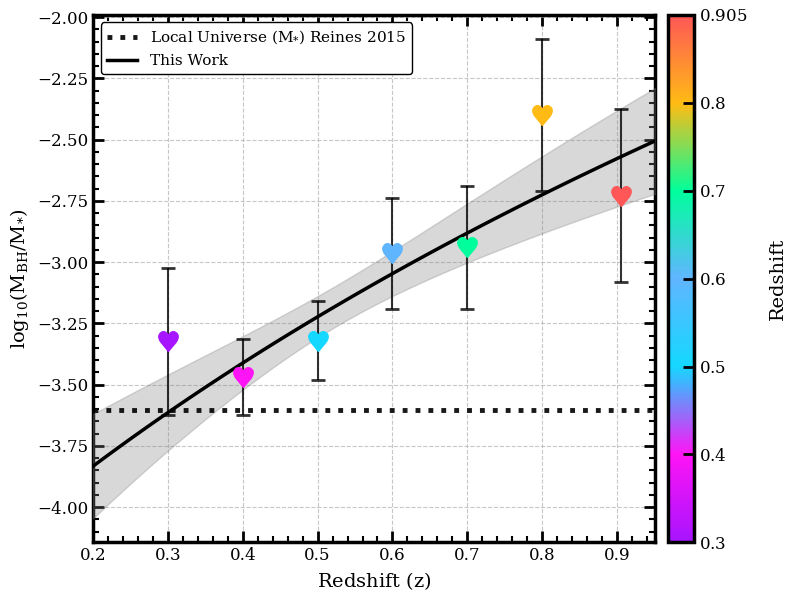

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.cm as cm

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with specified dimensions
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Dataset configuration for plotting (Black Hole Mass vs Luminosity)
datasets = [
    ('025_035', 
     0.3,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_SD_025_035),
    
    ('035_045',
     0.4,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_035_045),
    
    ('045_055', 
     0.5,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_045_055),
    
    ('055_065',
     0.6,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_055_065),
    
    ('065_075', 
     0.7,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_065_075),
    
    ('075_085', 
     0.8,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_075_085),
    
    ('085_096', 
     0.905,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_085_096)
]

# Extract data for fitting
x_data = np.array([dataset[1] for dataset in datasets])
y_data = np.array([dataset[2] for dataset in datasets])
y_errors = np.array([dataset[3] for dataset in datasets])

# Print data for debugging
print("X data (redshift):", x_data)
print("Y data (delta log M_BH/M_*):", y_data)
print("Y errors:", y_errors)

# Define power law function - your data should already be log(M_BH/M_*)
# We're fitting: log(M_BH/M_*) as a function of z
def power_law_fit(z, a, b):
    return a + b * np.log10(1 + z)

# Perform fitting to our data
try:
    initial_guess = [-2.5, 0.5]
    popt, pcov = curve_fit(
        power_law_fit, 
        x_data, 
        y_data, 
        sigma=y_errors, 
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=5000
    )
    
    a_fit = popt[0]
    b_fit = popt[1]
    a_fit_err = np.sqrt(np.diag(pcov))[0]
    b_fit_err = np.sqrt(np.diag(pcov))[1]
    fit_successful = True
    
    print(f"\nFit successful!")
    print(f"log(M_BH/M_*) = {a_fit:.3f} ± {a_fit_err:.3f} + ({b_fit:.3f} ± {b_fit_err:.3f}) * log10(1+z)")
    
except Exception as e:
    fit_successful = False
    print(f"Fit failed with error: {e}")

# Create redshift array for plotting trend lines
z_range = np.linspace(0.0, 1.0, 100)

# Define reference stellar mass (typical for these studies)
log_M_ref = 11.0  # 10^11 M_☉

## ===== MATT ET AL. 2025 RELATION =====
## M_BH = α(z) * (M_bulge/10^11 M_☉)^β_0
## α(z) = α_0 * (1+z)^α_z
## log α_0 = 8.69; β_0 = 1.17; α_z = 1.04 ± 0.5
#log_alpha_0 = 8.69
#beta_0 = 1.17
#alpha_z_matt = 1.04
#alpha_z_matt_err = 0.5
#
## For M_* = 10^11: log10(M_BH/M_*) = 8.69 + 1.04*log10(1+z) - 11
#matt_baseline = log_alpha_0 - log_M_ref
#matt_line = matt_baseline + alpha_z_matt * np.log10(1 + z_range)
#matt_upper = matt_baseline + (alpha_z_matt + alpha_z_matt_err) * np.log10(1 + z_range)
#matt_lower = matt_baseline + (alpha_z_matt - alpha_z_matt_err) * np.log10(1 + z_range)
#
#ax.plot(z_range, matt_line, linewidth=2, color="#0047AB", 
#        label=f"Matt et al. 2025", linestyle='-.', zorder=6)
#ax.fill_between(z_range, matt_lower, matt_upper, 
#                color="#8ABBFF", alpha=0.3, zorder=5)

# ===== MERLONI ET AL. 2010 REFERENCE LINE =====
# Merloni: evolution in M_BH/M_* ratio with redshift
#merloni_alpha_z = 0.68
#merloni_alpha_z_err = 0.12
## Baseline at z=0 (using typical local value)
#merloni_baseline = -2.5
#merloni_line = merloni_baseline + merloni_alpha_z * np.log10(1 + z_range)
#
#ax.plot(z_range, merloni_line, linewidth=2, linestyle="--", color="#5E386A", 
#        label=f"Merloni et al. 2010", zorder=7) 
#ax.fill_between(z_range, 
#                merloni_line - merloni_alpha_z_err, 
#                merloni_line + merloni_alpha_z_err, 
#                color="#F3C5FF", alpha=0.3, zorder=6)
#
# ===== LOCAL RELATION VALUE (z=0) =====
# Plot a vertical line at z=0 to mark the local universe
ax.axhline(y=np.log10(0.00025), linewidth=3.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000, label='Local Universe (M$_{*}$) Reines 2015')

#ax.axhline(y=np.log10(0.005), linewidth=2.5, linestyle='-', color='#ffbb14', 
#           alpha=0.4, zorder=1000, label='Local Universe (M$_{bulge}$) Kormendy & Ho 2013')

# ===== BEST FIT TO OUR DATA =====
if fit_successful:
    x_fit = np.linspace(0.2, 1.0, 100)
    y_fit = power_law_fit(x_fit, a_fit, b_fit)
    
    # Proper error propagation using covariance matrix
    # For y = a + b*log10(1+z), the uncertainty is:
    # σ_y^2 = σ_a^2 + [log10(1+z)]^2 * σ_b^2 + 2*log10(1+z)*cov(a,b)
    log_term = np.log10(1 + x_fit)
    y_fit_err = np.sqrt(a_fit_err**2 + (log_term**2) * (b_fit_err**2) + 
                        2 * log_term * pcov[0, 1])
    
    y_fit_upper = y_fit + y_fit_err
    y_fit_lower = y_fit - y_fit_err
    
    ax.plot(x_fit, y_fit, color='black', linewidth=2.5, 
            label=f'This Work', zorder=30)
    ax.fill_between(x_fit, y_fit_lower, y_fit_upper, 
                   color='gray', alpha=0.3, zorder=25)

# ===== PLOT DATA POINTS =====
for i, (key, x_data_point, y_data_point, y_err) in enumerate(datasets):
    # Plot data points with heart markers
    ax.scatter(x_data_point, y_data_point,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10000)

    # Plot error bars
    ax.errorbar(x_data_point, y_data_point,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=100)

# Configure axes labels and title
ax.set_xlabel(r"Redshift ($z$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{\rm BH}$/M$_{*}$)", fontsize=14, color="black")

# Create colorbar
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Create legend
legend1 = ax.legend(loc='upper left', fontsize=11, 
                   frameon=True, fancybox=True, 
                   edgecolor='black', facecolor='white', framealpha=1.0)

# Configure grid
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)

# Set minor ticks
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')

# Enable ticks on all sides
ax.tick_params(top=True, right=True)

# Set axis limits
ax.set_xlim(0.2, 0.95)
# Let y-axis auto-scale based on data and trend lines

# Adjust layout
plt.tight_layout(pad=0.5)

# Save figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Delta_BH_Stellar_Z.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the figure
plt.show(block=False)



In [28]:
print(np.log10(0.00025))
print(np.log10(0.00025))
print(np.log10(0.005))
print("")
print(BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035_a)
print(BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045_a)
print(BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055_a)
print(BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065_a)
print(BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075_a)
print(BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085_a)
print(BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096_a)
print("")
print(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035)

-3.6020599913279625
-3.6020599913279625
-2.3010299956639813

-3.323747788667255
-3.4681154545998774
-3.320356673385899
-2.964331628128677
-2.9398352985350535
-2.3990917053695586
-2.728306265759617

20009247.57426423


First data point stellar mass: 10.624978546444446
Non-normalized: α = -4.88 ± 0.21, β = 1.18 ± 0.02
Alpha8.767528010406444
Best Fit: α = 8.12 ± 0.01, β = 1.18 ± 0.02
Kormendy & Ho (2013): log₁₀(M_BH) = 8.69 + 1.16 × log₁₀(M_bulge/10¹¹ M_☉)
Matt et al. (2025): log₁₀(M_BH) = 8.69 + 1.17 × log₁₀(M_bulge/10¹¹ M_☉)


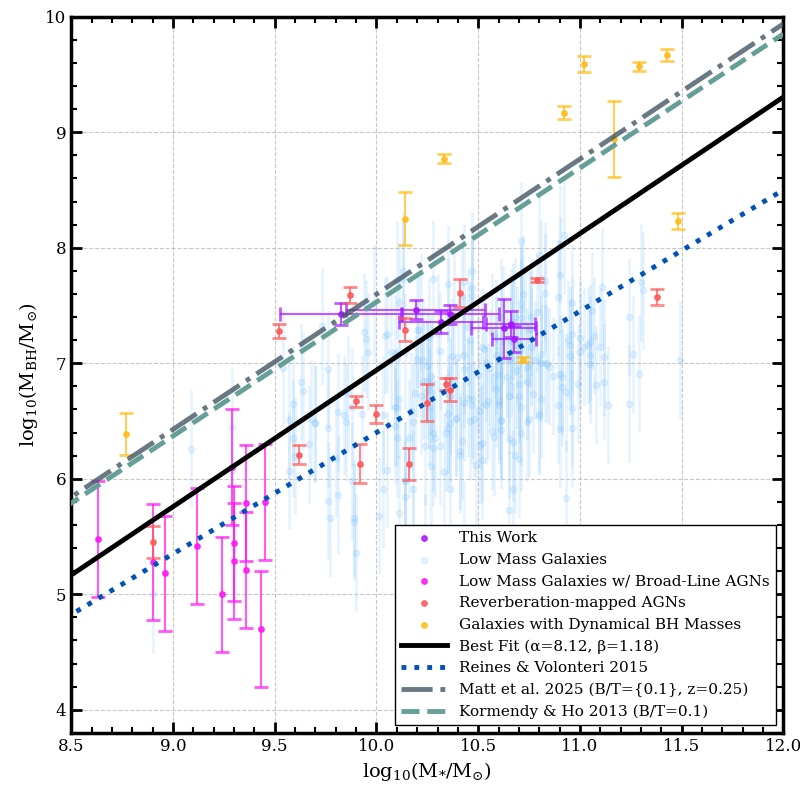

In [170]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy.optimize import curve_fit

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Galaxy data from the table
# Dwarf Galaxies with Broad-line AGNs
dwarfGalaxiesWithBroadlineAGNs = [
    {"name": "RGG 1", "logMs": 9.45, "logMBH": 5.80, "logMBH_uncertainty": 0.50},
    {"name": "RGG 9", "logMs": 9.30, "logMBH": 5.44, "logMBH_uncertainty": 0.50},
    {"name": "RGG 11", "logMs": 9.24, "logMBH": 5.00, "logMBH_uncertainty": 0.50},
    {"name": "RGG 20", "logMs": 9.29, "logMBH": 6.10, "logMBH_uncertainty": 0.50},
    {"name": "RGG 21", "logMs": 8.90, "logMBH": 5.28, "logMBH_uncertainty": 0.50},
    {"name": "RGG 32", "logMs": 9.30, "logMBH": 5.29, "logMBH_uncertainty": 0.50},
    {"name": "RGG 48", "logMs": 9.12, "logMBH": 5.42, "logMBH_uncertainty": 0.50},
    {"name": "RGG 118", "logMs": 9.43, "logMBH": 4.70, "logMBH_uncertainty": 0.50},
    {"name": "RGG 119", "logMs": 9.36, "logMBH": 5.79, "logMBH_uncertainty": 0.50},
    {"name": "RGG 123", "logMs": 8.96, "logMBH": 5.18, "logMBH_uncertainty": 0.50},
    {"name": "RGG 127", "logMs": 9.36, "logMBH": 5.21, "logMBH_uncertainty": 0.50},
    {"name": "Pox 52", "logMs": 8.63, "logMBH": 5.48, "logMBH_uncertainty": 0.50}
]

# Reverberation-mapped AGNs
reverberationMappedAGNs = [
    {"name": "Mrk 590", "logMs": 11.38, "logMBH": 7.57, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 79", "logMs": 10.41, "logMBH": 7.61, "logMBH_uncertainty": 0.12},
    {"name": "Mrk 110", "logMs": 10.14, "logMBH": 7.29, "logMBH_uncertainty": 0.10},
    {"name": "NGC 3227", "logMs": 10.36, "logMBH": 6.77, "logMBH_uncertainty": 0.10},
    {"name": "SBS1116+583A", "logMs": 10.00, "logMBH": 6.56, "logMBH_uncertainty": 0.08},
    {"name": "Arp151", "logMs": 9.90, "logMBH": 6.67, "logMBH_uncertainty": 0.05},
    {"name": "Mrk 1310", "logMs": 9.62, "logMBH": 6.21, "logMBH_uncertainty": 0.08},
    {"name": "NGC 4051", "logMs": 10.16, "logMBH": 6.13, "logMBH_uncertainty": 0.14},
    {"name": "Mrk 202", "logMs": 9.92, "logMBH": 6.13, "logMBH_uncertainty": 0.17},
    {"name": "NGC 4253", "logMs": 10.34, "logMBH": 6.82, "logMBH_uncertainty": 0.05},
    {"name": "NGC 4395", "logMs": 8.90, "logMBH": 5.45, "logMBH_uncertainty": 0.14},
    {"name": "NGC 5273", "logMs": 10.25, "logMBH": 6.66, "logMBH_uncertainty": 0.16},
    {"name": "NGC 5548", "logMs": 10.79, "logMBH": 7.72, "logMBH_uncertainty": 0.02},
    {"name": "Mrk 817", "logMs": 9.87, "logMBH": 7.59, "logMBH_uncertainty": 0.07},
    {"name": "Mrk 290", "logMs": 9.52, "logMBH": 7.28, "logMBH_uncertainty": 0.06}
]

# Galaxies with Dynamical BH Masses
galaxiesWithDynamicalBHMasses = [
    {"name": "M32", "logMs": 8.77, "logMBH": 6.39, "logMBH_uncertainty": 0.18},
    {"name": "NGC 1316", "logMs": 11.48, "logMBH": 8.23, "logMBH_uncertainty": 0.07},
    {"name": "NGC 1332", "logMs": 10.92, "logMBH": 9.17, "logMBH_uncertainty": 0.06},
    {"name": "NGC 1374", "logMs": 10.33, "logMBH": 8.77, "logMBH_uncertainty": 0.04},
    {"name": "NGC 1399", "logMs": 11.17, "logMBH": 8.94, "logMBH_uncertainty": 0.33}, 
    {"name": "NGC 1407", "logMs": 11.43, "logMBH": 9.67, "logMBH_uncertainty": 0.05}, 
    {"name": "NGC 1550", "logMs": 11.02, "logMBH": 9.59, "logMBH_uncertainty": 0.07}, 
    {"name": "NGC 2960", "logMs": 10.72, "logMBH": 7.03, "logMBH_uncertainty": 0.02}, 
    {"name": "NGC 3091", "logMs": 11.29, "logMBH": 9.57, "logMBH_uncertainty": 0.04}, 
    {"name": "NGC 3377", "logMs": 10.14, "logMBH": 8.25, "logMBH_uncertainty": 0.23}, 
]

# Galaxies from Reines 2013 https://iopscience.iop.org/article/10.1088/0004-637X/813/2/82
galaxiesWithAGNBHMasses_Reines = [
    {"name": "SDSS J000907.90+142755.8", "logMs": 10.68, "logMBH": 6.21, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J004236.86-104922.0", "logMs": 10.43, "logMBH": 7.07, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J012159.81-010224.3", "logMs": 10.47, "logMBH": 7.65, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J021011.49-090335.5", "logMs": 10.92, "logMBH": 8.11, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J024912.86-081525.7", "logMs": 10.11, "logMBH": 5.70, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J030417.77+002827.2", "logMs": 10.61, "logMBH": 6.50, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J032006.32+402158.6", "logMs": 10.36, "logMBH": 6.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J040929.15-042902.7", "logMs": 9.64, "logMBH": 6.76, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J073106.44+392639.9", "logMs": 10.58, "logMBH": 6.36, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075151.87+494851.9", "logMs": 10.61, "logMBH": 6.51, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075243.60+455655.9", "logMs": 11.49, "logMBH": 7.03, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075525.28+391109.8", "logMs": 10.19, "logMBH": 6.74, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075643.72+445124.1", "logMs": 10.70, "logMBH": 6.82, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075850.28+093520.7", "logMs": 10.96, "logMBH": 7.25, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J075941.30+505022.9", "logMs": 10.31, "logMBH": 7.11, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080020.98+263648.8", "logMs": 11.05, "logMBH": 6.99, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080243.40+310403.3", "logMs": 10.47, "logMBH": 7.80, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080538.89+261003.0", "logMs": 10.51, "logMBH": 6.59, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080545.71+073526.2", "logMs": 11.30, "logMBH": 7.70, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080707.17+361400.5", "logMs": 10.93, "logMBH": 5.83, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080801.75+381935.3", "logMs": 10.09, "logMBH": 6.46, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J080910.72+110619.1", "logMs": 10.05, "logMBH": 6.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J081319.32+460849.6", "logMs": 10.81, "logMBH": 7.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J081516.87+460430.8", "logMs": 10.93, "logMBH": 6.75, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J081718.55+520148.1", "logMs": 9.70, "logMBH": 6.48, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J081726.41+101210.1", "logMs": 10.35, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082442.80+295920.9", "logMs": 9.77, "logMBH": 5.66, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082510.23+375919.7", "logMs": 10.31, "logMBH": 6.28, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082620.81+055727.8", "logMs": 10.64, "logMBH": 6.88, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082818.67+573912.9", "logMs": 11.11, "logMBH": 7.66, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082842.73+454433.2", "logMs": 10.40, "logMBH": 7.05, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J082912.66+500652.6", "logMs": 9.09, "logMBH": 6.26, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J083732.60+284221.9", "logMs": 10.77, "logMBH": 6.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J083810.94+245342.9", "logMs": 11.12, "logMBH": 6.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J084137.86+545506.8", "logMs": 10.84, "logMBH": 6.99, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J084143.50+013149.8", "logMs": 11.29, "logMBH": 6.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J084654.09+252212.3", "logMs": 10.13, "logMBH": 7.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J090613.75+561015.5", "logMs": 9.30, "logMBH": 5.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J090902.35+133019.4", "logMs": 10.69, "logMBH": 7.16, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091101.33+571247.1", "logMs": 10.54, "logMBH": 7.01, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091102.32+550023.3", "logMs": 10.14, "logMBH": 5.98, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091256.44+380538.0", "logMs": 9.95, "logMBH": 7.21, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091424.75+115625.5", "logMs": 10.01, "logMBH": 5.68, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091520.48+411918.8", "logMs": 10.52, "logMBH": 7.14, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091634.32+175508.3", "logMs": 10.68, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J091913.18+552755.2", "logMs": 9.76, "logMBH": 6.95, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092115.56+101741.0", "logMs": 10.67, "logMBH": 7.36, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092438.89+560743.0", "logMs": 10.80, "logMBH": 6.56, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092528.24+233631.0", "logMs": 11.00, "logMBH": 7.10, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092603.26+124403.7", "logMs": 10.26, "logMBH": 7.23, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J092740.77+262701.1", "logMs": 10.52, "logMBH": 6.31, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J093206.90+172703.2", "logMs": 9.88, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J093327.87+093200.0", "logMs": 10.37, "logMBH": 7.06, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J093408.59+175644.0", "logMs": 9.76, "logMBH": 5.81, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J093410.88+305657.9", "logMs": 10.75, "logMBH": 7.29, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094204.79+234106.9", "logMs": 10.14, "logMBH": 7.10, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094328.71+524811.7", "logMs": 10.65, "logMBH": 6.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094529.36+093610.4", "logMs": 9.59, "logMBH": 6.35, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094838.42+403043.7", "logMs": 10.66, "logMBH": 7.32, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094839.73+363649.3", "logMs": 10.60, "logMBH": 6.67, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J094852.56+285338.4", "logMs": 10.83, "logMBH": 7.00, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095220.09+322826.8", "logMs": 10.57, "logMBH": 6.41, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095437.22+063719.5", "logMs": 10.90, "logMBH": 7.76, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095540.47+050236.5", "logMs": 10.67, "logMBH": 5.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095745.49+152350.6", "logMs": 10.35, "logMBH": 6.56, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095800.22+154722.0", "logMs": 10.71, "logMBH": 6.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J095956.09+130235.9", "logMs": 10.61, "logMBH": 7.04, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100207.03+030327.6", "logMs": 10.59, "logMBH": 7.22, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100218.78+264805.7", "logMs": 10.96, "logMBH": 7.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100510.50+543255.7", "logMs": 10.24, "logMBH": 5.36, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100819.11+372903.4", "logMs": 11.24, "logMBH": 6.65, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J100854.93+373929.9", "logMs": 10.20, "logMBH": 7.04, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J101202.59+301303.0", "logMs": 10.20, "logMBH": 7.29, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J101718.70+291432.0", "logMs": 10.25, "logMBH": 6.98, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J101846.01+345007.9", "logMs": 10.24, "logMBH": 6.28, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J101913.90+635759.0", "logMs": 10.47, "logMBH": 7.58, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J102306.97+125100.3", "logMs": 10.34, "logMBH": 6.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J102402.40+062942.0", "logMs": 10.11, "logMBH": 6.69, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J102532.09+102503.9", "logMs": 10.89, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J102841.98+490418.6", "logMs": 10.91, "logMBH": 6.88, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J103234.30+650224.9", "logMs": 9.89, "logMBH": 5.63, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J103438.59+393828.2", "logMs": 10.22, "logMBH": 6.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J103751.81+334850.1", "logMs": 10.90, "logMBH": 6.43, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104120.48+314039.1", "logMs": 10.27, "logMBH": 6.89, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104252.93+041441.1", "logMs": 10.21, "logMBH": 7.29, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104438.89+384527.9", "logMs": 11.08, "logMBH": 6.81, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104451.72+063548.6", "logMs": 10.96, "logMBH": 6.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J104504.23+114508.7", "logMs": 10.17, "logMBH": 6.59, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J105415.52+174522.5", "logMs": 10.69, "logMBH": 6.94, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J105427.88+330943.4", "logMs": 10.18, "logMBH": 6.49, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J105658.52+441653.1", "logMs": 10.11, "logMBH": 7.53, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110016.03+461615.3", "logMs": 9.76, "logMBH": 6.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110032.29+020656.0", "logMs": 11.26, "logMBH": 7.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110158.30+101740.9", "logMs": 9.73, "logMBH": 7.32, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110422.05+321404.5", "logMs": 9.86, "logMBH": 6.74, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110807.47+270602.7", "logMs": 10.33, "logMBH": 6.06, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J110929.00+284132.9", "logMs": 10.18, "logMBH": 5.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111045.96+113641.5", "logMs": 11.05, "logMBH": 7.18, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111227.30+184926.8", "logMs": 10.38, "logMBH": 7.49, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111349.74+093510.7", "logMs": 10.66, "logMBH": 7.19, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111752.64+291816.1", "logMs": 10.23, "logMBH": 6.85, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J111857.69+580323.9", "logMs": 9.96, "logMBH": 7.10, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112423.88+274245.3", "logMs": 10.48, "logMBH": 6.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112536.89+542256.0", "logMs": 9.94, "logMBH": 7.27, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112545.34+240823.9", "logMs": 10.36, "logMBH": 5.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112628.71+472453.8", "logMs": 10.16, "logMBH": 6.35, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112637.74+513423.2", "logMs": 10.14, "logMBH": 5.99, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112842.51+195313.2", "logMs": 10.39, "logMBH": 6.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J112942.76+555913.1", "logMs": 10.42, "logMBH": 6.33, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J113240.25+525701.6", "logMs": 10.36, "logMBH": 6.48, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J113249.27+101747.2", "logMs": 11.31, "logMBH": 7.63, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J113549.07+565708.4", "logMs": 11.14, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114013.94+244149.4", "logMs": 10.81, "logMBH": 7.00, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114054.08+230744.3", "logMs": 10.05, "logMBH": 7.25, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114430.09+365259.9", "logMs": 10.90, "logMBH": 8.03, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114433.05+613201.0", "logMs": 11.10, "logMBH": 7.14, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114444.89+331915.4", "logMs": 10.65, "logMBH": 5.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114530.30+094352.0", "logMs": 10.47, "logMBH": 6.69, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114545.18+554759.9", "logMs": 11.04, "logMBH": 7.16, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J114740.08+334720.4", "logMs": 10.74, "logMBH": 6.49, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J115138.10+561332.1", "logMs": 9.80, "logMBH": 6.18, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J115710.68+221746.2", "logMs": 10.76, "logMBH": 7.30, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120114.35-034041.1", "logMs": 9.54, "logMBH": 6.96, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120144.91+201941.9", "logMs": 10.70, "logMBH": 6.17, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120208.36+174124.8", "logMs": 10.18, "logMBH": 5.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120257.81+045045.0", "logMs": 10.71, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120429.79+201901.0", "logMs": 10.81, "logMBH": 6.69, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120440.50+311100.0", "logMs": 10.95, "logMBH": 7.16, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120626.27+424426.0", "logMs": 10.62, "logMBH": 7.33, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120727.97+253610.9", "logMs": 10.47, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J120929.16+330530.1", "logMs": 10.10, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121044.27+382010.2", "logMs": 10.43, "logMBH": 7.70, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121607.08+504930.4", "logMs": 10.71, "logMBH": 8.06, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121826.72-000750.1", "logMs": 9.93, "logMBH": 6.56, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121905.27+210632.6", "logMs": 11.05, "logMBH": 7.07, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J121923.73+303002.7", "logMs": 9.90, "logMBH": 5.36, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J122215.37+282123.7", "logMs": 9.63, "logMBH": 6.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J122342.82+581446.4", "logMs": 9.29, "logMBH": 6.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J122548.86+333248.7", "logMs": 8.90, "logMBH": 5.00, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123237.48+662452.5", "logMs": 10.61, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123454.70+153410.9", "logMs": 10.74, "logMBH": 6.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123650.90+453902.9", "logMs": 10.54, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123741.18+264227.5", "logMs": 9.81, "logMBH": 5.86, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J123838.10+453414.4", "logMs": 10.80, "logMBH": 6.54, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J124145.71+320256.2", "logMs": 10.09, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J124345.79+193846.4", "logMs": 10.10, "logMBH": 6.35, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J124610.76+275615.9", "logMs": 10.23, "logMBH": 7.03, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J125042.20-024928.9", "logMs": 10.71, "logMBH": 7.39, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J125400.20+424220.0", "logMs": 10.90, "logMBH": 6.91, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J125552.36+103055.2", "logMs": 10.61, "logMBH": 7.19, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J125710.75+272417.6", "logMs": 10.27, "logMBH": 6.11, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130019.94+613918.4", "logMs": 10.72, "logMBH": 7.60, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130342.82+324824.5", "logMs": 9.57, "logMBH": 6.07, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130615.16+585733.4", "logMs": 9.59, "logMBH": 6.65, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130721.92+095209.3", "logMs": 10.79, "logMBH": 7.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J130803.88+505227.0", "logMs": 10.28, "logMBH": 6.27, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J131305.81+012755.9", "logMs": 10.35, "logMBH": 6.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J131310.12+051942.1", "logMs": 9.89, "logMBH": 5.66, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J131905.95+310852.7", "logMs": 10.55, "logMBH": 6.67, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J132255.43+080941.5", "logMs": 10.64, "logMBH": 7.04, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J132507.32+082026.4", "logMs": 10.65, "logMBH": 6.34, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J132731.12+244641.0", "logMs": 10.83, "logMBH": 7.71, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J132908.83+295024.1", "logMs": 9.81, "logMBH": 6.58, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J133739.87+390916.4", "logMs": 10.45, "logMBH": 6.70, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134208.38+353915.5", "logMs": 10.26, "logMBH": 6.77, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134300.79+360956.3", "logMs": 9.68, "logMBH": 6.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134426.41+441620.0", "logMs": 10.27, "logMBH": 6.82, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134632.13+642325.2", "logMs": 9.67, "logMBH": 6.30, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134704.35+110622.6", "logMs": 10.75, "logMBH": 6.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134812.56+072340.7", "logMs": 10.52, "logMBH": 6.16, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J134952.60+020440.0", "logMs": 10.22, "logMBH": 7.44, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J135317.78+332927.0", "logMs": 10.43, "logMBH": 5.47, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J140018.41+050242.2", "logMs": 10.73, "logMBH": 7.33, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J140514.86-025901.2", "logMs": 10.67, "logMBH": 7.21, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J141415.17+264451.4", "logMs": 10.57, "logMBH": 7.27, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J141630.82+013708.0", "logMs": 11.00, "logMBH": 7.22, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J141759.54+250812.7", "logMs": 10.80, "logMBH": 7.94, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J141920.64+043623.3", "logMs": 10.96, "logMBH": 6.61, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J142138.63+173536.2", "logMs": 10.42, "logMBH": 7.58, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J142408.38+210518.5", "logMs": 10.78, "logMBH": 7.03, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J142817.98+571018.6", "logMs": 10.59, "logMBH": 6.90, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J143450.63+033842.5", "logMs": 10.14, "logMBH": 5.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J143452.46+483942.7", "logMs": 10.10, "logMBH": 7.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J144431.62+153643.2", "logMs": 10.53, "logMBH": 7.12, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145037.85+224403.6", "logMs": 9.84, "logMBH": 6.55, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145055.43+273442.7", "logMs": 10.91, "logMBH": 6.79, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145314.29+170037.9", "logMs": 10.60, "logMBH": 6.64, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145518.40+163253.7", "logMs": 10.49, "logMBH": 6.12, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145631.35+212030.0", "logMs": 10.03, "logMBH": 6.55, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J145819.55+045451.7", "logMs": 10.09, "logMBH": 7.08, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J150138.79+102513.4", "logMs": 10.59, "logMBH": 7.07, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J150311.67+111027.3", "logMs": 10.25, "logMBH": 6.85, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J150744.40+512703.0", "logMs": 11.24, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J150853.94-001149.0", "logMs": 11.06, "logMBH": 7.45, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151150.03+075918.7", "logMs": 10.37, "logMBH": 6.84, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151343.31+042143.6", "logMs": 10.56, "logMBH": 6.96, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151621.58+080604.6", "logMs": 10.41, "logMBH": 6.24, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151634.45+205837.9", "logMs": 9.88, "logMBH": 5.98, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J151907.55+260750.6", "logMs": 10.39, "logMBH": 6.53, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J152324.43+551855.5", "logMs": 10.70, "logMBH": 6.72, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J152416.66+045119.0", "logMs": 10.46, "logMBH": 7.20, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J152940.58+302909.3", "logMs": 10.74, "logMBH": 6.97, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J153118.01+072740.3", "logMs": 10.83, "logMBH": 7.61, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J153146.89+062257.9", "logMs": 10.71, "logMBH": 7.47, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J153552.50+143103.8", "logMs": 10.29, "logMBH": 6.35, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J154214.26+095654.7", "logMs": 9.57, "logMBH": 6.51, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J154241.59+225251.0", "logMs": 11.07, "logMBH": 7.24, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J154507.69+170955.0", "logMs": 10.35, "logMBH": 7.69, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J154814.75+450027.7", "logMs": 9.70, "logMBH": 6.48, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155224.87+041726.2", "logMs": 9.29, "logMBH": 6.45, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155417.43+323837.9", "logMs": 10.28, "logMBH": 7.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155640.90+121717.9", "logMs": 10.43, "logMBH": 6.66, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155807.97+120413.0", "logMs": 10.41, "logMBH": 6.21, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J155926.11+521235.5", "logMs": 10.45, "logMBH": 7.31, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160502.46+330545.0", "logMs": 10.13, "logMBH": 7.80, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160515.85+174227.4", "logMs": 10.46, "logMBH": 6.50, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160558.11+440319.5", "logMs": 10.87, "logMBH": 6.89, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160652.16+275539.1", "logMs": 10.95, "logMBH": 7.06, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J160836.37+121951.5", "logMs": 10.71, "logMBH": 7.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161156.31+521117.1", "logMs": 10.30, "logMBH": 7.26, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161745.63+060353.5", "logMs": 9.99, "logMBH": 7.52, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161809.60+362002.0", "logMs": 9.60, "logMBH": 6.20, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161844.85+253907.6", "logMs": 10.94, "logMBH": 7.20, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J161951.31+405847.3", "logMs": 10.59, "logMBH": 6.78, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J162138.10+351617.3", "logMs": 10.50, "logMBH": 6.90, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J162345.88+410456.4", "logMs": 10.07, "logMBH": 7.10, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J162501.43+241547.3", "logMs": 10.43, "logMBH": 6.95, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J163007.39-001136.4", "logMs": 10.76, "logMBH": 7.14, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J163257.50+115040.1", "logMs": 10.28, "logMBH": 6.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J163453.66+231242.6", "logMs": 10.76, "logMBH": 7.40, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J165601.60+211241.1", "logMs": 10.81, "logMBH": 7.73, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J170938.94+630635.0", "logMs": 10.04, "logMBH": 7.24, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J171228.44+355302.6", "logMs": 10.85, "logMBH": 6.97, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J172239.93+305252.6", "logMs": 11.02, "logMBH": 7.14, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J204745.25-052515.6", "logMs": 10.66, "logMBH": 7.04, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J210533.44+002829.2", "logMs": 9.85, "logMBH": 6.49, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J212954.56+101603.8", "logMs": 10.61, "logMBH": 6.42, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J213344.25-081615.6", "logMs": 10.89, "logMBH": 7.57, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J213741.44+005317.0", "logMs": 10.99, "logMBH": 6.82, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J215226.03-081024.9", "logMs": 10.67, "logMBH": 6.32, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J215512.41+005906.7", "logMs": 10.51, "logMBH": 6.29, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J224824.63+000920.6", "logMs": 10.26, "logMBH": 6.62, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J231815.67+001540.2", "logMs": 11.12, "logMBH": 7.05, "logMBH_uncertainty": 0.5},
    {"name": "SDSS J233837.09-002810.4", "logMs": 10.03, "logMBH": 5.91, "logMBH_uncertainty": 0.5},
];


# Your variables are already defined in your environment - using them directly
# No need to redefine them here

OurData = [
    {"name": "025_035", "logMs": Stellar_Mass_Median_025_035, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035), "logMs_uncertainty": Stellar_Mass_SD_025_035, "logMBH_uncertainty": BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035*np.log(10))},
    {"name": "035_045", "logMs": Stellar_Mass_Median_035_045, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045), "logMs_uncertainty": Stellar_Mass_SD_035_045, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045*np.log(10))},
    {"name": "045_055", "logMs": Stellar_Mass_Median_045_055, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055), "logMs_uncertainty": Stellar_Mass_SD_045_055, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055*np.log(10))},
    {"name": "055_065", "logMs": Stellar_Mass_Median_055_065, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065), "logMs_uncertainty": Stellar_Mass_SD_055_065, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065*np.log(10))},
    {"name": "065_075", "logMs": Stellar_Mass_Median_065_075, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075), "logMs_uncertainty": Stellar_Mass_SD_065_075, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075*np.log(10))},
    {"name": "075_085", "logMs": Stellar_Mass_Median_075_085, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085), "logMs_uncertainty": Stellar_Mass_SD_075_085, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085*np.log(10))},
    {"name": "085_096", "logMs": Stellar_Mass_Median_085_096, "logMBH": np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096), "logMs_uncertainty": Stellar_Mass_SD_085_096, "logMBH_uncertainty":BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096*np.log(10))}
]

print(f"First data point stellar mass: {Stellar_Mass_Median_025_035}")

# Create single panel figure
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='white')


# Color scheme
dataset_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"] #Purple, Pink, Teal, Blue, Green, Orange, Red 
heart_color = "#a714ff"

# Extract data for plotting
ourdata_x = [galaxy["logMs"] for galaxy in OurData]
ourdata_y = [galaxy["logMBH"] for galaxy in OurData]
ourdata_x_err = [galaxy["logMs_uncertainty"] for galaxy in OurData]
ourdata_y_err = [galaxy["logMBH_uncertainty"] for galaxy in OurData]

dwarf_x = [galaxy["logMs"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y = [galaxy["logMBH"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]
dwarf_y_err = [galaxy["logMBH_uncertainty"] for galaxy in dwarfGalaxiesWithBroadlineAGNs]

reverberation_x = [galaxy["logMs"] for galaxy in reverberationMappedAGNs]
reverberation_y = [galaxy["logMBH"] for galaxy in reverberationMappedAGNs]
reverberation_y_err = [galaxy["logMBH_uncertainty"] for galaxy in reverberationMappedAGNs]

dynamical_x = [galaxy["logMs"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y = [galaxy["logMBH"] for galaxy in galaxiesWithDynamicalBHMasses]
dynamical_y_err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithDynamicalBHMasses]

reines_x = [galaxy["logMs"] for galaxy in galaxiesWithAGNBHMasses_Reines]
reines_y = [galaxy["logMBH"] for galaxy in galaxiesWithAGNBHMasses_Reines]
reines_y_err = [galaxy["logMBH_uncertainty"] for galaxy in galaxiesWithAGNBHMasses_Reines]

# Create weights that balance dataset contributions
n_datasets = 5
n_reines = len(reines_x)
n_other = len(dwarf_x) + len(reverberation_x) + len(ourdata_x) + len(dynamical_x)

# Weight each Reines point less to balance with other datasets
reines_weight_factor = n_other / (n_datasets * n_reines)
reines_y_err_adjusted = [err / np.sqrt(reines_weight_factor) for err in reines_y_err]

all_x = dwarf_x + reverberation_x + ourdata_x + reines_x + dynamical_x
all_y = dwarf_y + reverberation_y + ourdata_y + reines_y + dynamical_y
all_y_err = dwarf_y_err + reverberation_y_err + ourdata_y_err + reines_y_err_adjusted + dynamical_y_err
all_x = np.array(all_x)
all_y = np.array(all_y)
all_y_err = np.array(all_y_err)

# Define power law functions
def power_law_10_11(x, alpha, beta):
    return alpha + beta * (x - 11.0)

def power_law(x, alpha, beta):
    """Power law: log(M_BH) = alpha + beta * (log(M_star) - 11)"""
    return alpha + beta * (x - 11)

# Perform fitting with error weights
try:
    # Assuming you have all_y_err as your error array
    popt, pcov = curve_fit(power_law, all_x, all_y, sigma=all_y_err, absolute_sigma=True)
    alpha_fit, beta_fit = popt
    alpha_err, beta_err = np.sqrt(np.diag(pcov))
    fit_successful = True
except:
    fit_successful = False

# Add this function after your existing power_law function
def power_law_non_normalized(x, alpha, beta):
    """Non-normalized power law: log(M_BH) = alpha + beta * log(M_star)"""
    return alpha + beta * x

# Add this after your existing curve_fit call
try:
    popt_non_norm, pcov_non_norm = curve_fit(power_law_non_normalized, all_x, all_y, sigma=all_y_err, absolute_sigma=True)
    alpha_fit_non_norm, beta_fit_non_norm = popt_non_norm
    alpha_err_non_norm, beta_err_non_norm = np.sqrt(np.diag(pcov_non_norm))
except:
    alpha_fit_non_norm, beta_fit_non_norm = None, None

# Add this print line wherever you want the output
print(f"Non-normalized: α = {alpha_fit_non_norm:.2f} ± {alpha_err_non_norm:.2f}, β = {beta_fit_non_norm:.2f} ± {beta_err_non_norm:.2f}")
# Create x values for lines
x_fit = np.linspace(8.0, 12.0, 100)

# Reference line parameters
alpha_ref_Reines = 7.45
beta_ref_Reines = 1.05

# Kormendy & Ho (2013) parameters
alpha_ref_KormenlyHo = 8.69
beta_ref_KormenlyHo = 1.16

# Matt et al. 2025 parameters
alpha0_matt = 8.69
beta0_matt = 1.17
alpha_z_matt = 1.04
alpha_z_err_matt = 0.5

# Define Matt et al. 2025 relation
def matt_relation_stellar(log_m_star, bulge_fraction=0.1):
    """
    Convert Matt et al. 2025 relation to stellar mass basis
    Assumes M_bulge = bulge_fraction * M_star
    """
    # Convert stellar mass to bulge mass
    log_m_bulge = np.log10(bulge_fraction) + log_m_star
    
    # Apply Matt et al. relation: log(M_BH) = alpha0 + beta0 * log(M_bulge/10^11)
    log_m_bh = alpha0_matt + beta0_matt * (log_m_bulge - 11.0)
    
    return log_m_bh

# Plot all data points
ax.scatter(ourdata_x, ourdata_y,
          color=heart_color, s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='This Work')
ax.errorbar(ourdata_x, ourdata_y,
           yerr=ourdata_y_err, xerr=ourdata_x_err,
           linestyle='', ecolor=heart_color,
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot galaxies from Reines 2013
ax.scatter(reines_x, reines_y,
          color="#60B5FF", s=80, marker='.', alpha=0.15, zorder=0,
          label='Low Mass Galaxies') # Reines et al. 2013')
ax.errorbar(reines_x, reines_y,
           yerr=reines_y_err, linestyle='', ecolor="#60B5FF",
           capsize=1, capthick=1, alpha=0.15, zorder=0)

# Plot dwarf galaxies
ax.scatter(dwarf_x, dwarf_y,
          color="#ff14f5", s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Low Mass Galaxies w/ Broad-Line AGNs')
ax.errorbar(dwarf_x, dwarf_y,
           yerr=dwarf_y_err, linestyle='', ecolor="#ff14f5",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot reverberation-mapped AGNs
ax.scatter(reverberation_x, reverberation_y,
          color="#FF5757", s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Reverberation-mapped AGNs')
ax.errorbar(reverberation_x, reverberation_y,
           yerr=reverberation_y_err, linestyle='', ecolor="#FF5757",
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)

# Plot galaxies with dynamical BH masses
ax.scatter(dynamical_x, dynamical_y,
          color=dataset_colors[5], s=15, marker='o', alpha=0.85, linewidth=1, zorder=20,
          label='Galaxies with Dynamical BH Masses')
ax.errorbar(dynamical_x, dynamical_y,
           yerr=dynamical_y_err, linestyle='', ecolor=dataset_colors[5],
           capsize=5, capthick=2, elinewidth=1.5, alpha=0.7, zorder=19)


# Plot best fit line in black
if fit_successful:
    y_fit = power_law(x_fit, alpha_fit, beta_fit)
    ax.plot(x_fit, y_fit, color='black', linewidth=3.5, zorder=30,
            label=f'Best Fit (α={alpha_fit:.2f}, β={beta_fit:.2f})')

# Plot Reines line in navy
y_ref_Reines = power_law_10_11(x_fit, alpha_ref_Reines, beta_ref_Reines)
ax.plot(x_fit, y_ref_Reines, color='#0052b6', linewidth=3.5, linestyle=":", 
         label='Reines & Volonteri 2015', zorder=29)


# Add Matt et al. 2025 relation at z=0.25
matt_bulge_fraction = 1.0  # For stellar mass
alpha_z = 0.8  # From the paper
z = 0.25

# Evolve the normalization with redshift
alpha_evolved = np.log10((10**alpha0_matt) * (1 + z)**alpha_z)
log_m_bulge = np.log10(matt_bulge_fraction) + x_fit
y_matt = alpha_evolved + beta0_matt * (log_m_bulge - 11.0)
print(f"Alpha" +str(alpha_evolved))
ax.plot(x_fit, y_matt, color="#435663", linewidth=3.5, 
        linestyle='-.', alpha=0.8,
        label='Matt et al. 2025 (B/T={0.1}, z=0.25)', zorder=28)


# Add Kormendy & Ho line
bulge_fractions = [0.10]
kormendy_colors = ['#669e98']
kormendy_linestyles = ['--']

for i, bf in enumerate(bulge_fractions):
    y_ref_KormendyHo_scaled = alpha_ref_KormenlyHo + beta_ref_KormenlyHo * (np.log10(1.0) + x_fit - 11)
    ax.plot(x_fit, y_ref_KormendyHo_scaled, 
             color=kormendy_colors[i], linewidth=3.5,
             linestyle=kormendy_linestyles[i], 
             label=f'Kormendy & Ho 2013 (B/T={bf})', 
             zorder=28 - i)

# Configure the plot
ax.set_xlabel(r"log$_{10}$(M$_{*}$/M$_{\odot}$)", fontsize=14, color="black")
ax.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")
ax.grid(visible=True, which='major', axis='both', 
        linestyle='--', alpha=0.7, zorder=-10)
ax.minorticks_on()

# Configure spine thickness
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

# Configure tick parameters
ax.tick_params(axis='both', which='major', labelsize=12,
               length=8, width=2.0, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=10,
               length=4, width=1.5, direction='in')
ax.tick_params(top=True, right=True)
ax.set_ylim(3.0, 10.5)

# Create legend
legend = ax.legend(loc='lower right', fontsize=11, 
                  frameon=True, fancybox=False, 
                  edgecolor='black', facecolor='white', framealpha=1.0, 
                  ncol=1, columnspacing=0.9, handlelength=3, borderpad=0.4)

# Adjust layout
plt.tight_layout(pad=1.0)

# Print fit results
if fit_successful:
    print(f"Best Fit: α = {alpha_fit:.2f} ± {alpha_err:.2f}, β = {beta_fit:.2f} ± {beta_err:.2f}")
else:
    print("Fit failed")

print(f"Kormendy & Ho (2013): log₁₀(M_BH) = {alpha_ref_KormenlyHo} + {beta_ref_KormenlyHo} × log₁₀(M_bulge/10¹¹ M_☉)")
print(f"Matt et al. (2025): log₁₀(M_BH) = {alpha0_matt} + {beta0_matt} × log₁₀(M_bulge/10¹¹ M_☉)")

ax.set_xlim(8.5, 12.0)
ax.set_ylim(3.8, 10)

fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_Trends.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show(block=False)






In [152]:
np.log10((10**9 * 0.49))


8.690196080028514

In [30]:
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085))
print(np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096))



7.301230757777191
7.208561707376564
7.339803527064951
7.354623711351332
7.4237206207486555
7.425408970320342
7.464722777207282


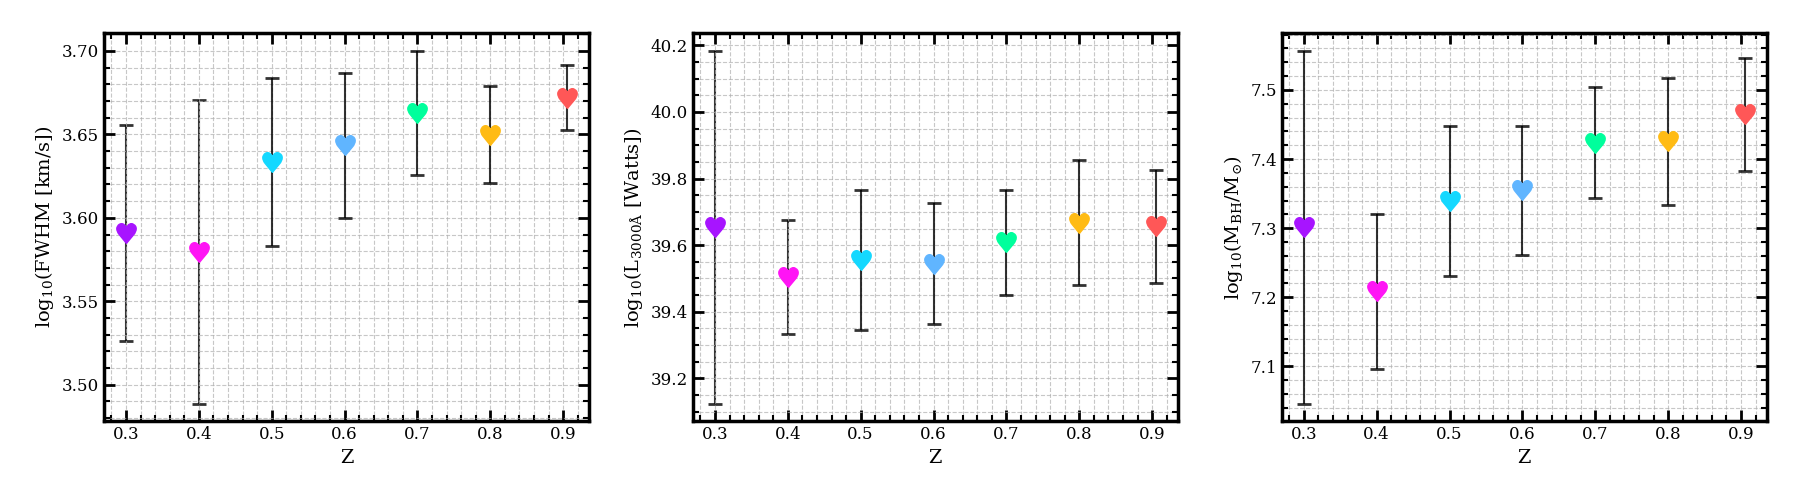

In [148]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.cm as cm

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Create figure with three subplots in a single row
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# Color scheme (organized in dictionary)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Labels for legend (formatted for better readability)
labels = [
    r'$0.25 < z < 0.35$',
    r'$0.35 < z < 0.45$',
    r'$0.45 < z < 0.55$',
    r'$0.55 < z < 0.65$',
    r'$0.65 < z < 0.75$',
    r'$0.75 < z < 0.85$',
    r'$0.85 < z < 0.96$'
]


# =============================================================================
# PANEL 1: FWHM vs Redshift (AXES SWAPPED: Redshift on x-axis, FWHM on y-axis)
# =============================================================================

# Dataset configuration for Panel 3 (axes swapped)
datasets_panel3 = [
    ('025_035', 0.3, np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035 * np.log10(10))),
    ('035_045', 0.4, np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045 * np.log10(10))),
    ('045_055', 0.5, np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055 * np.log10(10))),
    ('055_065', 0.6, np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065 * np.log10(10))),
    ('065_075', 0.7, np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075 * np.log10(10))),
    ('075_085', 0.8, np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085 * np.log10(10))),
    ('085_096', 0.905, np.log10(MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096),
     MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096 / (MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096 * np.log10(10)))
]

# Plot Panel 3 with swapped axes
for i, (key, x_data, y_data, y_err) in enumerate(datasets_panel3):
    ax1.scatter(x_data, y_data,
                color=colors[key],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i,
                label=labels[i])
    
    ax1.errorbar(x_data, y_data,
                 xerr=None,
                 yerr=y_err,
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

ax1.set_xlabel(r"Z", fontsize=14, color="black")
ax1.set_ylabel(r"log$_{10}$(FWHM [km/s])", fontsize=14, color="black")

# Extend the upper y-limit slightly for Panel 3
ymin1, ymax1 = ax1.get_ylim()
#ax3.set_ylim(ymin3, ymax3 * 1.05)

# =============================================================================
# PANEL 2: Luminosity Evolution (Z vs log10(Luminosity))
# =============================================================================

# Dataset configuration for Panel 1
datasets_panel1 = [
    ('025_035', 
     0.3,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_025_035 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 * np.log(10))),
    ('035_045', 
     0.4,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_035_045 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 * np.log(10))),
    ('045_055', 
     0.5,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_045_055 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 * np.log(10))),
    ('055_065', 
     0.6,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_055_065 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 * np.log(10))),
    ('065_075', 
     0.7,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_065_075 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 * np.log(10))),
    ('075_085', 
     0.8,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_075_085 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 * np.log(10))),
    ('085_096', 
     0.905,
     np.log10(Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
     Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_Err_median_085_096 / (Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 * np.log(10)))
]

# Plot Panel 1
for i, (key, x_data, y_data, y_err) in enumerate(datasets_panel1):
    ax2.scatter(x_data, y_data,
                color=colors[key],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10+i,
                label=labels[i])
    
    ax2.errorbar(x_data, y_data,
                 xerr=None,
                 yerr=y_err,
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=i)

ax2.set_xlabel(r"Z", fontsize=14, color="black")
ax2.set_ylabel(r"log$_{10}$(L$_{3000 \AA}$ [Watts])", fontsize=14, color="black")

# =============================================================================
# PANEL 3: Black Hole Mass vs Redshift (Z vs log10(M_BH/M_*))
# =============================================================================

# Dataset configuration for Panel 2 (converting to log10)
datasets_panel2 = [
    ('025_035', 
     0.3,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035),
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 * np.log(10))),
    
    ('035_045',
     0.4,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045),
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 * np.log(10))),
    
    ('045_055', 
     0.5,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055),
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 * np.log(10))),
    
    ('055_065',
     0.6,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065),
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 * np.log(10))),
    
    ('065_075', 
     0.7,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075),
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 * np.log(10))),
    
    ('075_085', 
     0.8,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085),
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 * np.log(10))),
    
    ('085_096', 
     0.905,
     np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096),
     BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096 / (BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 * np.log(10)))
]

# Plot Panel 2
for i, (key, x_data_point, y_data_point, y_err) in enumerate(datasets_panel2):
    ax3.scatter(x_data_point, y_data_point,
                color=colors[key],
                s=200,
                marker=u"$\u2665$",
                alpha=1.0,
                zorder=10000)

    ax3.errorbar(x_data_point, y_data_point,
                 yerr=y_err,
                 linestyle='',
                 ecolor='black',
                 capsize=5,
                 capthick=2,
                 elinewidth=1.5,
                 alpha=0.8,
                 zorder=100)

ax3.set_xlabel(r"Z", fontsize=14, color="black")
ax3.set_ylabel(r"log$_{10}$(M$_{BH}$/M$_{\odot}$)", fontsize=14, color="black")

# Set x-axis limits for Panel 2
#ax2.set_xlim(0.2, 0.95)

# Extend the upper y-limit slightly for Panel 2
ymin3, ymax3 = ax3.get_ylim()
#ax2.set_ylim(ymin2/1.05, ymax2 * 1.5)


# =============================================================================
# Common styling for all panels
# =============================================================================

for ax in [ax1, ax2, ax3]:
    # Configure grid
    ax.grid(visible=True, which='both', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    
    # Set minor ticks
    ax.minorticks_on()
    
    # Configure spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    # Configure tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    
    # Enable ticks on all sides
    ax.tick_params(top=True, right=True)

# Create colorbar for all panels
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [
    r'$0.3$',
    r'$0.4$',
    r'$0.5$',
    r'$0.6$',
    r'$0.7$',
    r'$0.8$',
    r'$0.905$'
]


# Adjust layout
plt.tight_layout(pad=2.0)

# Save figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/Combined_Three_Panel_Plot.png", 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

# Show the figure
plt.show(block=False)


Reines data: 244 redshifts, 244 ratios
Our data (redshift): [0.3   0.4   0.5   0.6   0.7   0.8   0.905]
Our data (log M_BH/M_*): [-3.32374779 -3.46811545 -3.32035667 -2.96433163 -2.9398353  -2.39909171
 -2.72830627]

Fit successful!
log(M_BH/M_*) = -4.331 ± 0.354 + (6.291 ± 1.873) * log10(1+z)


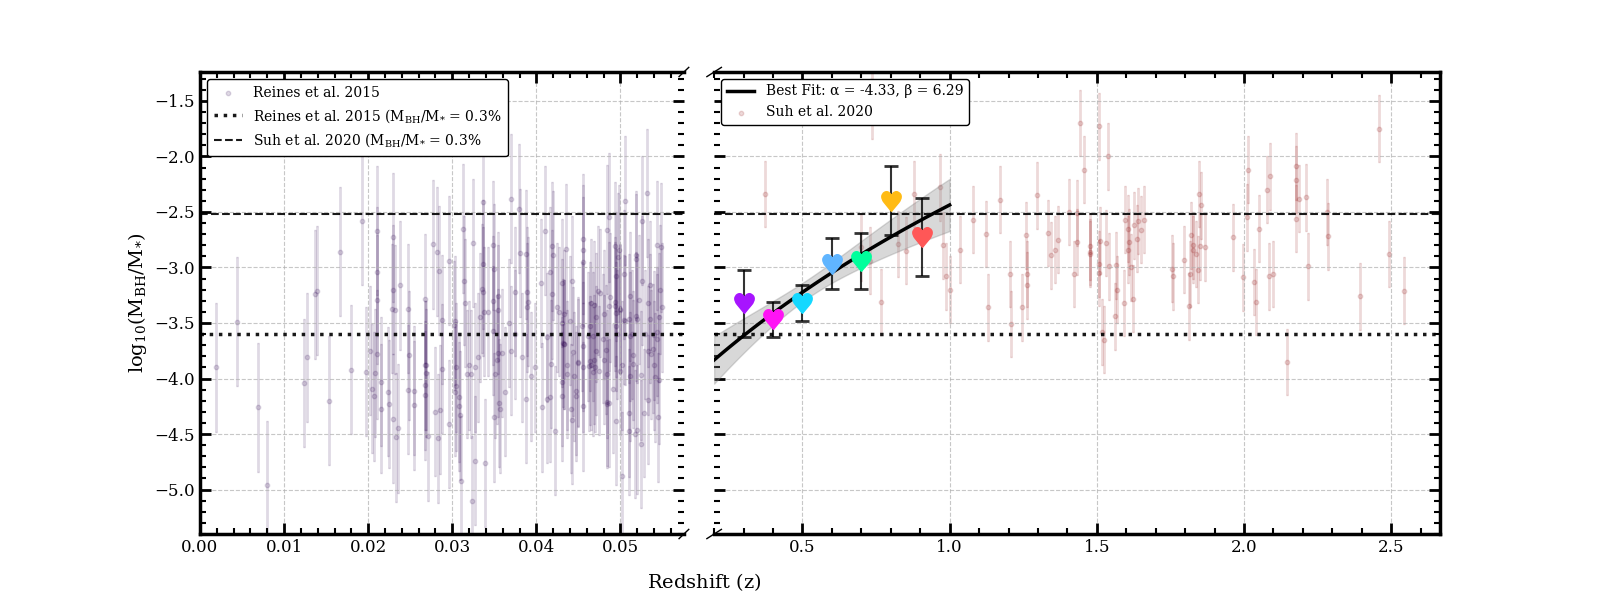


Reines et al. 2015 Statistics:
Median: -3.6850
RMS: 3.6809
Scatter (σ): 0.5499

Our Statistics:
Median: -2.9643 0.1518
RMS: 3.0409
Scatter (σ): 0.3512


In [108]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Color scheme
colors = {
    '025_035': "#a714ff",
    '035_045': "#ff14f5",
    '045_055': "#14D8FF",
    '055_065': "#60B5FF",
    '065_075': "#00FF9C",
    '075_085': "#ffbb14",
    '085_096': "#FF5757"
}

# Dataset configuration
datasets = [
    ('025_035', 0.3,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_SD_025_035),
    ('035_045', 0.4,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_035_045),
    ('045_055', 0.5,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_045_055),
    ('055_065', 0.6,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_055_065),
    ('065_075', 0.7,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_065_075),
    ('075_085', 0.8,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_075_085),
    ('085_096', 0.905,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_085_096)
]

# Reines 2015 data
Reines_2013_Redshifts = np.array([0.0422, 0.0424, 0.0548, 0.0419, 0.0296, 0.0447, 0.0479, 0.0388, 0.0486, 0.0247, 
                                  0.052, 0.0333, 0.0502, 0.0455, 0.0547, 0.0267, 0.041, 0.0179, 0.0529, 0.0324, 
                                  0.0413, 0.0524, 0.0539, 0.0413, 0.0389, 0.0455, 0.0254, 0.0215, 0.0444, 0.0471, 
                                  0.0493, 0.0435, 0.0124, 0.0285, 0.0449, 0.0495, 0.0506, 0.047, 0.0495, 0.0464, 
                                  0.0447, 0.0455, 0.0309, 0.0499, 0.0268, 0.0493, 0.039, 0.0254, 0.0327, 0.0284, 
                                  0.0484, 0.0511, 0.0493, 0.0269, 0.051, 0.0211, 0.0475, 0.0137, 0.0469, 0.0499, 
                                  0.0468, 0.043, 0.0405, 0.0339, 0.0515, 0.051, 0.0348, 0.0228, 0.0518, 0.0502, 
                                  0.0524, 0.0535, 0.0497, 0.0488, 0.0351, 0.042, 0.0467, 0.0433, 0.0456, 0.0431, 
                                  0.0069, 0.0431, 0.051, 0.0354, 0.0519, 0.0357, 0.0271, 0.0543, 0.037, 0.0433, 
                                  0.0526, 0.0315, 0.0388, 0.0336, 0.0314, 0.0441, 0.0327, 0.0417, 0.0518, 0.0288, 
                                  0.0232, 0.0282, 0.0322, 0.021, 0.0235, 0.0331, 0.0267, 0.0515, 0.0491, 0.0267, 
                                  0.0432, 0.0517, 0.0127, 0.0348, 0.0381, 0.0484, 0.031, 0.021, 0.054, 0.0308, 
                                  0.0511, 0.052, 0.0193, 0.0233, 0.0215, 0.0205, 0.0223, 0.0249, 0.0522, 0.0481,
                                  0.0303, 0.0229, 0.0313, 0.0499, 0.0511, 0.0283, 0.0277, 0.0139, 0.0019, 0.0473, 
                                  0.0455, 0.0305, 0.0208, 0.0407, 0.0504, 0.0533, 0.023, 0.0465, 0.0541, 0.048, 
                                  0.0207, 0.0526, 0.0368, 0.0296, 0.0487, 0.0546, 0.0288, 0.0484, 0.032, 0.0496, 
                                  0.0528, 0.0442, 0.0476, 0.0202, 0.0044, 0.0238, 0.0546, 0.0247, 0.0225, 0.023, 
                                  0.0325, 0.008, 0.0338, 0.0535, 0.0349, 0.0536, 0.0167, 0.0545, 0.0498, 0.0471, 
                                  0.0433, 0.028, 0.037, 0.0495, 0.021, 0.0303, 0.0437, 0.0442, 0.044, 0.035, 
                                  0.0302, 0.0427, 0.0464, 0.054, 0.0454, 0.0375, 0.0308, 0.0398, 0.0449, 0.0394, 
                                  0.0354, 0.0359, 0.0336, 0.0419, 0.0197, 0.0504, 0.0353, 0.0484, 0.0375, 0.0456, 
                                  0.0486, 0.0355, 0.0153, 0.043, 0.0532, 0.0317, 0.0445, 0.0463, 0.0335, 0.0416, 
                                  0.0379, 0.0342, 0.0483, 0.0383, 0.0514, 0.0336, 0.0506, 0.0467, 0.0465, 0.0389, 
                                  0.0495, 0.0543, 0.0269, 0.0436, 0.0461, 0.0549, 0.0533, 0.0533, 0.0416, 0.035, 
                                  0.0356, 0.0544, 0.0304, 0.0363])

Reines_2013_Log_Mbh_Mstar_Ratio = np.array([-4.47, -3.36, -2.82, -2.81, -4.41, -4.11, -3.64, -2.88, -4.22, -4.1, -4.46, -3.45, -3.88, -3.71, -3.2, -4.06, -2.67, -3.92, -3.6, -5.1, -3.63, -3.97, -3.73, -4.18, -3.22, -2.95, -4.11, -4.03, -3.76, -3.45, -3.35, -2.83, -4.04, -4.28, -3.85, -4.38, -2.4, -3.9, -3.53, -3.53, -4.16, -2.74, -4.33, -3.38, -3.28, -2.81, -3.31, -4.24, -3.9, -3.03, -4.21, -3.26, -3.31, -3.95, -3.46, -3.04, -3.93, -3.24, -3.34, -3.93, -3.83, -4.16, -3.14, -4.76, -3.79, -4.31, -3.57, -3.37, -3.44, -4.88, -4.59, -3.16, -2.91, -3.27, -3.96, -2.89, -3.94, -3.42, -4.25, -4.03, -4.26, -3.5, -4.47, -3.38, -2.92, -4.27, -4.52, -3.58, -3.75, -3.69, -2.58, -3.32, -4.18, -2.41, -3.12, -4.27, -4.74, -3.87, -2.89, -3.47, -3.38, -2.86, -3.96, -2.67, -4.45, -3.81, -4.15, -3.87, -4.09, -3.88, -3.68, -4.5, -3.81, -2.8, -2.87, -3.96, -4.92, -3.78, -3.88, -4.25, -3.62, -3.46, -2.58, -4.53, -4.27, -4.09, -4.12, -3.79, -3.29, -3.83, -3.48, -2.73, -2.65, -3.37, -3.98, -4.54, -2.79, -3.21, -3.9, -3.21, -3.9, -3.9, -3.95, -4.26, -3.47, -3.75, -3.2, -3.32, -3.99, -3.42, -4.16, -3.12, -3.5, -2.94, -3.35, -4.01, -3.91, -4.23, -3.88, -3.6, -4.31, -3.12, -3.23, -3.75, -3.49, -3.16, -3.45, -3.37, -4.23, -4.36, -2.78, -4.96, -3.4, -3.46, -3.3, -3.78, -2.86, -4.35, -2.84, -3.75, -3.69, -4.3, -2.38, -3.41, -3.29, -4.12, -3.96, -4.37, -3.48, -3.01, -3.52, -3.4, -3.84, -3.61, -3.53, -3.6, -4.17, -3.9, -3.86, -3.98, -3.26, -3.77, -3.22, -3.24, -3.94, -3.06, -3.83, -2.66, -3.22, -2.84, -2.55, -3.77, -4.2, -3.14, -2.33, -3.96, -3.98, -3.89, -3.19, -3.04, -2.47, -3.4, -3.74, -3.81, -3.6, -2.97, -3.48, -3.62, -3.88, -3.36, -3.08, -2.8, -3.88, -3.88, -3.62, -3.36, -4.19, -3.32, -4.17, -4.35, -4.22, -3.64, -4.07, -4.12])

Reines_Log_Mbh_Mstar_Ratio_Error = np.full(len(Reines_2013_Log_Mbh_Mstar_Ratio), 0.58)


#Suh et al. 2020

Suh_2020_Redshifts = np.array([1.826, 1.478, 1.512, 0.979, 1.638, 1.606, 1.506, 1.847, 1.431, 0.729, 1.002, 0.699, 1.333, 2.459, 1.627, 1.850, 2.051, 2.188, 2.211, 1.034, 0.372, 1.172, 1.537, 2.175, 2.177, 1.650, 1.406, 1.478, 2.286, 2.283, 0.967, 2.015, 1.131, 1.516, 1.122, 2.097, 1.845, 0.880, 1.298, 1.639, 1.607, 1.458, 1.836, 1.081, 1.343, 0.825, 1.369, 0.986, 1.796, 1.617, 1.817, 2.492, 1.869, 1.998, 1.358, 1.566, 2.218, 1.827, 1.661, 1.855, 1.814, 0.088, 1.759, 1.444, 2.177, 2.089, 1.568, 1.964, 2.010, 1.506, 1.755, 1.530, 1.819, 1.205, 0.851, 1.209, 0.767, 1.434, 1.260, 2.034, 2.543, 2.079, 1.561, 2.393, 1.421, 2.039, 1.264, 1.477, 1.507, 1.622, 1.247, 0.736, 1.263, 1.541, 1.523, 1.592, 1.596, 2.084, 1.608, 2.146])

Suh_2020_Log_Mbh = np.array([9.38, 8.62, 8.45, 8.42, 8.85, 8.77, 7.74, 8.75, 8.26, 7.90, 7.47, 8.43, 8.56, 9.20, 8.47, 8.80, 8.92, 8.75, 9.53, 8.27, 8.32, 8.66, 9.13, 9.50, 9.24, 8.74, 8.57, 8.71, 9.56, 8.72, 9.06, 9.40, 8.36, 8.41, 9.10, 8.45, 7.85, 8.66, 8.68, 8.73, 8.34, 8.87, 8.55, 8.62, 8.60, 7.70, 8.58, 8.39, 8.03, 8.47, 8.72, 8.25, 7.88, 8.85, 8.20, 8.79, 7.77, 8.09, 8.56, 8.73, 8.09, 5.85, 7.75, 8.55, 8.26, 8.60, 8.93, 8.75, 8.47, 7.69, 7.57, 8.62, 8.19, 7.93, 8.28, 8.06, 8.15, 8.98, 8.54, 7.81, 8.66, 8.84, 8.91, 7.94, 7.36, 9.04, 8.03, 8.42, 9.65, 8.49, 8.02, 8.42, 8.22, 8.66, 8.19, 8.46, 8.78, 8.08, 8.90, 8.02,])

Suh_2020_Log_Mstellar = np.array([12.18, 11.48, 11.21, 11.22, 11.59, 11.61, 10.79, 11.09, 11.03, 10.84, 10.67, 11.25, 11.25, 10.95, 11.09, 11.61, 11.57, 11.13, 11.90, 11.11, 10.66, 11.05, 11.13, 11.71, 11.80, 11.40, 11.07, 11.52, 12.28, 11.22, 11.34, 11.52, 11.72, 11.99, 11.80, 11.51, 10.87, 11.00, 11.03, 11.31, 10.99, 10.99, 11.43, 11.19, 11.49, 10.49, 11.33, 11.47, 10.96, 11.47, 11.78, 11.13, 10.70, 11.94, 11.04, 11.77, 10.76, 10.93, 11.13, 11.17, 11.44, 8.01, 10.83, 10.25, 10.35, 10.78, 12.13, 11.48, 11.02, 10.66, 10.58, 11.40, 10.90, 10.99, 11.13, 11.57, 11.46, 11.49, 11.25, 10.94, 11.87, 11.14, 12.35, 11.20, 10.42, 12.35, 11.19, 11.30, 11.38, 11.77, 11.38, 9.96, 11.28, 11.65, 11.84, 11.78, 11.35, 11.16, 11.67, 11.87])

Suh_2020_Log_Mbh_Mstellar_Ratio = np.subtract(Suh_2020_Log_Mbh, Suh_2020_Log_Mstellar)

Suh_Log_Mbh_Mstar_Ratio_Error = np.full(len(Suh_2020_Log_Mbh_Mstellar), 0.3)


print(f"Reines data: {len(Reines_2013_Redshifts)} redshifts, {len(Reines_2013_Log_Mbh_Mstar_Ratio)} ratios")

# Extract data for fitting
x_data = np.array([dataset[1] for dataset in datasets])
y_data = np.array([dataset[2] for dataset in datasets])
y_errors = np.array([dataset[3] for dataset in datasets])

print("Our data (redshift):", x_data)
print("Our data (log M_BH/M_*):", y_data)

# Define power law function
def power_law_fit(z, a, b):
    return a + b * np.log10(1 + z)

# Perform fitting
try:
    initial_guess = [-2.5, 0.5]
    popt, pcov = curve_fit(
        power_law_fit, 
        x_data, 
        y_data, 
        sigma=y_errors, 
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=5000
    )
    
    a_fit = popt[0]
    b_fit = popt[1]
    a_fit_err = np.sqrt(np.diag(pcov))[0]
    b_fit_err = np.sqrt(np.diag(pcov))[1]
    fit_successful = True
    
    print(f"\nFit successful!")
    print(f"log(M_BH/M_*) = {a_fit:.3f} ± {a_fit_err:.3f} + ({b_fit:.3f} ± {b_fit_err:.3f}) * log10(1+z)")
    
except Exception as e:
    fit_successful = False
    print(f"Fit failed: {e}")

# ===== CREATE BROKEN AXIS FIGURE =====
fig = plt.figure(figsize=(16, 6), facecolor='white')

# Create two subplots side by side with a small gap
# Left panel: Reines data (z ~ 0-0.06)
# Right panel: Our data (z ~ 0.25-1.0)
#ax1 = plt.subplot(1, 2, 1)  # Left panel
#ax2 = plt.subplot(1, 2, 2)  # Right panel

# Set x-axis limits for each panel
#ax1.set_xlim(-0.005, 0.06)
#ax2.set_xlim(0.2, 1.0)

gs = fig.add_gridspec(1, 2, width_ratios=[2, 3], wspace=0.05)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


# ===== PLOT REINES DATA (LEFT PANEL) =====
ax1.scatter(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
           color="#2A004E", s=40, marker='.', alpha=0.15, zorder=0,
           label='Reines et al. 2015')
ax1.errorbar(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
            yerr=Reines_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#2A004E",
            capsize=1, capthick=1, alpha=0.15, zorder=0)

# Local universe reference line
ax1.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000, label="Reines et al. 2015 (M$_{BH}$/M$_{*}$ = 0.3%")

ax1.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000, label="Suh et al. 2020 (M$_{BH}$/M$_{*}$ = 0.3%")

# ===== PLOT OUR DATA (RIGHT PANEL) =====
# Plot best fit line if successful
if fit_successful:
    x_fit = np.linspace(0.2, 1.0, 100)
    y_fit = power_law_fit(x_fit, a_fit, b_fit)
    
    log_term = np.log10(1 + x_fit)
    y_fit_err = np.sqrt(a_fit_err**2 + (log_term**2) * (b_fit_err**2) + 
                        2 * log_term * pcov[0, 1])
    
    y_fit_upper = y_fit + y_fit_err
    y_fit_lower = y_fit - y_fit_err

    ax2.plot(x_fit, y_fit, color='black', linewidth=2.5, 
            label=f"Best Fit: α = {a_fit:.2f}, β = {b_fit:.2f}", zorder=30)
    ax2.fill_between(x_fit, y_fit_lower, y_fit_upper, 
                   color='gray', alpha=0.3, zorder=25)

# Plot our data points with heart markers
for i, (key, x_data_point, y_data_point, y_err) in enumerate(datasets):
    ax2.scatter(x_data_point, y_data_point,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10000)
    
    ax2.errorbar(x_data_point, y_data_point,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=100)

# Local universe reference line on right panel too
ax2.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000)

#Plot Suh et al. 2020 data
ax2.scatter(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
           color="#8B0000", s=40, marker='.', alpha=0.15, zorder=0,
           label='Suh et al. 2020')
ax2.errorbar(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
            yerr=Suh_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#8B0000",
            capsize=1, capthick=1, alpha=0.15, zorder=0)

ax2.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000)

# ===== CONFIGURE AXES =====
# Y-axis label only on left panel
ax1.set_ylabel(r"log$_{10}$(M$_{\rm BH}$/M$_{*}$)", fontsize=14, color="black")
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

# X-axis labels
fig.text(0.44, 0.02, r"Redshift ($z$)", ha='center', fontsize=14, color="black")

# Shared y-axis limits
y_min = min(Reines_2013_Log_Mbh_Mstar_Ratio.min(), Reines_2013_Log_Mbh_Mstar_Ratio.min() - 0.3)
y_max = max(Suh_2020_Log_Mbh_Mstellar_Ratio.max(), Suh_2020_Log_Mbh_Mstellar_Ratio.max() + 0.3)
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

# Make x limits for each plot
ax1.set_xlim(0.0)
ax2.set_xlim(min(x_data)-0.1)

# Configure grid for both panels
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    ax.tick_params(top=True, right=True)

# Hide the spines between ax1 and ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Add diagonal break markers
d = 0.01  # size of diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.0)  # Changed from 1.5
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Add legends
ax1.legend(loc='upper left', fontsize=10, frameon=True, fancybox=True,
          edgecolor='black', facecolor='white', framealpha=1.0, borderpad=0.5)
ax2.legend(loc='upper left', fontsize=10, frameon=True, fancybox=True,
          edgecolor='black', facecolor='white', framealpha=1.0)

# Adjust layout
#plt.subplots_adjust(wspace=0.03, bottom=0.12)

# Save figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_With_Reines_Z.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()





# Calculate RMS and scatter for Reines data
reines_median = np.median(Reines_2013_Log_Mbh_Mstar_Ratio)
reines_rms = np.sqrt(np.mean(Reines_2013_Log_Mbh_Mstar_Ratio**2))
reines_scatter = np.std(Reines_2013_Log_Mbh_Mstar_Ratio)

print(f"\nReines et al. 2015 Statistics:")
print(f"Median: {reines_median:.4f}")
print(f"RMS: {reines_rms:.4f}")
print(f"Scatter (σ): {reines_scatter:.4f}")










import numpy as np

def median_with_error(data, errors, method='bootstrap', n_bootstrap=10000):
    """
    Calculate the median and its uncertainty given data and errors.
    
    Parameters:
    -----------
    data : array-like
        The data values
    errors : array-like
        The uncertainties on each data point
    method : str
        'bootstrap' - Monte Carlo bootstrap sampling (default, most robust)
        'analytical' - Analytical approximation (faster but less accurate)
    n_bootstrap : int
        Number of bootstrap samples (only used if method='bootstrap')
    
    Returns:
    --------
    median : float
        The median of the data
    median_error : float
        The uncertainty on the median
    """
    data = np.array(data)
    errors = np.array(errors)
    
    # Calculate the median
    median = np.median(data)
    
    if method == 'bootstrap':
        # Bootstrap method: sample from normal distributions for each data point
        medians = []
        for i in range(n_bootstrap):
            # Generate samples from normal distribution for each data point
            samples = np.random.normal(data, errors)
            medians.append(np.median(samples))
        
        # The error is the standard deviation of the bootstrap medians
        median_error = np.std(medians)
        
    elif method == 'analytical':
        # Analytical approximation: σ_median ≈ 1.253 * σ / sqrt(N)
        # This assumes normally distributed errors
        # Use propagation of errors through the median
        n = len(data)
        # Approximate standard error of median
        median_error = 1.253 * np.sqrt(np.sum(errors**2)) / np.sqrt(n)
    
    else:
        raise ValueError("method must be 'bootstrap' or 'analytical'")
    
    return median, median_error




#Calculate the Median, RMS, and Scatter for our data
Our_Median, Our_Median_Err = median_with_error(y_data, y_errors)
Our_RMS = np.sqrt(np.mean(y_data**2))
Our_Scatter = np.std(y_data)

print(f"\nOur Statistics:")
print(f"Median: {Our_Median:.4f} {Our_Median_Err:.4f}")
print(f"RMS: {Our_RMS:.4f}")
print(f"Scatter (σ): {Our_Scatter:.4f}")


In [91]:
print(np.log10(0.0002))
print(np.log10(0.00025))
print(np.log10(0.0003))
print("")
print(abs(np.log10(0.0002)) - abs(np.log10(0.0003)))
print("")
print((10**(-3.6020599913279625))*100)
print("")
print(y_data)

-3.6989700043360187
-3.6020599913279625
-3.5228787452803374

0.17609125905568135

0.024999999999999994

[-3.32374779 -3.46811545 -3.32035667 -2.96433163 -2.9398353  -2.39909171
 -2.72830627]


In [93]:
print((10**(-2.9643))*100)
print(((10**(-2.9643)) * np.log(10) * 0.1499)*100)

print("")

print(0.025/100)

0.10856754065290232
0.037472901503490655

0.00025


Reines data: 244 redshifts, 244 ratios
Our data (redshift): [0.3   0.4   0.5   0.6   0.7   0.8   0.905]
Our data (log M_BH/M_*): [-3.32374779 -3.46811545 -3.32035667 -2.96433163 -2.9398353  -2.39909171
 -2.72830627]
Fit successful!
log(M_BH/M_*) = -4.331 ± 0.354 + (6.291 ± 1.873) * log10(1+z)


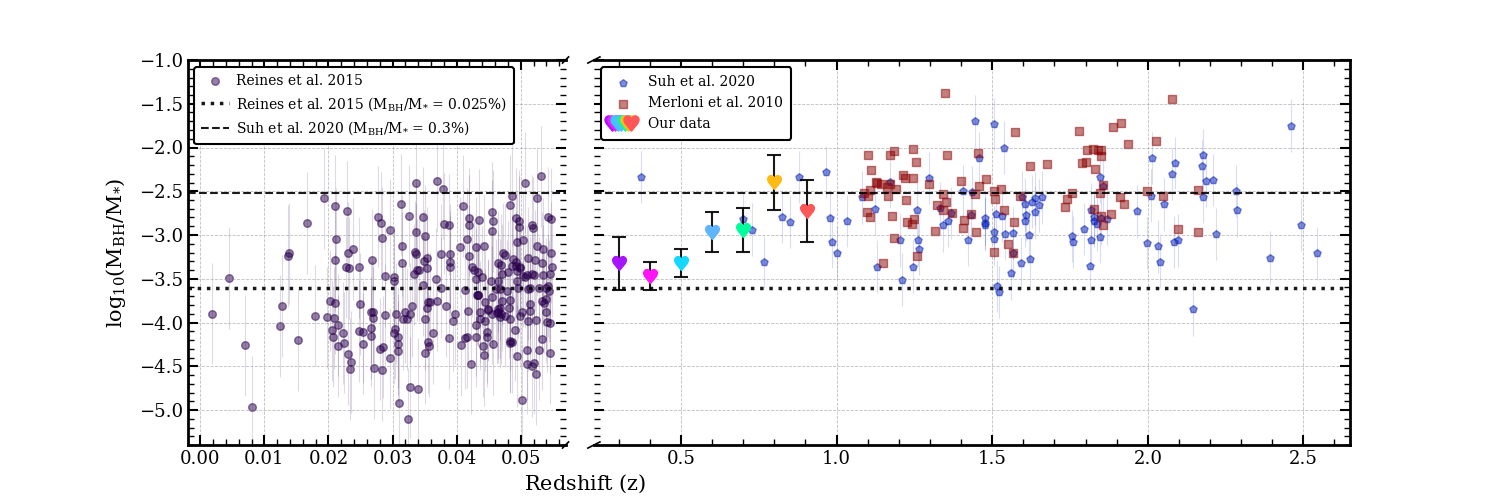


Reines et al. 2015 Statistics:
Median: -3.6850
RMS: 3.6809
Scatter (σ): 0.5499

Our Statistics:
Median: -2.9643 ± 0.1498
RMS: 3.0409
Scatter (σ): 0.3512


In [147]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 13,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.0,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'grid.linewidth': 0.6,
    'xtick.major.size': 7,
    'xtick.minor.size': 4,
    'ytick.major.size': 7,
    'ytick.minor.size': 4,
    'xtick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.major.width': 1.5,
    'ytick.minor.width': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 0.95
})

# Color scheme (unchanged)
colors = {
    '025_035': "#a714ff",
    '035_045': "#ff14f5",
    '045_055': "#14D8FF",
    '055_065': "#60B5FF",
    '065_075': "#00FF9C",
    '075_085': "#ffbb14",
    '085_096': "#FF5757"
}

# Dataset configuration
datasets = [
    ('025_035', 0.3,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_025_035_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_FeII_Removed_SD_025_035),
    ('035_045', 0.4,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_035_045_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_035_045),
    ('045_055', 0.5,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_045_055_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_045_055),
    ('055_065', 0.6,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_055_065_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_055_065),
    ('065_075', 0.7,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_065_075_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_065_075),
    ('075_085', 0.8,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_075_085_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_075_085),
    ('085_096', 0.905,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_085_096_a,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_SD_085_096)
]

# Reines 2015 data
Reines_2013_Redshifts = np.array([0.0422, 0.0424, 0.0548, 0.0419, 0.0296, 0.0447, 0.0479, 0.0388, 0.0486, 0.0247, 
                                  0.052, 0.0333, 0.0502, 0.0455, 0.0547, 0.0267, 0.041, 0.0179, 0.0529, 0.0324, 
                                  0.0413, 0.0524, 0.0539, 0.0413, 0.0389, 0.0455, 0.0254, 0.0215, 0.0444, 0.0471, 
                                  0.0493, 0.0435, 0.0124, 0.0285, 0.0449, 0.0495, 0.0506, 0.047, 0.0495, 0.0464, 
                                  0.0447, 0.0455, 0.0309, 0.0499, 0.0268, 0.0493, 0.039, 0.0254, 0.0327, 0.0284, 
                                  0.0484, 0.0511, 0.0493, 0.0269, 0.051, 0.0211, 0.0475, 0.0137, 0.0469, 0.0499, 
                                  0.0468, 0.043, 0.0405, 0.0339, 0.0515, 0.051, 0.0348, 0.0228, 0.0518, 0.0502, 
                                  0.0524, 0.0535, 0.0497, 0.0488, 0.0351, 0.042, 0.0467, 0.0433, 0.0456, 0.0431, 
                                  0.0069, 0.0431, 0.051, 0.0354, 0.0519, 0.0357, 0.0271, 0.0543, 0.037, 0.0433, 
                                  0.0526, 0.0315, 0.0388, 0.0336, 0.0314, 0.0441, 0.0327, 0.0417, 0.0518, 0.0288, 
                                  0.0232, 0.0282, 0.0322, 0.021, 0.0235, 0.0331, 0.0267, 0.0515, 0.0491, 0.0267, 
                                  0.0432, 0.0517, 0.0127, 0.0348, 0.0381, 0.0484, 0.031, 0.021, 0.054, 0.0308, 
                                  0.0511, 0.052, 0.0193, 0.0233, 0.0215, 0.0205, 0.0223, 0.0249, 0.0522, 0.0481,
                                  0.0303, 0.0229, 0.0313, 0.0499, 0.0511, 0.0283, 0.0277, 0.0139, 0.0019, 0.0473, 
                                  0.0455, 0.0305, 0.0208, 0.0407, 0.0504, 0.0533, 0.023, 0.0465, 0.0541, 0.048, 
                                  0.0207, 0.0526, 0.0368, 0.0296, 0.0487, 0.0546, 0.0288, 0.0484, 0.032, 0.0496, 
                                  0.0528, 0.0442, 0.0476, 0.0202, 0.0044, 0.0238, 0.0546, 0.0247, 0.0225, 0.023, 
                                  0.0325, 0.008, 0.0338, 0.0535, 0.0349, 0.0536, 0.0167, 0.0545, 0.0498, 0.0471, 
                                  0.0433, 0.028, 0.037, 0.0495, 0.021, 0.0303, 0.0437, 0.0442, 0.044, 0.035, 
                                  0.0302, 0.0427, 0.0464, 0.054, 0.0454, 0.0375, 0.0308, 0.0398, 0.0449, 0.0394, 
                                  0.0354, 0.0359, 0.0336, 0.0419, 0.0197, 0.0504, 0.0353, 0.0484, 0.0375, 0.0456, 
                                  0.0486, 0.0355, 0.0153, 0.043, 0.0532, 0.0317, 0.0445, 0.0463, 0.0335, 0.0416, 
                                  0.0379, 0.0342, 0.0483, 0.0383, 0.0514, 0.0336, 0.0506, 0.0467, 0.0465, 0.0389, 
                                  0.0495, 0.0543, 0.0269, 0.0436, 0.0461, 0.0549, 0.0533, 0.0533, 0.0416, 0.035, 
                                  0.0356, 0.0544, 0.0304, 0.0363])

Reines_2013_Log_Mbh_Mstar_Ratio = np.array([-4.47, -3.36, -2.82, -2.81, -4.41, -4.11, -3.64, -2.88, -4.22, -4.1, -4.46, -3.45, -3.88, -3.71, -3.2, -4.06, -2.67, -3.92, -3.6, -5.1, -3.63, -3.97, -3.73, -4.18, -3.22, -2.95, -4.11, -4.03, -3.76, -3.45, -3.35, -2.83, -4.04, -4.28, -3.85, -4.38, -2.4, -3.9, -3.53, -3.53, -4.16, -2.74, -4.33, -3.38, -3.28, -2.81, -3.31, -4.24, -3.9, -3.03, -4.21, -3.26, -3.31, -3.95, -3.46, -3.04, -3.93, -3.24, -3.34, -3.93, -3.83, -4.16, -3.14, -4.76, -3.79, -4.31, -3.57, -3.37, -3.44, -4.88, -4.59, -3.16, -2.91, -3.27, -3.96, -2.89, -3.94, -3.42, -4.25, -4.03, -4.26, -3.5, -4.47, -3.38, -2.92, -4.27, -4.52, -3.58, -3.75, -3.69, -2.58, -3.32, -4.18, -2.41, -3.12, -4.27, -4.74, -3.87, -2.89, -3.47, -3.38, -2.86, -3.96, -2.67, -4.45, -3.81, -4.15, -3.87, -4.09, -3.88, -3.68, -4.5, -3.81, -2.8, -2.87, -3.96, -4.92, -3.78, -3.88, -4.25, -3.62, -3.46, -2.58, -4.53, -4.27, -4.09, -4.12, -3.79, -3.29, -3.83, -3.48, -2.73, -2.65, -3.37, -3.98, -4.54, -2.79, -3.21, -3.9, -3.21, -3.9, -3.9, -3.95, -4.26, -3.47, -3.75, -3.2, -3.32, -3.99, -3.42, -4.16, -3.12, -3.5, -2.94, -3.35, -4.01, -3.91, -4.23, -3.88, -3.6, -4.31, -3.12, -3.23, -3.75, -3.49, -3.16, -3.45, -3.37, -4.23, -4.36, -2.78, -4.96, -3.4, -3.46, -3.3, -3.78, -2.86, -4.35, -2.84, -3.75, -3.69, -4.3, -2.38, -3.41, -3.29, -4.12, -3.96, -4.37, -3.48, -3.01, -3.52, -3.4, -3.84, -3.61, -3.53, -3.6, -4.17, -3.9, -3.86, -3.98, -3.26, -3.77, -3.22, -3.24, -3.94, -3.06, -3.83, -2.66, -3.22, -2.84, -2.55, -3.77, -4.2, -3.14, -2.33, -3.96, -3.98, -3.89, -3.19, -3.04, -2.47, -3.4, -3.74, -3.81, -3.6, -2.97, -3.48, -3.62, -3.88, -3.36, -3.08, -2.8, -3.88, -3.88, -3.62, -3.36, -4.19, -3.32, -4.17, -4.35, -4.22, -3.64, -4.07, -4.12])

Reines_Log_Mbh_Mstar_Ratio_Error = np.full(len(Reines_2013_Log_Mbh_Mstar_Ratio), 0.58)

# Suh et al. 2020
Suh_2020_Redshifts = np.array([1.826, 1.478, 1.512, 0.979, 1.638, 1.606, 1.506, 1.847, 1.431, 0.729, 1.002, 0.699, 1.333, 2.459, 1.627, 1.850, 2.051, 2.188, 2.211, 1.034, 0.372, 1.172, 1.537, 2.175, 2.177, 1.650, 1.406, 1.478, 2.286, 2.283, 0.967, 2.015, 1.131, 1.516, 1.122, 2.097, 1.845, 0.880, 1.298, 1.639, 1.607, 1.458, 1.836, 1.081, 1.343, 0.825, 1.369, 0.986, 1.796, 1.617, 1.817, 2.492, 1.869, 1.998, 1.358, 1.566, 2.218, 1.827, 1.661, 1.855, 1.814, 0.088, 1.759, 1.444, 2.177, 2.089, 1.568, 1.964, 2.010, 1.506, 1.755, 1.530, 1.819, 1.205, 0.851, 1.209, 0.767, 1.434, 1.260, 2.034, 2.543, 2.079, 1.561, 2.393, 1.421, 2.039, 1.264, 1.477, 1.507, 1.622, 1.247, 0.736, 1.263, 1.541, 1.523, 1.592, 1.596, 2.084, 1.608, 2.146])

Suh_2020_Log_Mbh = np.array([9.38, 8.62, 8.45, 8.42, 8.85, 8.77, 7.74, 8.75, 8.26, 7.90, 7.47, 8.43, 8.56, 9.20, 8.47, 8.80, 8.92, 8.75, 9.53, 8.27, 8.32, 8.66, 9.13, 9.50, 9.24, 8.74, 8.57, 8.71, 9.56, 8.72, 9.06, 9.40, 8.36, 8.41, 9.10, 8.45, 7.85, 8.66, 8.68, 8.73, 8.34, 8.87, 8.55, 8.62, 8.60, 7.70, 8.58, 8.39, 8.03, 8.47, 8.72, 8.25, 7.88, 8.85, 8.20, 8.79, 7.77, 8.09, 8.56, 8.73, 8.09, 5.85, 7.75, 8.55, 8.26, 8.60, 8.93, 8.75, 8.47, 7.69, 7.57, 8.62, 8.19, 7.93, 8.28, 8.06, 8.15, 8.98, 8.54, 7.81, 8.66, 8.84, 8.91, 7.94, 7.36, 9.04, 8.03, 8.42, 9.65, 8.49, 8.02, 8.42, 8.22, 8.66, 8.19, 8.46, 8.78, 8.08, 8.90, 8.02,])

Suh_2020_Log_Mstellar = np.array([12.18, 11.48, 11.21, 11.22, 11.59, 11.61, 10.79, 11.09, 11.03, 10.84, 10.67, 11.25, 11.25, 10.95, 11.09, 11.61, 11.57, 11.13, 11.90, 11.11, 10.66, 11.05, 11.13, 11.71, 11.80, 11.40, 11.07, 11.52, 12.28, 11.22, 11.34, 11.52, 11.72, 11.99, 11.80, 11.51, 10.87, 11.00, 11.03, 11.31, 10.99, 10.99, 11.43, 11.19, 11.49, 10.49, 11.33, 11.47, 10.96, 11.47, 11.78, 11.13, 10.70, 11.94, 11.04, 11.77, 10.76, 10.93, 11.13, 11.17, 11.44, 8.01, 10.83, 10.25, 10.35, 10.78, 12.13, 11.48, 11.02, 10.66, 10.58, 11.40, 10.90, 10.99, 11.13, 11.57, 11.46, 11.49, 11.25, 10.94, 11.87, 11.14, 12.35, 11.20, 10.42, 12.35, 11.19, 11.30, 11.38, 11.77, 11.38, 9.96, 11.28, 11.65, 11.84, 11.78, 11.35, 11.16, 11.67, 11.87])

Suh_2020_Log_Mbh_Mstellar_Ratio = np.subtract(Suh_2020_Log_Mbh, Suh_2020_Log_Mstellar)
Suh_Log_Mbh_Mstar_Ratio_Error = np.full(len(Suh_2020_Log_Mbh_Mstellar), 0.3)

#Meloni et al. 2010
Merloni_2010_Redshifts = np.array([1.126, 1.246, 1.149, 1.349, 2.096, 1.824, 1.550, 1.851, 1.444, 1.192, 1.675, 1.351, 1.567, 1.215, 1.507, 1.171, 1.537, 1.914, 1.780, 1.923, 1.806, 1.756, 1.910, 1.166, 1.248, 1.244, 1.481, 1.220, 1.855, 1.850, 1.355, 1.226, 1.099, 1.343, 1.087, 1.298, 1.258, 2.078, 1.841, 1.510, 2.160, 1.828, 1.407, 1.742, 1.323, 1.185, 2.025, 1.370, 1.848, 1.936, 1.789, 1.454, 1.315, 1.735, 1.528, 1.800, 1.131, 1.101, 1.108, 1.161, 1.849, 1.185, 1.242, 1.996, 1.573, 1.447, 1.102, 1.832, 1.342, 1.506, 1.401, 1.589, 1.256, 1.458, 1.171, 1.223, 1.144, 2.050, 2.162, 1.410, 1.177, 1.882, 1.569, 1.108, 1.889, 1.856, 1.112, 1.432, 1.623])

Merloni_2010_Log_Mstellar = np.array([11.06, 10.70, 10.99, 10.43, 11.44, 10.48, 11.18, 10.59, 10.66, 10.35, 10.90, 11.16, 11.21, 10.69, 11.25, 10.92, 10.99, 10.68, 10.87, 11.37, 10.72, 11.44, 10.68, 10.69, 10.89, 10.67, 10.64, 10.85, 10.78, 10.67, 10.92, 11.24, 11.26, 11.39, 10.97, 10.80, 11.22, 10.22, 10.08, 11.09, 11.56, 11.29, 11.24, 10.91, 11.13, 11.05, 11.04, 11.18, 11.28, 10.53, 10.86, 11.18, 11.14, 10.76, 10.78, 10.67, 10.81, 10.61, 11.17, 11.48, 11.72, 10.65, 10.32, 10.76, 9.72, 11.16, 10.61, 11.19, 10.76, 10.77, 10.99, 10.78, 10.74, 11.24, 10.54, 10.86, 10.81, 11.27, 10.85, 10.86, 11.14, 11.17, 11.46, 11.26, 10.39, 11.23, 10.71, 11.33, 10.86])

Merloni_2010_Log_Mbh = np.array([8.67 ,8.35 ,7.67 ,9.05 ,8.51 ,8.46 ,8.08 ,8.56 ,8.13 ,7.88 ,8.71 ,8.54 ,8.01 ,8.38 ,8.05 ,8.50 ,8.28 ,8.96 ,9.06 ,8.72 ,8.69 ,8.92 ,8.12 ,8.13 ,8.07 ,8.65 ,8.28 ,8.50 ,8.35 ,8.57 ,8.83 ,8.39 ,8.52 ,8.86 ,8.45 ,8.38 ,7.98 ,8.77 ,8.05 ,8.50 ,8.59 ,8.59 ,8.32 ,8.32 ,8.47 ,8.02 ,9.12 ,8.43 ,8.76 ,8.57 ,8.68 ,9.12 ,8.19 ,8.08 ,8.30 ,8.50 ,8.40 ,8.06 ,8.69 ,9.03 ,8.94 ,8.61 ,7.45 ,8.26 ,7.90 ,8.19 ,8.52 ,8.95 ,8.05 ,8.27 ,8.61 ,8.22 ,8.57 ,8.80 ,8.45 ,8.26 ,8.39 ,8.72 ,8.37 ,8.03 ,8.36 ,8.41 ,8.61 ,8.46 ,8.62 ,8.34 ,8.45 ,8.57 ,8.65])

Merloni_2010_Mbh_Mstellar_Ratio = np.subtract(Merloni_2010_Log_Mbh, Merloni_2010_Log_Mstellar)

# Extract data for fitting
x_data = np.array([dataset[1] for dataset in datasets])
y_data = np.array([dataset[2] for dataset in datasets])
y_errors = np.array([dataset[3] for dataset in datasets])

print(f"Reines data: {len(Reines_2013_Redshifts)} redshifts, {len(Reines_2013_Log_Mbh_Mstar_Ratio)} ratios")
print("Our data (redshift):", x_data)
print("Our data (log M_BH/M_*):", y_data)

# Define power law function
def power_law_fit(z, a, b):
    return a + b * np.log10(1 + z)

# Perform fitting
try:
    initial_guess = [-2.5, 0.5]
    popt, pcov = curve_fit(
        power_law_fit, 
        x_data, 
        y_data, 
        sigma=y_errors, 
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=5000
    )
    
    a_fit = popt[0]
    b_fit = popt[1]
    a_fit_err = np.sqrt(np.diag(pcov))[0]
    b_fit_err = np.sqrt(np.diag(pcov))[1]
    fit_successful = True
    
    print(f"Fit successful!")
    print(f"log(M_BH/M_*) = {a_fit:.3f} ± {a_fit_err:.3f} + ({b_fit:.3f} ± {b_fit_err:.3f}) * log10(1+z)")
    
except Exception as e:
    fit_successful = False
    print(f"Fit failed: {e}")

# ===== CREATE IMPROVED BROKEN AXIS FIGURE =====
fig = plt.figure(figsize=(15, 5), facecolor='white')

gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 3], wspace=0.05)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ===== PLOT REINES DATA (LEFT PANEL) =====
ax1.scatter(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
           color="#2A004E", s=30, marker='o', alpha=0.5, zorder=0,
           label='Reines et al. 2015')
ax1.errorbar(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
            yerr=Reines_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#2A004E",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

# Local universe reference line
ax1.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000, label="Reines et al. 2015 (M$_{BH}$/M$_{*}$ = 0.025%)")

ax1.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000, label="Suh et al. 2020 (M$_{BH}$/M$_{*}$ = 0.3%)")

# ===== PLOT OUR DATA (RIGHT PANEL) =====
# Plot Suh et al. 2020 data first (background)
ax2.scatter(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
           color="#001BB7", s=30, marker='p', alpha=0.5, zorder=0,
           label='Suh et al. 2020')
ax2.errorbar(Suh_2020_Redshifts, Suh_2020_Log_Mbh_Mstellar_Ratio,
            yerr=Suh_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#001BB7",
            capsize=0, elinewidth=0.8, alpha=0.15, zorder=0)

# Plot Merloni et al. 2010 data first (background)
ax2.scatter(Merloni_2010_Redshifts, Merloni_2010_Mbh_Mstellar_Ratio,
           color="#8B0000", s=30, marker='s', alpha=0.5, zorder=0,
           label='Merloni et al. 2010')



# Plot our data points with heart markers (on top)
for i, (key, x_data_point, y_data_point, y_err) in enumerate(datasets):
    # Add white edge for better contrast
    ax2.scatter(x_data_point, y_data_point,
              color=colors[key],
              s=100,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10000)
    
    ax2.errorbar(x_data_point, y_data_point,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=1.5,
               elinewidth=1.5,
               alpha=0.9,
               zorder=100)

# Reference lines on right panel
ax2.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000)

ax2.axhline(y=np.log10(0.003), linewidth=1.5, linestyle='--', color='black', 
           alpha=0.9, zorder=1000)

# ===== CONFIGURE AXES =====
# Y-axis label only on left panel
ax1.set_ylabel(r"log$_{10}$(M$_{\rm BH}$/M$_{*}$)", fontsize=15, color="black", labelpad=8)
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

# X-axis labels
fig.text(0.39, 0.02, r"Redshift ($z$)", ha='center', fontsize=15, color="black")

# Shared y-axis limits
y_min = -5.4
y_max = -1.0
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

# Set x limits for each panel
ax1.set_xlim(-0.002, 0.057)
ax2.set_xlim(0.22, 2.65)

# Configure grid for both panels
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.5, zorder=-10, color='gray')
    ax.minorticks_on()
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)
    
    ax.tick_params(axis='both', which='major', labelsize=13,
                   length=7, width=1.5, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=11,
                   length=4, width=1.0, direction='in')
    ax.tick_params(top=True, right=True)

# Hide the spines between ax1 and ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Add diagonal break markers (smaller and cleaner)
d = 0.008
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.2)
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Add legends with better styling
legend1 = ax1.legend(loc='upper left', fontsize=10, frameon=True, 
          edgecolor='black', facecolor='white', framealpha=1.0, 
          borderpad=0.5, handletextpad=0.5, columnspacing=1.0)
legend1.get_frame().set_linewidth(1.5)

# Create custom gradient heart for legend
from matplotlib.legend_handler import HandlerBase
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors

class HandlerGradientHeart(HandlerBase):
    def __init__(self, colors, **kwargs):
        self.colors = colors
        HandlerBase.__init__(self, **kwargs)
    
    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                      width, height, fontsize, trans):
        # Create multiple overlapping hearts with different colors and horizontal offsets
        hearts = []
        cy = (height - ydescent) / 2.0
        
        n_hearts = len(self.colors)
        total_width = width * 0.8  # Use 80% of available width
        
        for i, color in enumerate(self.colors):
            # Spread hearts across the width to show gradient
            cx = xdescent + width / 2.0 + (i - n_hearts/2) * (total_width / n_hearts)
            c = ax2.scatter([cx], [cy], s=120, marker=u"$\u2665$",
                          color=color, alpha=1.0, 
                          transform=trans, clip_on=False)
            hearts.append(c)
        
        return hearts

# Get current legend handles and labels
handles, labels = ax2.get_legend_handles_labels()

# Add a dummy handle for our gradient heart
gradient_colors = ["#a714ff", "#ff14f5", "#14D8FF", "#60B5FF", "#00FF9C", "#ffbb14", "#FF5757"]
dummy_heart = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=0)
handles.append(dummy_heart)
labels.append('Our data')

# Create legend with custom handler
legend2 = ax2.legend(handles, labels, loc='upper left', fontsize=10, frameon=True,
          edgecolor='black', facecolor='white', framealpha=1.0,
          borderpad=0.6, handletextpad=0.8, columnspacing=1.0,
          handler_map={dummy_heart: HandlerGradientHeart(gradient_colors)})
legend2.get_frame().set_linewidth(1.5)

# Save figure
plt.tight_layout()
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_With_Reines_Z.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()


# Calculate RMS and scatter for Reines data
reines_median = np.median(Reines_2013_Log_Mbh_Mstar_Ratio)
reines_rms = np.sqrt(np.mean(Reines_2013_Log_Mbh_Mstar_Ratio**2))
reines_scatter = np.std(Reines_2013_Log_Mbh_Mstar_Ratio)

print(f"\nReines et al. 2015 Statistics:")
print(f"Median: {reines_median:.4f}")
print(f"RMS: {reines_rms:.4f}")
print(f"Scatter (σ): {reines_scatter:.4f}")


def median_with_error(data, errors, method='bootstrap', n_bootstrap=10000):
    """
    Calculate the median and its uncertainty given data and errors.
    
    Parameters:
    -----------
    data : array-like
        The data values
    errors : array-like
        The uncertainties on each data point
    method : str
        'bootstrap' - Monte Carlo bootstrap sampling (default, most robust)
        'analytical' - Analytical approximation (faster but less accurate)
    n_bootstrap : int
        Number of bootstrap samples (only used if method='bootstrap')
    
    Returns:
    --------
    median : float
        The median of the data
    median_error : float
        The uncertainty on the median
    """
    data = np.array(data)
    errors = np.array(errors)
    
    # Calculate the median
    median = np.median(data)
    
    if method == 'bootstrap':
        # Bootstrap method: sample from normal distributions for each data point
        medians = []
        for i in range(n_bootstrap):
            # Generate samples from normal distribution for each data point
            samples = np.random.normal(data, errors)
            medians.append(np.median(samples))
        
        # The error is the standard deviation of the bootstrap medians
        median_error = np.std(medians)
        
    elif method == 'analytical':
        # Analytical approximation: σ_median ≈ 1.253 * σ / sqrt(N)
        # This assumes normally distributed errors
        # Use propagation of errors through the median
        n = len(data)
        # Approximate standard error of median
        median_error = 1.253 * np.sqrt(np.sum(errors**2)) / np.sqrt(n)
    
    else:
        raise ValueError("method must be 'bootstrap' or 'analytical'")
    
    return median, median_error


# Calculate the Median, RMS, and Scatter for our data
Our_Median, Our_Median_Err = median_with_error(y_data, y_errors)
Our_RMS = np.sqrt(np.mean(y_data**2))
Our_Scatter = np.std(y_data)

print(f"\nOur Statistics:")
print(f"Median: {Our_Median:.4f} ± {Our_Median_Err:.4f}")
print(f"RMS: {Our_RMS:.4f}")
print(f"Scatter (σ): {Our_Scatter:.4f}")



In [34]:
import numpy as np

# Normalized ratio calculations (M_* normalized to 10^11 M_☉)
# log10(M_BH/M_☉) = α + β * log10(M_*/10^11 M_☉)
# This is equivalent to: log10(M_BH) - log10(M_*) + 11*β

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_FeII_Removed_025_035 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035 / (10**Stellar_Mass_Median_025_035 / 10**11))

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_035_045 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045 / (10**Stellar_Mass_Median_035_045 / 10**11))

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_045_055 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055 / (10**Stellar_Mass_Median_045_055 / 10**11))

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_055_065 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065 / (10**Stellar_Mass_Median_055_065 / 10**11))

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_065_075 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075 / (10**Stellar_Mass_Median_065_075 / 10**11))

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_075_085 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085 / (10**Stellar_Mass_Median_075_085 / 10**11))

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_085_096 = np.log10(BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096 / (10**Stellar_Mass_Median_085_096 / 10**11))


def standard_deviation_delta_BH_Stellar_normalized(M_BH, M_BH_SD, M_Stellar, M_Stellar_SD):
    """
    Calculate the standard deviation for log10(M_BH/(M_Stellar/10^11)).
    
    This function computes the error propagation for the ratio of black hole mass 
    to stellar mass (normalized to 10^11 M_☉) in logarithmic space.
    
    For y = log10(M_BH) - log10(M_Stellar/10^11) = log10(M_BH) - log10(M_Stellar) + 11:
    The error propagation is the same as the unnormalized case since the constant 
    (11) doesn't contribute to the uncertainty.
    
    σ_y = sqrt( (∂y/∂M_BH * σ_M_BH)^2 + (∂y/∂M_Stellar * σ_M_Stellar)^2 )
    
    where:
    ∂y/∂M_BH = 1/(M_BH * ln(10))
    ∂y/∂M_Stellar = -1/(M_Stellar * ln(10))
    
    Parameters
    ----------
    M_BH : float or array
        Black hole mass [NOT in log space]
    M_BH_SD : float or array
        Black hole mass standard deviation [NOT in log space]
    M_Stellar : float or array
        Stellar mass [NOT in log space]
    M_Stellar_SD : float or array
        Stellar mass standard deviation [NOT in log space]
    
    Returns
    -------
    Delta_BH_Stellar_SD : float or array
        The standard deviation for log10(M_BH/(M_Stellar/10^11))
    """
    # Term from black hole mass uncertainty
    term_one = ((1 / (M_BH * np.log(10))) * M_BH_SD)**2
    
    # Term from stellar mass uncertainty
    term_two = ((-1 / (M_Stellar * np.log(10))) * M_Stellar_SD)**2
    
    # Combined error (normalization constant doesn't affect error)
    return np.sqrt(term_one + term_two)


# Calculate errors for each redshift bin (errors are the same regardless of normalization)
BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_FeII_Removed_SD_025_035 = standard_deviation_delta_BH_Stellar_normalized(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_025_035,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_025_035,
    10**Stellar_Mass_Median_025_035,
    10**Stellar_Mass_Median_025_035 * Stellar_Mass_SD_025_035 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_035_045 = standard_deviation_delta_BH_Stellar_normalized(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_035_045,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_035_045,
    10**Stellar_Mass_Median_035_045,
    10**Stellar_Mass_Median_035_045 * Stellar_Mass_SD_035_045 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_045_055 = standard_deviation_delta_BH_Stellar_normalized(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_045_055,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_045_055,
    10**Stellar_Mass_Median_045_055,
    10**Stellar_Mass_Median_045_055 * Stellar_Mass_SD_045_055 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_055_065 = standard_deviation_delta_BH_Stellar_normalized(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_055_065,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_055_065,
    10**Stellar_Mass_Median_055_065,
    10**Stellar_Mass_Median_055_065 * Stellar_Mass_SD_055_065 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_065_075 = standard_deviation_delta_BH_Stellar_normalized(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_065_075,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_065_075,
    10**Stellar_Mass_Median_065_075,
    10**Stellar_Mass_Median_065_075 * Stellar_Mass_SD_065_075 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_075_085 = standard_deviation_delta_BH_Stellar_normalized(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_075_085,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_075_085,
    10**Stellar_Mass_Median_075_085,
    10**Stellar_Mass_Median_075_085 * Stellar_Mass_SD_075_085 * np.log(10)
)

BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_085_096 = standard_deviation_delta_BH_Stellar_normalized(
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_085_096,
    BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_3000_AGN_Only_median_SD_085_096,
    10**Stellar_Mass_Median_085_096,
    10**Stellar_Mass_Median_085_096 * Stellar_Mass_SD_085_096 * np.log(10)
)




Reines data: 244 redshifts, 244 ratios
Our data (redshift): [0.3   0.4   0.5   0.6   0.7   0.8   0.905]
Our data (log M_BH/M_*): [7.67625221 7.53188455 7.67964333 8.03566837 8.0601647  8.60090829
 8.27169373]

Fit successful!
log(M_BH/M_*) = 6.669 ± 0.354 + (6.291 ± 1.873) * log10(1+z)


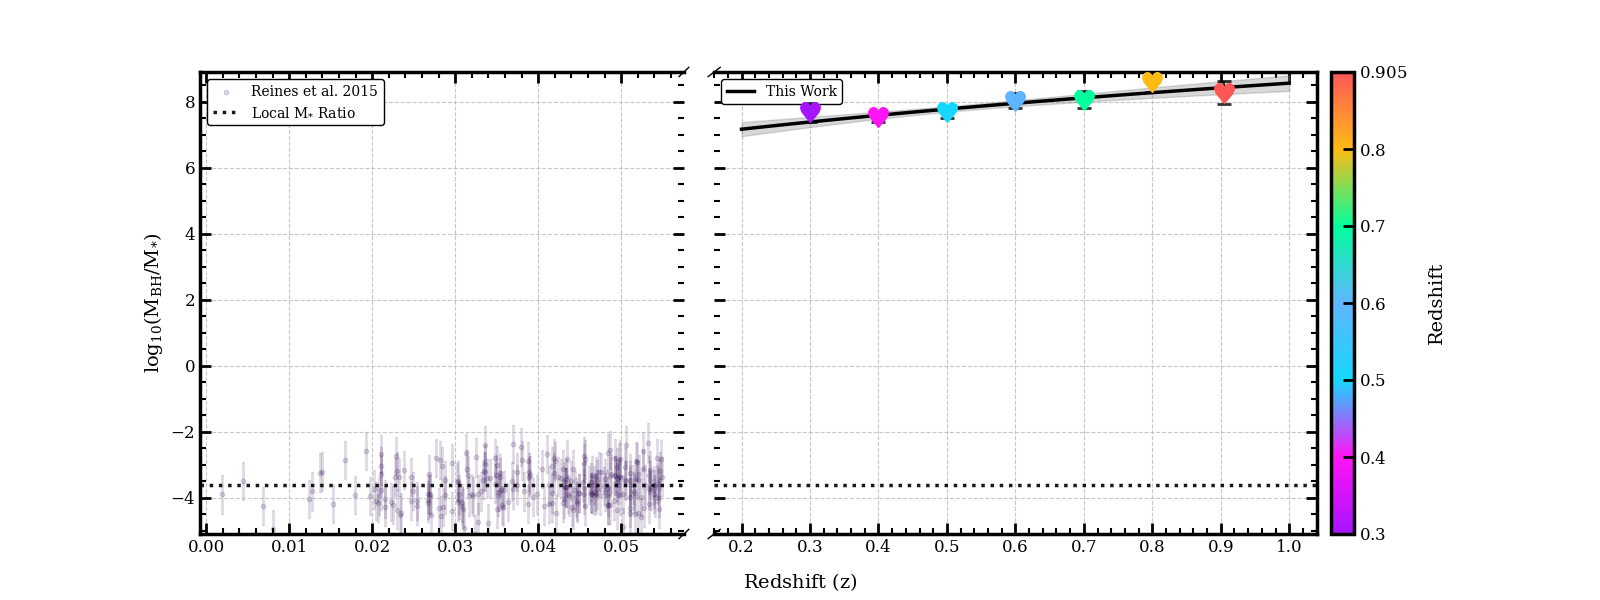

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Set MNRAS-compliant figure parameters
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth': 2.5,
    'axes.grid': True,
    'grid.alpha': 0.7,
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'xtick.major.size': 8,
    'xtick.minor.size': 4,
    'ytick.major.size': 8,
    'ytick.minor.size': 4,
    'xtick.major.width': 2.0,
    'xtick.minor.width': 1.5,
    'ytick.major.width': 2.0,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.edgecolor': 'black',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0
})

# Color scheme
colors = {
    '025_035': "#a714ff",
    '035_045': "#ff14f5",
    '045_055': "#14D8FF",
    '055_065': "#60B5FF",
    '065_075': "#00FF9C",
    '075_085': "#ffbb14",
    '085_096': "#FF5757"
}

# Dataset configuration
datasets = [
    ('025_035', 0.3,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_FeII_Removed_025_035,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_FeII_Removed_SD_025_035),
    ('035_045', 0.4,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_035_045,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_035_045),
    ('045_055', 0.5,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_045_055,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_045_055),
    ('055_065', 0.6,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_055_065,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_055_065),
    ('065_075', 0.7,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_065_075,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_065_075),
    ('075_085', 0.8,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_075_085,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_075_085),
    ('085_096', 0.905,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_085_096,
     BH_Stellar_Broad_AGN_Only_Malmquist_Bias_Corrected_Luminosity_Evolution_Kept_Normallized11_SD_085_096)
]

# Reines 2015 data
Reines_2013_Redshifts = np.array([0.0422, 0.0424, 0.0548, 0.0419, 0.0296, 0.0447, 0.0479, 0.0388, 0.0486, 0.0247, 
                                  0.052, 0.0333, 0.0502, 0.0455, 0.0547, 0.0267, 0.041, 0.0179, 0.0529, 0.0324, 
                                  0.0413, 0.0524, 0.0539, 0.0413, 0.0389, 0.0455, 0.0254, 0.0215, 0.0444, 0.0471, 
                                  0.0493, 0.0435, 0.0124, 0.0285, 0.0449, 0.0495, 0.0506, 0.047, 0.0495, 0.0464, 
                                  0.0447, 0.0455, 0.0309, 0.0499, 0.0268, 0.0493, 0.039, 0.0254, 0.0327, 0.0284, 
                                  0.0484, 0.0511, 0.0493, 0.0269, 0.051, 0.0211, 0.0475, 0.0137, 0.0469, 0.0499, 
                                  0.0468, 0.043, 0.0405, 0.0339, 0.0515, 0.051, 0.0348, 0.0228, 0.0518, 0.0502, 
                                  0.0524, 0.0535, 0.0497, 0.0488, 0.0351, 0.042, 0.0467, 0.0433, 0.0456, 0.0431, 
                                  0.0069, 0.0431, 0.051, 0.0354, 0.0519, 0.0357, 0.0271, 0.0543, 0.037, 0.0433, 
                                  0.0526, 0.0315, 0.0388, 0.0336, 0.0314, 0.0441, 0.0327, 0.0417, 0.0518, 0.0288, 
                                  0.0232, 0.0282, 0.0322, 0.021, 0.0235, 0.0331, 0.0267, 0.0515, 0.0491, 0.0267, 
                                  0.0432, 0.0517, 0.0127, 0.0348, 0.0381, 0.0484, 0.031, 0.021, 0.054, 0.0308, 
                                  0.0511, 0.052, 0.0193, 0.0233, 0.0215, 0.0205, 0.0223, 0.0249, 0.0522, 0.0481,
                                  0.0303, 0.0229, 0.0313, 0.0499, 0.0511, 0.0283, 0.0277, 0.0139, 0.0019, 0.0473, 
                                  0.0455, 0.0305, 0.0208, 0.0407, 0.0504, 0.0533, 0.023, 0.0465, 0.0541, 0.048, 
                                  0.0207, 0.0526, 0.0368, 0.0296, 0.0487, 0.0546, 0.0288, 0.0484, 0.032, 0.0496, 
                                  0.0528, 0.0442, 0.0476, 0.0202, 0.0044, 0.0238, 0.0546, 0.0247, 0.0225, 0.023, 
                                  0.0325, 0.008, 0.0338, 0.0535, 0.0349, 0.0536, 0.0167, 0.0545, 0.0498, 0.0471, 
                                  0.0433, 0.028, 0.037, 0.0495, 0.021, 0.0303, 0.0437, 0.0442, 0.044, 0.035, 
                                  0.0302, 0.0427, 0.0464, 0.054, 0.0454, 0.0375, 0.0308, 0.0398, 0.0449, 0.0394, 
                                  0.0354, 0.0359, 0.0336, 0.0419, 0.0197, 0.0504, 0.0353, 0.0484, 0.0375, 0.0456, 
                                  0.0486, 0.0355, 0.0153, 0.043, 0.0532, 0.0317, 0.0445, 0.0463, 0.0335, 0.0416, 
                                  0.0379, 0.0342, 0.0483, 0.0383, 0.0514, 0.0336, 0.0506, 0.0467, 0.0465, 0.0389, 
                                  0.0495, 0.0543, 0.0269, 0.0436, 0.0461, 0.0549, 0.0533, 0.0533, 0.0416, 0.035, 
                                  0.0356, 0.0544, 0.0304, 0.0363])

Reines_2013_Log_Mbh_Mstar_Ratio = np.array([-4.47, -3.36, -2.82, -2.81, -4.41, -4.11, -3.64, -2.88, -4.22, -4.1, -4.46, -3.45, -3.88, -3.71, -3.2, -4.06, -2.67, -3.92, -3.6, -5.1, -3.63, -3.97, -3.73, -4.18, -3.22, -2.95, -4.11, -4.03, -3.76, -3.45, -3.35, -2.83, -4.04, -4.28, -3.85, -4.38, -2.4, -3.9, -3.53, -3.53, -4.16, -2.74, -4.33, -3.38, -3.28, -2.81, -3.31, -4.24, -3.9, -3.03, -4.21, -3.26, -3.31, -3.95, -3.46, -3.04, -3.93, -3.24, -3.34, -3.93, -3.83, -4.16, -3.14, -4.76, -3.79, -4.31, -3.57, -3.37, -3.44, -4.88, -4.59, -3.16, -2.91, -3.27, -3.96, -2.89, -3.94, -3.42, -4.25, -4.03, -4.26, -3.5, -4.47, -3.38, -2.92, -4.27, -4.52, -3.58, -3.75, -3.69, -2.58, -3.32, -4.18, -2.41, -3.12, -4.27, -4.74, -3.87, -2.89, -3.47, -3.38, -2.86, -3.96, -2.67, -4.45, -3.81, -4.15, -3.87, -4.09, -3.88, -3.68, -4.5, -3.81, -2.8, -2.87, -3.96, -4.92, -3.78, -3.88, -4.25, -3.62, -3.46, -2.58, -4.53, -4.27, -4.09, -4.12, -3.79, -3.29, -3.83, -3.48, -2.73, -2.65, -3.37, -3.98, -4.54, -2.79, -3.21, -3.9, -3.21, -3.9, -3.9, -3.95, -4.26, -3.47, -3.75, -3.2, -3.32, -3.99, -3.42, -4.16, -3.12, -3.5, -2.94, -3.35, -4.01, -3.91, -4.23, -3.88, -3.6, -4.31, -3.12, -3.23, -3.75, -3.49, -3.16, -3.45, -3.37, -4.23, -4.36, -2.78, -4.96, -3.4, -3.46, -3.3, -3.78, -2.86, -4.35, -2.84, -3.75, -3.69, -4.3, -2.38, -3.41, -3.29, -4.12, -3.96, -4.37, -3.48, -3.01, -3.52, -3.4, -3.84, -3.61, -3.53, -3.6, -4.17, -3.9, -3.86, -3.98, -3.26, -3.77, -3.22, -3.24, -3.94, -3.06, -3.83, -2.66, -3.22, -2.84, -2.55, -3.77, -4.2, -3.14, -2.33, -3.96, -3.98, -3.89, -3.19, -3.04, -2.47, -3.4, -3.74, -3.81, -3.6, -2.97, -3.48, -3.62, -3.88, -3.36, -3.08, -2.8, -3.88, -3.88, -3.62, -3.36, -4.19, -3.32, -4.17, -4.35, -4.22, -3.64, -4.07, -4.12])

Reines_Log_Mbh_Mstar_Ratio_Error = np.full(len(Reines_2013_Log_Mbh_Mstar_Ratio), 0.58)

print(f"Reines data: {len(Reines_2013_Redshifts)} redshifts, {len(Reines_2013_Log_Mbh_Mstar_Ratio)} ratios")

# Extract data for fitting
x_data = np.array([dataset[1] for dataset in datasets])
y_data = np.array([dataset[2] for dataset in datasets])
y_errors = np.array([dataset[3] for dataset in datasets])

print("Our data (redshift):", x_data)
print("Our data (log M_BH/M_*):", y_data)

# Define power law function
def power_law_fit(z, a, b):
    return a + b * np.log10(1 + z)

# Perform fitting
try:
    initial_guess = [-2.5, 0.5]
    popt, pcov = curve_fit(
        power_law_fit, 
        x_data, 
        y_data, 
        sigma=y_errors, 
        absolute_sigma=True,
        p0=initial_guess,
        maxfev=5000
    )
    
    a_fit = popt[0]
    b_fit = popt[1]
    a_fit_err = np.sqrt(np.diag(pcov))[0]
    b_fit_err = np.sqrt(np.diag(pcov))[1]
    fit_successful = True
    
    print(f"\nFit successful!")
    print(f"log(M_BH/M_*) = {a_fit:.3f} ± {a_fit_err:.3f} + ({b_fit:.3f} ± {b_fit_err:.3f}) * log10(1+z)")
    
except Exception as e:
    fit_successful = False
    print(f"Fit failed: {e}")

# ===== CREATE BROKEN AXIS FIGURE =====
fig = plt.figure(figsize=(16, 6), facecolor='white')

# Create two subplots side by side with a small gap
# Left panel: Reines data (z ~ 0-0.06)
# Right panel: Our data (z ~ 0.25-1.0)
#ax1 = plt.subplot(1, 2, 1)  # Left panel
#ax2 = plt.subplot(1, 2, 2)  # Right panel

# Set x-axis limits for each panel
#ax1.set_xlim(-0.005, 0.06)
#ax2.set_xlim(0.2, 1.0)

gs = fig.add_gridspec(1, 2, width_ratios=[2, 3], wspace=0.05)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


# ===== PLOT REINES DATA (LEFT PANEL) =====
ax1.scatter(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
           color="#2A004E", s=40, marker='.', alpha=0.15, zorder=0,
           label='Reines et al. 2015')
ax1.errorbar(Reines_2013_Redshifts, Reines_2013_Log_Mbh_Mstar_Ratio,
            yerr=Reines_Log_Mbh_Mstar_Ratio_Error, linestyle='', ecolor="#2A004E",
            capsize=1, capthick=1, alpha=0.15, zorder=0)

# Local universe reference line
ax1.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000, label='Local M$_{*}$ Ratio')

# ===== PLOT OUR DATA (RIGHT PANEL) =====
# Plot best fit line if successful
if fit_successful:
    x_fit = np.linspace(0.2, 1.0, 100)
    y_fit = power_law_fit(x_fit, a_fit, b_fit)
    
    log_term = np.log10(1 + x_fit)
    y_fit_err = np.sqrt(a_fit_err**2 + (log_term**2) * (b_fit_err**2) + 
                        2 * log_term * pcov[0, 1])
    
    y_fit_upper = y_fit + y_fit_err
    y_fit_lower = y_fit - y_fit_err
    
    ax2.plot(x_fit, y_fit, color='black', linewidth=2.5, 
            label=f'This Work', zorder=30)
    ax2.fill_between(x_fit, y_fit_lower, y_fit_upper, 
                   color='gray', alpha=0.3, zorder=25)

# Plot our data points with heart markers
for i, (key, x_data_point, y_data_point, y_err) in enumerate(datasets):
    ax2.scatter(x_data_point, y_data_point,
              color=colors[key],
              s=200,
              marker=u"$\u2665$",
              alpha=1.0,
              zorder=10000)
    
    ax2.errorbar(x_data_point, y_data_point,
               yerr=y_err,
               linestyle='',
               ecolor='black',
               capsize=5,
               capthick=2,
               elinewidth=1.5,
               alpha=0.8,
               zorder=100)

# Local universe reference line on right panel too
ax2.axhline(y=np.log10(0.00025), linewidth=2.5, linestyle=':', color='black', 
           alpha=0.9, zorder=1000)

# ===== CONFIGURE AXES =====
# Y-axis label only on left panel
ax1.set_ylabel(r"log$_{10}$(M$_{\rm BH}$/M$_{*}$)", fontsize=14, color="black")
ax2.set_ylabel('')
ax2.tick_params(labelleft=False)

# X-axis labels
fig.text(0.5, 0.02, r"Redshift ($z$)", ha='center', fontsize=14, color="black")

# Shared y-axis limits
y_min = min(Reines_2013_Log_Mbh_Mstar_Ratio.min(), y_data.min() - 0.3)
y_max = max(Reines_2013_Log_Mbh_Mstar_Ratio.max(), y_data.max() + 0.3)
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

# Configure grid for both panels
for ax in [ax1, ax2]:
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='--', alpha=0.7, zorder=-10)
    ax.minorticks_on()
    
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
    
    ax.tick_params(axis='both', which='major', labelsize=12,
                   length=8, width=2.0, direction='in')
    ax.tick_params(axis='both', which='minor', labelsize=10,
                   length=4, width=1.5, direction='in')
    ax.tick_params(top=True, right=True)

# Hide the spines between ax1 and ax2
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Add diagonal break markers
d = 0.01  # size of diagonal lines
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False, linewidth=1.0)  # Changed from 1.5
ax1.plot((1-d, 1+d), (-d, +d), **kwargs)
ax1.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1-d, 1+d), **kwargs)

# Add legends
ax1.legend(loc='upper left', fontsize=10, frameon=True, fancybox=True,
          edgecolor='black', facecolor='white', framealpha=1.0)
ax2.legend(loc='upper left', fontsize=10, frameon=True, fancybox=True,
          edgecolor='black', facecolor='white', framealpha=1.0)

# Add colorbar for right panel
from matplotlib.colors import LinearSegmentedColormap
color_list = list(colors.values())
custom_cmap = LinearSegmentedColormap.from_list("custom", color_list, N=256)

labels_2 = [r'$0.3$', r'$0.4$', r'$0.5$', r'$0.6$', r'$0.7$', r'$0.8$', r'$0.905$']

sm = cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=0, vmax=len(labels_2)-1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, pad=0.02, shrink=1.0)
cbar.set_ticks(np.arange(len(labels_2)))
cbar.set_ticklabels(labels_2)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Redshift', fontsize=14, labelpad=15)

# Adjust layout
#plt.subplots_adjust(wspace=0.03, bottom=0.12)

# Save figure
fig.savefig("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/AGN-Black-Hole-Research-Full-Catalog/Plots_For_Paper_Full_Catalog/BH_Stellar_With_Reines_Z.png", dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()



In [ ]:
aaaaaaa

In [ ]:
pdf_filename = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/Figures_For_Stella_Mass.pdf"
with PdfPages(pdf_filename) as pdf:
    figures = [plt.figure(n) for n in plt.get_fignums()]
    print(plt.get_fignums())
    for fig in figures:
        pdf.savefig(fig)
    plt.close('all')
print(f"All figures saved to {pdf_filename}")

In [ ]:
L_3000_Median_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Sigma_025_035
L_3000_Median_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Narrow_Sigma_SD_025_035
L_3000_Median_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
L_3000_Median_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_025_035_Median
L_3000_Median_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_025_035_Median_SD
L_3000_Median_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_Median
L_3000_Median_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_035_045_Median_SD
L_3000_Median_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_Median
L_3000_Median_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_045_055_Median_SD
L_3000_Median_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_Median
L_3000_Median_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_055_065_Median_SD
L_3000_Median_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_Median
L_3000_Median_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_065_075_Median_SD
L_3000_Median_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_Median
L_3000_Median_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_075_085_Median_SD
L_3000_Median_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_Median
L_3000_Median_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_085_096_Median_SD
L_3000_Median_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
Stellar_Mass_Median_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
Stellar_Mass_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
Stellar_Mass_Median_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
Stellar_Mass_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
Stellar_Mass_Median_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
Stellar_Mass_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
Stellar_Mass_Median_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
Stellar_Mass_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
Stellar_Mass_Median_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
Stellar_Mass_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
Stellar_Mass_Median_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
Stellar_Mass_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
Stellar_Mass_Median_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
Stellar_Mass_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
Delta_BH_Stellar_Broad_FeII_Removed_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
Delta_BH_Stellar_Broad_FeII_Removed_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_SD_025_035
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_FeII_Removed_Broad_Sigma_025_035
Delta_BH_Stellar_Broad_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
Delta_BH_Stellar_Broad_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_035_045
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_035_045
Delta_BH_Stellar_Broad_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
Delta_BH_Stellar_Broad_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_045_055
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_045_055
Delta_BH_Stellar_Broad_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
Delta_BH_Stellar_Broad_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_055_065
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_055_065
Delta_BH_Stellar_Broad_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
Delta_BH_Stellar_Broad_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_065_075
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_065_075
Delta_BH_Stellar_Broad_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
Delta_BH_Stellar_Broad_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_075_085
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_075_085
Delta_BH_Stellar_Broad_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
Delta_BH_Stellar_Broad_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_SD_085_096
MgII_ReStacked_Continuum_Scaled_Two_Gaussian_Velocity_Uniform_Narrow_Sigma_Broad_Sigma_085_096
Stellar_Mass_Median_025_035
Stellar_Mass_SD_025_035
Stellar_Mass_Median_035_045
Stellar_Mass_SD_035_045
Stellar_Mass_Median_045_055
Stellar_Mass_SD_045_055
Stellar_Mass_Median_055_065
Stellar_Mass_SD_055_065
Stellar_Mass_Median_065_075
Stellar_Mass_SD_065_075
Stellar_Mass_Median_075_085
Stellar_Mass_SD_075_085
Stellar_Mass_Median_085_096
Stellar_Mass_SD_085_096
Stellar_Mass_Median_025_035
Delta_BH_Stellar_Broad_FeII_Removed_025_035
Stellar_Mass_SD_025_035
Delta_BH_Stellar_Broad_FeII_Removed_SD_025_035
Stellar_Mass_Median_035_045
Delta_BH_Stellar_Broad_035_045
Stellar_Mass_SD_035_045
Delta_BH_Stellar_Broad_SD_035_045
Stellar_Mass_Median_045_055
Delta_BH_Stellar_Broad_045_055
Stellar_Mass_SD_045_055
Delta_BH_Stellar_Broad_SD_045_055
Stellar_Mass_Median_055_065
Delta_BH_Stellar_Broad_055_065
Stellar_Mass_SD_055_065
Delta_BH_Stellar_Broad_SD_055_065
Stellar_Mass_Median_065_075
Delta_BH_Stellar_Broad_065_075
Stellar_Mass_SD_065_075
Delta_BH_Stellar_Broad_SD_065_075
Stellar_Mass_Median_075_085
Delta_BH_Stellar_Broad_075_085
Stellar_Mass_SD_075_085
Delta_BH_Stellar_Broad_SD_075_085
Stellar_Mass_Median_085_096
Delta_BH_Stellar_Broad_085_096
Stellar_Mass_SD_085_096
Delta_BH_Stellar_Broad_SD_085_096
Stellar_Mass_Median_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
Stellar_Mass_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
Stellar_Mass_Median_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
Stellar_Mass_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
Stellar_Mass_Median_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
Stellar_Mass_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
Stellar_Mass_Median_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
Stellar_Mass_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
Stellar_Mass_Median_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
Stellar_Mass_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
Stellar_Mass_Median_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
Stellar_Mass_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
Stellar_Mass_Median_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
Stellar_Mass_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
Delta_BH_Stellar_Broad_FeII_Removed_025_035
Delta_BH_Stellar_Broad_FeII_Removed_SD_025_035
Delta_BH_Stellar_Broad_035_045
Delta_BH_Stellar_Broad_SD_035_045
Delta_BH_Stellar_Broad_045_055
Delta_BH_Stellar_Broad_SD_045_055
Delta_BH_Stellar_Broad_055_065
Delta_BH_Stellar_Broad_SD_055_065
Delta_BH_Stellar_Broad_065_075
Delta_BH_Stellar_Broad_SD_065_075
Delta_BH_Stellar_Broad_075_085
Delta_BH_Stellar_Broad_SD_075_085
Delta_BH_Stellar_Broad_085_096
Delta_BH_Stellar_Broad_SD_085_096
Stellar_Mass_Median_025_035
Delta_BH_Stellar_Broad_FeII_Removed_025_035_Relation
Stellar_Mass_SD_025_035
Delta_BH_Stellar_Broad_FeII_Removed_SD_025_035_Relation
Stellar_Mass_Median_035_045
Delta_BH_Stellar_Broad_035_045_Relation
Stellar_Mass_SD_035_045
Delta_BH_Stellar_Broad_SD_035_045_Relation
Stellar_Mass_Median_045_055
Delta_BH_Stellar_Broad_045_055_Relation
Stellar_Mass_SD_045_055
Delta_BH_Stellar_Broad_SD_045_055_Relation
Stellar_Mass_Median_055_065
Delta_BH_Stellar_Broad_055_065_Relation
Stellar_Mass_SD_055_065
Delta_BH_Stellar_Broad_SD_055_065_Relation
Stellar_Mass_Median_065_075
Delta_BH_Stellar_Broad_065_075_Relation
Stellar_Mass_SD_065_075
Delta_BH_Stellar_Broad_SD_065_075_Relation
Stellar_Mass_Median_075_085
Delta_BH_Stellar_Broad_075_085_Relation
Stellar_Mass_SD_075_085
Delta_BH_Stellar_Broad_SD_075_085_Relation
Stellar_Mass_Median_085_096
Delta_BH_Stellar_Broad_085_096_Relation
Stellar_Mass_SD_085_096
Delta_BH_Stellar_Broad_SD_085_096_Relation
Stellar_Mass_Median_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
Stellar_Mass_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_SD_025_035
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_FeII_Removed_Luminosity_Corrected_Median_025_035
Stellar_Mass_Median_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
Stellar_Mass_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_035_045
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_035_045
Stellar_Mass_Median_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
Stellar_Mass_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_045_055
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_045_055
Stellar_Mass_Median_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
Stellar_Mass_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_055_065
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_055_065
Stellar_Mass_Median_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
Stellar_Mass_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_065_075
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_065_075
Stellar_Mass_Median_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
Stellar_Mass_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_075_085
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_075_085
Stellar_Mass_Median_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096
Stellar_Mass_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_SD_085_096
BH_Mass_Broad_MgII_Uniform_Narrow_Sigma_Luminosity_Corrected_Median_085_096



AGN_Only_Continuum_L3000_025_035
AGN_Only_Continuum_L_3000_SD_025_035
AGN_Only_Continuum_L3000_035_045
AGN_Only_Continuum_L_3000_SD_035_045
AGN_Only_Continuum_L3000_045_055
AGN_Only_Continuum_L_3000_SD_045_055
AGN_Only_Continuum_L3000_055_065
AGN_Only_Continuum_L_3000_SD_055_065
AGN_Only_Continuum_L3000_065_075
AGN_Only_Continuum_L_3000_SD_065_075
AGN_Only_Continuum_L3000_075_085
AGN_Only_Continuum_L_3000_SD_075_085
AGN_Only_Continuum_L3000_085_096
AGN_Only_Continuum_L_3000_SD_085_096
AGN_Only_Continuums_L3000_025_035
AGN_Only_Continuums_L3000_SD_025_035
AGN_Only_Continuums_L3000_035_045
AGN_Only_Continuums_L3000_SD_035_045
AGN_Only_Continuums_L3000_045_055
AGN_Only_Continuums_L3000_SD_045_055
AGN_Only_Continuums_L3000_055_065
AGN_Only_Continuums_L3000_SD_055_065
AGN_Only_Continuums_L3000_065_075
AGN_Only_Continuums_L3000_SD_065_075
AGN_Only_Continuums_L3000_075_085
AGN_Only_Continuums_L3000_SD_075_085
AGN_Only_Continuums_L3000_085_096
AGN_Only_Continuums_L3000_SD_085_096